# 라이브러리

In [1]:
import koreanize_matplotlib

In [2]:
# 라이브러리
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

font_path = "C:/Windows/Fonts/malgun.ttf"
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

sns.set_theme(
    style="whitegrid",
    font=font_name,
    rc={
        "font.family": font_name,
        "font.sans-serif": [font_name],
        "axes.unicode_minus": False
    }
)

plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", None)
print("현재 matplotlib font.family:", plt.rcParams["font.family"])
print("현재 matplotlib font.sans-serif:", plt.rcParams["font.sans-serif"][:3])

현재 matplotlib font.family: ['Malgun Gothic']
현재 matplotlib font.sans-serif: ['Malgun Gothic']


In [3]:
# 데이터 경로
BASE_DIR = Path("D:/farm-system-public-02")

DAY_PATH = BASE_DIR / "data/날씨데이터/날씨데이터_일자별_전국산불.csv"
HOUR_PATH = BASE_DIR / "data/날씨데이터/날씨데이터_시간별_전국산불.csv"

# 데이터 로드

In [4]:
# 데이터 로드
day_df = pd.read_csv(DAY_PATH, encoding="utf-8-sig")
hour_df = pd.read_csv(HOUR_PATH, encoding="utf-8-sig")

# EDA

## 1. 분석 대상 구분

### 1.1 강원도 / 타 지역 구분 변수 생성

In [5]:
SIDO_COL = "발생지역시도명"
ID_COL = "산불아이디"
DATE_COL = "발생일자"
HOUR_COL = "발생시간"

GANGWON_NAMES = ["강원특별자치도", "강원도"]

for df in [day_df, hour_df]:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df["발생연도"] = df[DATE_COL].dt.year
    df["발생월"] = df[DATE_COL].dt.month
    
    df["is_gangwon"] = df[SIDO_COL].isin(GANGWON_NAMES)
    df["region_group"] = df["is_gangwon"].map({
        True: "강원특별자치도",
        False: "타 지역"
    })

In [6]:
# 강원도 / 타 지역 산불 건수 확인

region_counts = (
    day_df
    .drop_duplicates(ID_COL)
    .groupby("region_group")[ID_COL]
    .count()
    .reset_index(name="산불건수")
)

region_counts

,region_group,산불건수
0,강원특별자치도,4139
1,타 지역,20897


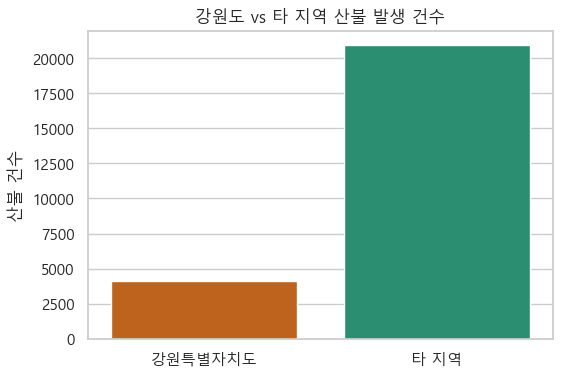

In [7]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=region_counts,
    x="region_group",
    y="산불건수",
    hue="region_group",
    palette=["#d95f02", "#1b9e77"],
    legend=False
)

plt.title("강원도 vs 타 지역 산불 발생 건수")
plt.xlabel("")
plt.ylabel("산불 건수")
plt.show()

### 1.2 시도별 산불 건수

In [8]:
# 시도별 산불 건수

sido_counts = (
    day_df
    .drop_duplicates(ID_COL)
    .groupby(SIDO_COL)[ID_COL]
    .count()
    .sort_values(ascending=False)
    .reset_index(name="산불건수")
)

sido_counts

,발생지역시도명,산불건수
0,경상북도,4408
1,강원특별자치도,4139
2,경기도,3701
3,경상남도,3015
4,충청남도,2112
5,전라남도,2015
6,충청북도,1387
7,전북특별자치도,985
8,부산광역시,691
9,인천광역시,573


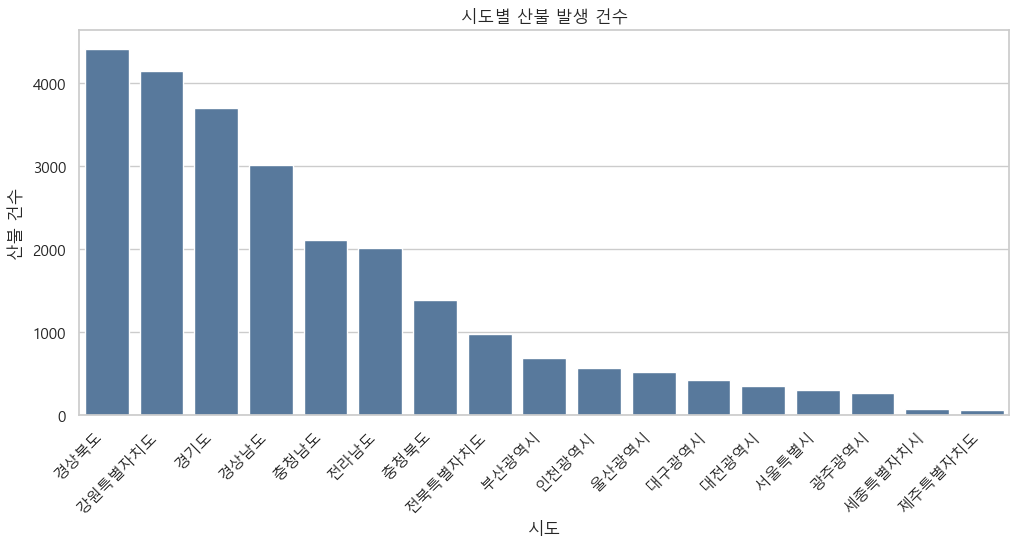

In [9]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=sido_counts,
    x=SIDO_COL,
    y="산불건수",
    color="#4c78a8"
)

plt.title("시도별 산불 발생 건수")
plt.xlabel("시도")
plt.ylabel("산불 건수")
plt.xticks(rotation=45, ha="right")
plt.show()

### 1.3 연도별 산불 건수 비교

In [10]:
# 연도별 산불 건수 비교

year_counts = (
    day_df
    .drop_duplicates(ID_COL)
    .groupby(["region_group", "발생연도"])[ID_COL]
    .count()
    .reset_index(name="산불건수")
)

year_counts.head()

,region_group,발생연도,산불건수
0,강원특별자치도,2000,162
1,강원특별자치도,2001,86
2,강원특별자치도,2002,50
3,강원특별자치도,2003,11
4,강원특별자치도,2004,57


In [11]:
year_counts

,region_group,발생연도,산불건수
0,강원특별자치도,2000,162
1,강원특별자치도,2001,86
2,강원특별자치도,2002,50
3,강원특별자치도,2003,11
4,강원특별자치도,2004,57
5,강원특별자치도,2005,41
6,강원특별자치도,2006,30
7,강원특별자치도,2007,26
8,강원특별자치도,2008,25
9,강원특별자치도,2009,60


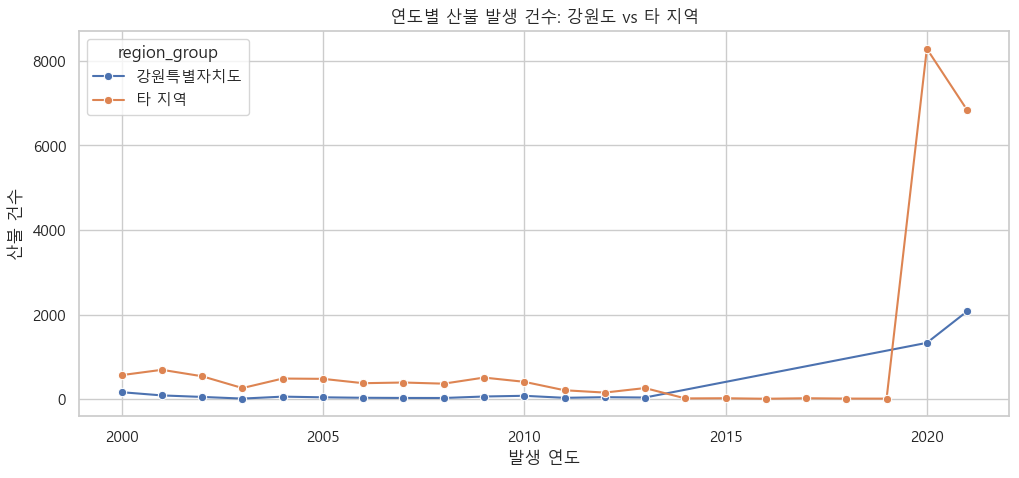

In [12]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=year_counts,
    x="발생연도",
    y="산불건수",
    hue="region_group",
    marker="o"
)

plt.title("연도별 산불 발생 건수: 강원도 vs 타 지역")
plt.xlabel("발생 연도")
plt.ylabel("산불 건수")
plt.show()

### 1.4 월별 산불 건수 비교

In [13]:
# 월별 산불 건수 비교

month_counts = (
    day_df
    .drop_duplicates(ID_COL)
    .groupby(["region_group", "발생월"])[ID_COL]
    .count()
    .reset_index(name="산불건수")
)

month_counts.head()

,region_group,발생월,산불건수
0,강원특별자치도,1,242
1,강원특별자치도,2,1565
2,강원특별자치도,3,355
3,강원특별자치도,4,553
4,강원특별자치도,5,242


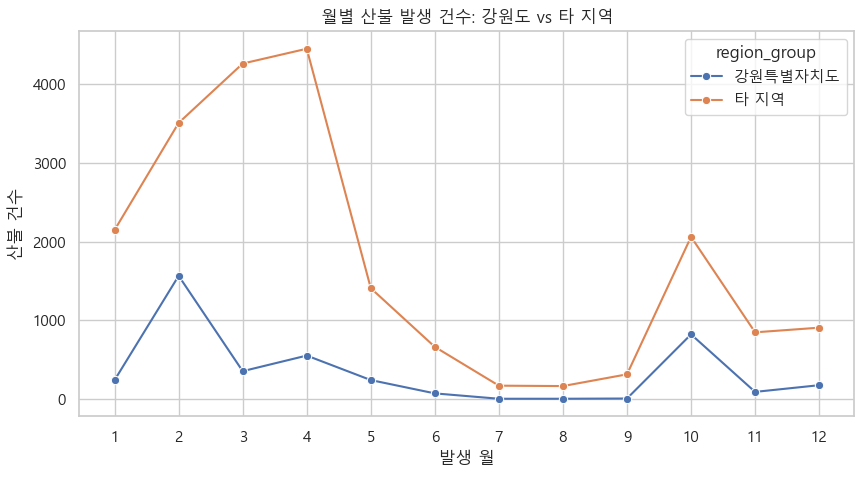

In [14]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=month_counts,
    x="발생월",
    y="산불건수",
    hue="region_group",
    marker="o"
)

plt.title("월별 산불 발생 건수: 강원도 vs 타 지역")
plt.xlabel("발생 월")
plt.ylabel("산불 건수")
plt.xticks(range(1, 13))
plt.show()

### 1.5 발생 시간대별 산불 건수 비교

In [15]:
# 발생 시간대별 산불 건수 비교

hour_counts = (
    hour_df
    .drop_duplicates(ID_COL)
    .groupby(["region_group", HOUR_COL])[ID_COL]
    .count()
    .reset_index(name="산불건수")
)

hour_counts.head()

,region_group,발생시간,산불건수
0,강원특별자치도,0,8
1,강원특별자치도,1,12
2,강원특별자치도,2,15
3,강원특별자치도,3,18
4,강원특별자치도,4,17


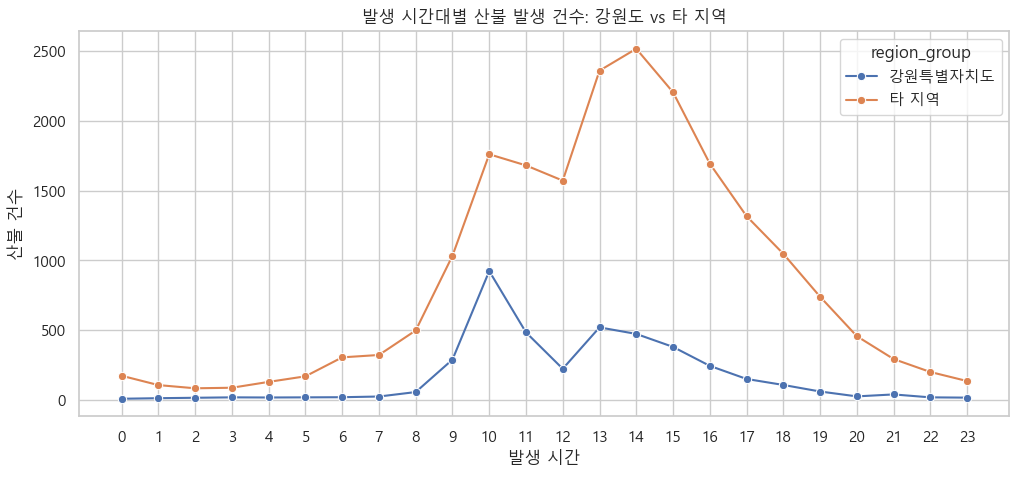

In [16]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hour_counts,
    x=HOUR_COL,
    y="산불건수",
    hue="region_group",
    marker="o"
)

plt.title("발생 시간대별 산불 발생 건수: 강원도 vs 타 지역")
plt.xlabel("발생 시간")
plt.ylabel("산불 건수")
plt.xticks(range(0, 24))
plt.show()

### 1.6 강원도 표본 수 확인

In [17]:
# 강원도 표본 수 확인

gangwon_summary = pd.DataFrame({
    "구분": ["강원도", "타 지역", "전체"],
    "산불건수": [
        day_df.loc[day_df["is_gangwon"], ID_COL].nunique(),
        day_df.loc[~day_df["is_gangwon"], ID_COL].nunique(),
        day_df[ID_COL].nunique()
    ]
})

total_count = gangwon_summary.loc[gangwon_summary["구분"] == "전체", "산불건수"].iloc[0]
gangwon_summary["비율"] = gangwon_summary["산불건수"] / total_count

gangwon_summary

,구분,산불건수,비율
0,강원도,4139,0.165322
1,타 지역,20897,0.834678
2,전체,25036,1.000000


In [18]:
# 연도별 및 지역별 산불 건수 상세 테이블 작성 (데이터 편향 확인)
yearly_trend = (
    day_df
    .drop_duplicates(ID_COL)
    .groupby(["발생연도", "region_group"])[ID_COL]
    .count()
    .unstack(fill_value=0)
)
yearly_trend["전체"] = yearly_trend["강원특별자치도"] + yearly_trend["타 지역"]
yearly_trend["강원비율(%)"] = (yearly_trend["강원특별자치도"] / yearly_trend["전체"] * 100).round(2)
yearly_trend

region_group,강원특별자치도,타 지역,전체,강원비율(%)
발생연도,,,,
2000,162,566,728,22.25
2001,86,692,778,11.05
2002,50,539,589,8.49
2003,11,260,271,4.06
2004,57,485,542,10.52
2005,41,478,519,7.90
2006,30,375,405,7.41
2007,26,391,417,6.24
2008,25,364,389,6.43


### 1.7. 분석 대상 구분 결과 요약 및 데이터 불균형 분석

1. **지역별 산불 분포**: 보정된 날씨 매칭 데이터의 발생일 기준 고유 산불은 총 **25,036건**입니다. 이 중 강원특별자치도는 **4,139건(16.53%)**, 타 지역은 **20,897건(83.47%)**입니다. 강원도 표본은 전체보다 작지만 기상 조건 차이를 비교하기에는 충분한 규모이며, 이후 분석은 변수별 결측을 제외한 유효 표본 기준으로 해석합니다.

2. **시도별 분포**: 시도별 산불 건수는 경상북도 **4,408건**, 강원특별자치도 **4,139건**, 경기도 **3,701건**, 경상남도 **3,015건** 순입니다. 강원도는 전국에서 두 번째로 큰 표본을 가지므로, 별도 지역군으로 비교할 실익이 큽니다.

3. **연도별 수집 편향**: 2020~2021년에 표본이 크게 집중되어 있습니다. 강원도는 2020년 **1,330건**, 2021년 **2,075건**이고, 타 지역은 2020년 **8,289건**, 2021년 **6,840건**입니다. 따라서 연도 효과가 큰 모델에서는 연도 또는 자료 수집 구간 보정이 필요합니다.

4. **월별/시간대별 차이**: 강원도는 **2월 1,565건**으로 조기 피크가 가장 뚜렷하고, 10월에도 2차 피크가 나타납니다. 타 지역은 3~4월 피크가 더 강합니다. 발생시간은 강원도에서 10시 전후 피크가 두드러지고, 타 지역은 13~15시대에 더 큰 주간 피크가 형성됩니다.

5. **해석 주의**: 이 노트북은 산불 발생 사건만 모은 조건부 표본을 비교합니다. 따라서 “강원도의 날씨가 산불을 더 많이 발생시킨다”는 인과 결론이 아니라, **발생한 산불 사건 내부에서 강원도와 타 지역의 기상 조건이 어떻게 다른지**를 보여주는 EDA입니다.


## 2. 일자별 날씨 변수 비교

### 2.1. 사전 데이터 구조 파악 (컬럼명, 고유값, 데이터 형태)

In [19]:
# 분석에 사용할 주요 날씨 변수 리스트
weather_cols = [
    "평균 기온", "최저 기온", "최고 기온", 
    "평균 상대습도", "최소 상대습도", 
    "일강수량", "평균 풍속", "최대 풍속"
]

print("=== day_df 기본 정보 ===")
print("Shape:", day_df.shape)
print("\n=== 컬럼 목록 ===")
print(day_df.columns.tolist())

print("\n=== 발생지역시도명 고유값 (Unique 지역명) ===")
print(day_df["발생지역시도명"].unique())

print("\n=== 날짜구분 고유값 ===")
print(day_df["날짜구분"].unique())

# 날짜구분이 '발생일'인 데이터만 추출
day_active = day_df[day_df["날짜구분"] == "발생일"].copy()
print("\n=== 발생일 기준 필터링 후 shape ===")
print(day_active.shape)

=== day_df 기본 정보 ===
Shape: (75127, 52)

=== 컬럼 목록 ===
['산불아이디', '발생일자', '날씨일자', '발생일기준일수', '날짜구분', '날씨연도', '날씨월', '날씨일', '발생시간', '진화소요시간시', '산불위도', '산불경도', '발생지역시도명', '발생지역시군구명', '발생지역읍면동명', '평균 기온', '최저 기온', '최고 기온', '일강수량', '최대 순간풍속', '평균 풍속', '최대 순간 풍속 풍향', '최대 풍속', '최대 풍속 풍향', '최대 풍향', '풍정합', '최소 상대습도', '평균 상대습도', '평균 이슬점온도', '평균 증기압', '평균 현지기압', '평균 해면기압', '가조시간', '합계 일조 시간', '합계 일사', '평균 전운량', '평균 중하층운량', '평균 지면온도', '최저 초상온도', '평균 5cm 지중온도', '평균10cm 지중온도', '평균 20cm 지중온도', '평균 30cm 지중온도', '합계 소형증발량', '합계 대형증발량', '일 최심신적설', '일 최심적설', '합계 3시간 신적설', '발생연도', '발생월', 'is_gangwon', 'region_group']

=== 발생지역시도명 고유값 (Unique 지역명) ===
<ArrowStringArray>
[  '서울특별시',     '경기도',   '부산광역시',    '경상남도',   '대구광역시',    '경상북도',   '인천광역시',
   '광주광역시',    '전라남도',   '대전광역시',   '울산광역시', '세종특별자치시',    '충청남도',    '충청북도',
 '강원특별자치도', '전북특별자치도', '제주특별자치도']
Length: 17, dtype: str

=== 날짜구분 고유값 ===
<ArrowStringArray>
['과거1일', '발생일', '미래1일', '미래2일', '미래3일', '미래4일']
Length: 6, dtype: str

=== 발생일 기준 필터링 후 shape

### 2.2. 날씨 변수별 결측 행 및 유효 표본 수 확인

In [20]:
# 강원도와 타 지역의 변수별 유효 표본 수 및 결측치 확인
sample_info = []
for col in weather_cols:
    valid = day_active.groupby("region_group")[col].count()
    nulls = day_active.groupby("region_group")[col].apply(lambda x: x.isnull().sum())
    for region in ["강원특별자치도", "타 지역"]:
        sample_info.append({
            "변수명": col,
            "지역구분": region,
            "유효 표본 수": valid.get(region, 0),
            "결측 표본 수": nulls.get(region, 0)
        })

sample_info_df = pd.DataFrame(sample_info)
sample_info_df

,변수명,지역구분,유효 표본 수,결측 표본 수
0,평균 기온,강원특별자치도,4139,0
1,평균 기온,타 지역,20897,0
2,최저 기온,강원특별자치도,4139,0
3,최저 기온,타 지역,20897,0
4,최고 기온,강원특별자치도,4139,0
5,최고 기온,타 지역,20897,0
6,평균 상대습도,강원특별자치도,4139,0
7,평균 상대습도,타 지역,20897,0
8,최소 상대습도,강원특별자치도,4139,0
9,최소 상대습도,타 지역,20897,0


### 2.3. 전체 기간 발생일 기준 주요 날씨 변수 분포 비교 (기술통계량)

In [21]:
# 전체 기간에 대해 기상 변수 통계치 비교
stats_list = []
for col in weather_cols:
    desc = day_active.groupby("region_group")[col].describe(percentiles=[0.25, 0.5, 0.75])
    desc['변수명'] = col
    stats_list.append(desc)

stats_df = pd.concat(stats_list).reset_index()
stats_df = stats_df[['변수명', 'region_group', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats_df.rename(columns={
    "region_group": "지역구분", 
    "count": "표본수", 
    "mean": "평균", 
    "std": "표준편차", 
    "min": "최소값", 
    "50%": "중앙값", 
    "max": "최대값"
}, inplace=True)
stats_df

,변수명,지역구분,표본수,평균,표준편차,최소값,25%,중앙값,75%,최대값
0,평균 기온,강원특별자치도,4139.0,5.602809,7.256600,-16.846897,-0.859168,7.139631,9.794142,29.432334
1,평균 기온,타 지역,20897.0,9.075381,6.856320,-17.743888,4.393942,9.049322,13.281329,31.353342
2,최저 기온,강원특별자치도,4139.0,-0.552171,6.942206,-22.432991,-6.115706,-0.172849,3.701847,24.756717
3,최저 기온,타 지역,20897.0,2.601561,6.997690,-22.765797,-2.047283,2.054634,6.503603,27.461235
4,최고 기온,강원특별자치도,4139.0,12.288296,8.232863,-10.343713,5.248921,13.370105,18.466621,35.294706
5,최고 기온,타 지역,20897.0,16.092141,7.423688,-12.614145,10.892926,16.614291,21.282597,36.960821
6,평균 상대습도,강원특별자치도,4139.0,55.210964,16.975359,16.721909,41.713571,53.461464,68.580838,99.972397
7,평균 상대습도,타 지역,20897.0,59.102515,15.453466,16.889888,47.563783,57.773163,69.842875,99.985213
8,최소 상대습도,강원특별자치도,4139.0,29.691481,14.494396,5.081162,19.003835,26.323748,39.991683,99.849440
9,최소 상대습도,타 지역,20897.0,32.028858,16.717742,2.589151,19.710097,27.481585,40.641390,99.419115


### 2.4. 건조기/산불조심기간 (11월 ~ 5월) 필터링 후 비교

In [22]:
# 11월 ~ 5월 기간 필터링
day_dry_season = day_active[day_active["발생월"].isin([11, 12, 1, 2, 3, 4, 5])].copy()

# 건조기 기간 기상 변수 통계치 비교
stats_dry_list = []
for col in weather_cols:
    desc = day_dry_season.groupby("region_group")[col].describe(percentiles=[0.25, 0.5, 0.75])
    desc['변수명'] = col
    stats_dry_list.append(desc)

stats_dry_df = pd.concat(stats_dry_list).reset_index()
stats_dry_df = stats_dry_df[['변수명', 'region_group', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
stats_dry_df.rename(columns={
    "region_group": "지역구분", 
    "count": "표본수", 
    "mean": "평균", 
    "std": "표준편차", 
    "min": "최소값", 
    "50%": "중앙값", 
    "max": "최대값"
}, inplace=True)
stats_dry_df

,변수명,지역구분,표본수,평균,표준편차,최소값,25%,중앙값,75%,최대값
0,평균 기온,강원특별자치도,3226.0,4.119243,7.210857,-16.846897,-1.414540,4.298913,8.804415,27.139054
1,평균 기온,타 지역,17522.0,7.670061,6.146776,-17.743888,3.878845,7.677087,11.900006,26.174653
2,최저 기온,강원특별자치도,3226.0,-2.051524,6.628313,-22.432991,-7.029741,-1.800307,2.317442,22.524385
3,최저 기온,타 지역,17522.0,1.001103,5.882678,-22.765797,-2.795041,0.958262,4.570646,20.873678
4,최고 기온,강원특별자치도,3226.0,10.480991,8.171740,-10.343713,3.582240,10.547732,16.534251,33.837116
5,최고 기온,타 지역,17522.0,14.738118,7.018422,-12.614145,9.908857,15.193364,19.804732,36.940957
6,평균 상대습도,강원특별자치도,3226.0,49.911639,14.610956,16.721909,37.591942,50.662935,59.020710,96.551042
7,평균 상대습도,타 지역,17522.0,56.873841,14.949849,16.889888,46.058375,55.662098,65.780932,99.883823
8,최소 상대습도,강원특별자치도,3226.0,25.968245,12.558462,5.081162,16.231868,22.816448,31.607037,89.637961
9,최소 상대습도,타 지역,17522.0,30.138210,15.998327,2.589151,18.674733,25.753319,37.000017,99.419115


### 2.5. 주요 날씨 변수 분포 시각화 (전체 기간 vs 11월 ~ 5월 기간)
기온, 습도, 풍속 등 핵심 변수들의 분포적 차이를 Boxplot으로 비교합니다.

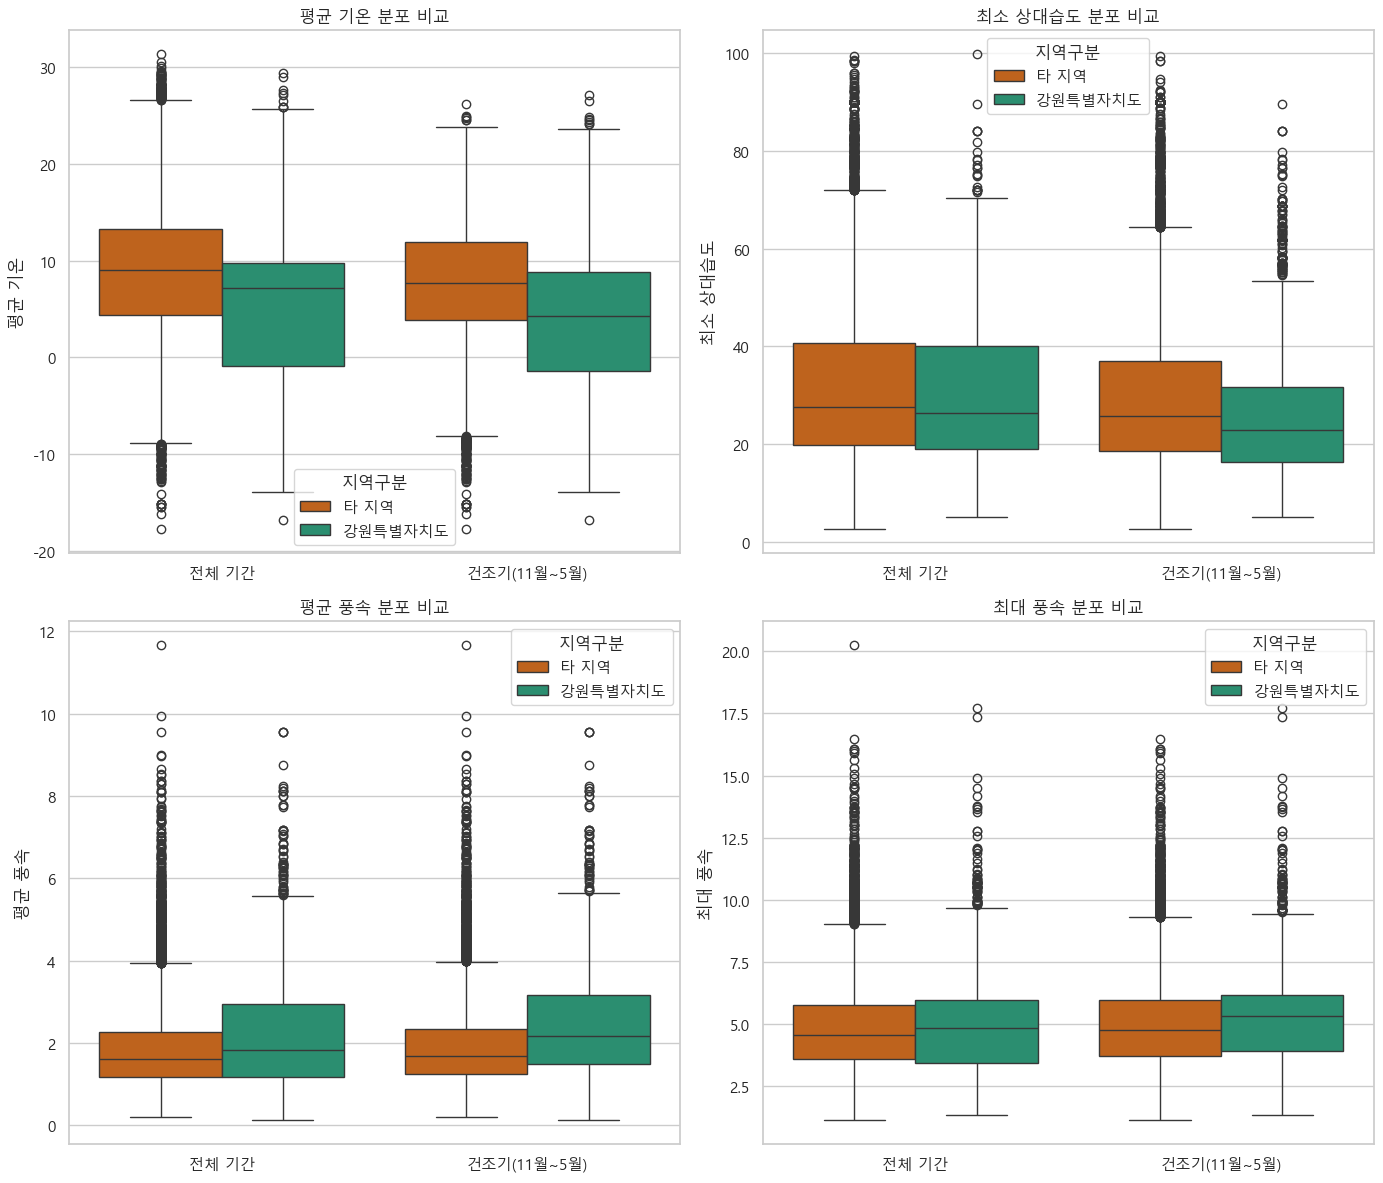

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 시각화할 주요 4가지 변수
plot_vars = ["평균 기온", "최소 상대습도", "평균 풍속", "최대 풍속"]

# 분석 대상 데이터에 기간 태그 추가하여 결합
day_active_tagged = day_active.copy()
day_active_tagged["기간구분"] = "전체 기간"

day_dry_tagged = day_dry_season.copy()
day_dry_tagged["기간구분"] = "건조기(11월~5월)"

combined_plot_df = pd.concat([day_active_tagged, day_dry_tagged], ignore_index=True)

for i, var in enumerate(plot_vars):
    ax = axes[i//2, i%2]
    sns.boxplot(
        data=combined_plot_df,
        x="기간구분",
        y=var,
        hue="region_group",
        palette=["#d95f02", "#1b9e77"],
        ax=ax
    )
    ax.set_title(f"{var} 분포 비교")
    ax.set_xlabel("")
    ax.set_ylabel(var)
    ax.legend(title="지역구분")

plt.tight_layout()
plt.show()

### 2.6. 일자별 날씨 변수 비교 분석 요약

1. **표본 및 결측치**: 발생일 당일 기준으로 강원특별자치도 **4,139건**, 타 지역 **20,897건**이 분석에 사용되었습니다. 주요 일자별 변수 8종은 이 필터 기준에서 결측이 없어 동일 표본으로 비교 가능합니다.

2. **기온 격차**: 강원도는 발생일 평균 기온 **5.60℃**, 최저 기온 **-0.55℃**, 최고 기온 **12.29℃**로 타 지역의 평균 기온 **9.08℃**, 최저 기온 **2.60℃**, 최고 기온 **16.09℃**보다 전반적으로 낮습니다. 강원도 산불은 상대적으로 저온 조건에서 발생한 사건 비중이 큽니다.

3. **습도 및 건조도**: 전체 기간 기준 최소 상대습도 평균은 강원도 **29.69%**, 타 지역 **32.03%**입니다. 건조기(11~5월)로 제한하면 강원도 최소 상대습도 평균은 **25.97%**, 중앙값은 **22.82%**까지 내려가고, 타 지역은 평균 **30.14%**, 중앙값 **25.75%**입니다. 강원도는 특히 건조기 하단 분위에서 더 강한 건조 조건에 노출됩니다.

4. **풍속 및 강풍 특성**: 건조기 평균 풍속은 강원도 **2.41m/s**, 타 지역 **1.91m/s**입니다. 박스플롯에서도 강원도는 평균 풍속과 최대 풍속의 상위 분위가 더 높아, 저습과 강풍이 동시에 관측되는 사건 비중이 큽니다.

5. **결론**: 보정 후에도 강원도 산불은 타 지역보다 **저온, 저습, 고풍속** 조건에서 발생하는 경향이 유지됩니다. 다만 비발생 대조군이 없으므로 발생 위험도의 인과 효과가 아니라 발생 사건 내부의 기상 프로파일 차이로 해석해야 합니다.


## 3. 시간별 날씨 변수 비교

### 3.1. 사전 데이터 구조 파악 (컬럼명, 고유값, 데이터 형태)

In [24]:
# 분석에 사용할 주요 날씨 변수 리스트
hourly_weather_cols = ["기온", "강수량", "풍속", "풍향", "습도", "현지기압"]

print("=== hour_df 기본 정보 ===")
print("Shape:", hour_df.shape)
print("\n=== 컬럼 목록 ===")
print(hour_df.columns.tolist())

print("\n=== 발생지역시도명 고유값 (Unique 지역명) ===")
print(hour_df["발생지역시도명"].unique())

print("\n=== 시간구분 고유값 ===")
print(hour_df["시간구분"].unique()[:15]) # 데이터가 많으므로 일부만 출력

=== hour_df 기본 정보 ===
Shape: (1227066, 45)

=== 컬럼 목록 ===
['산불아이디', '발생일자', '발생일시', '날씨일시', '발생시각기준시간', '시간구분', '날씨연도', '날씨월', '날씨일', '날씨시간', '발생시간', '진화소요시간시', '산불위도', '산불경도', '발생지역시도명', '발생지역시군구명', '발생지역읍면동명', '기온', '강수량', '풍속', '풍향', '습도', '현지기압', '해면기압', '증기압', '이슬점온도', '일조', '일사', '적설', '3시간신적설', '전운량', '중하층운량', '최저운고', '시정', '지면상태', '현상번호', '지면온도', '5cm 지중온도', '10cm 지중온도', '20cm 지중온도', '30cm 지중온도', '발생연도', '발생월', 'is_gangwon', 'region_group']

=== 발생지역시도명 고유값 (Unique 지역명) ===
<ArrowStringArray>
[   '경상북도', '제주특별자치도',   '부산광역시',    '전라남도',   '울산광역시', '전북특별자치도',    '충청남도',
   '대구광역시', '강원특별자치도',   '인천광역시',    '경상남도',     '경기도',    '충청북도',   '광주광역시',
   '서울특별시',   '대전광역시', '세종특별자치시']
Length: 17, dtype: str

=== 시간구분 고유값 ===
<ArrowStringArray>
['과거24시간', '과거23시간', '과거22시간', '과거21시간', '과거20시간', '과거19시간', '과거18시간',
 '과거17시간', '과거16시간', '과거15시간', '과거14시간', '과거13시간', '과거12시간', '과거11시간',
 '과거10시간']
Length: 15, dtype: str


### 3.2. 발생시각 기준 유효 표본 수 및 결측치 확인

In [25]:
# 시간구분이 '발생시각' (발생시각기준시간 == 0)인 데이터만 추출
hour_active = hour_df[hour_df["발생시각기준시간"] == 0].copy()

# 강원도와 타 지역의 변수별 유효 표본 수 및 결측치 확인
hourly_sample_info = []
for col in hourly_weather_cols:
    valid = hour_active.groupby("region_group")[col].count()
    nulls = hour_active.groupby("region_group")[col].apply(lambda x: x.isnull().sum())
    for region in ["강원특별자치도", "타 지역"]:
        hourly_sample_info.append({
            "변수명": col,
            "지역구분": region,
            "유효 표본 수": valid.get(region, 0),
            "결측 표본 수": nulls.get(region, 0)
        })

hourly_sample_info_df = pd.DataFrame(hourly_sample_info)
hourly_sample_info_df

,변수명,지역구분,유효 표본 수,결측 표본 수
0,기온,강원특별자치도,4139,0
1,기온,타 지역,20897,0
2,강수량,강원특별자치도,4139,0
3,강수량,타 지역,20897,0
4,풍속,강원특별자치도,4139,0
5,풍속,타 지역,20897,0
6,풍향,강원특별자치도,4139,0
7,풍향,타 지역,20897,0
8,습도,강원특별자치도,4139,0
9,습도,타 지역,20897,0


### 3.3. 발생시각 기준 주요 날씨 변수 분포 비교 (기술통계량)

In [26]:
# 발생시각 기준 기상 변수 통계치 비교
hourly_stats_list = []
for col in hourly_weather_cols:
    desc = hour_active.groupby("region_group")[col].describe(percentiles=[0.25, 0.5, 0.75])
    desc['변수명'] = col
    hourly_stats_list.append(desc)

hourly_stats_df = pd.concat(hourly_stats_list).reset_index()
hourly_stats_df = hourly_stats_df[['변수명', 'region_group', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
hourly_stats_df.rename(columns={
    "region_group": "지역구분", 
    "count": "표본수", 
    "mean": "평균", 
    "std": "표준편차", 
    "min": "최소값", 
    "50%": "중앙값", 
    "max": "최대값"
}, inplace=True)
hourly_stats_df

,변수명,지역구분,표본수,평균,표준편차,최소값,25%,중앙값,75%,최대값
0,기온,강원특별자치도,4139.0,8.543001,9.253080,-16.509835,0.498382,10.306317,15.066887,34.263922
1,기온,타 지역,20897.0,12.372459,8.048014,-19.449900,6.830055,12.940011,18.032737,35.790350
2,강수량,강원특별자치도,4139.0,0.008120,0.111041,0.000000,0.000000,0.000000,0.000000,4.802681
3,강수량,타 지역,20897.0,0.015554,0.254210,0.000000,0.000000,0.000000,0.000000,19.202862
4,풍속,강원특별자치도,4139.0,2.480193,1.486556,0.000367,1.321923,2.376175,3.322852,11.245713
5,풍속,타 지역,20897.0,2.419725,1.498144,0.000000,1.264773,2.191938,3.292085,13.604878
6,풍향,강원특별자치도,4139.0,201.497062,99.448796,0.000000,124.004174,225.405403,273.293569,359.997448
7,풍향,타 지역,20897.0,205.595591,108.776914,0.000000,119.181231,231.980476,295.632148,359.998314
8,습도,강원특별자치도,4139.0,42.488370,24.160646,0.000000,23.968123,40.841441,60.350307,99.998334
9,습도,타 지역,20897.0,41.891499,27.938111,0.000000,20.521677,39.334314,62.334167,99.993612


### 3.4. 발생 전후 24시간 기상 트렌드 분석

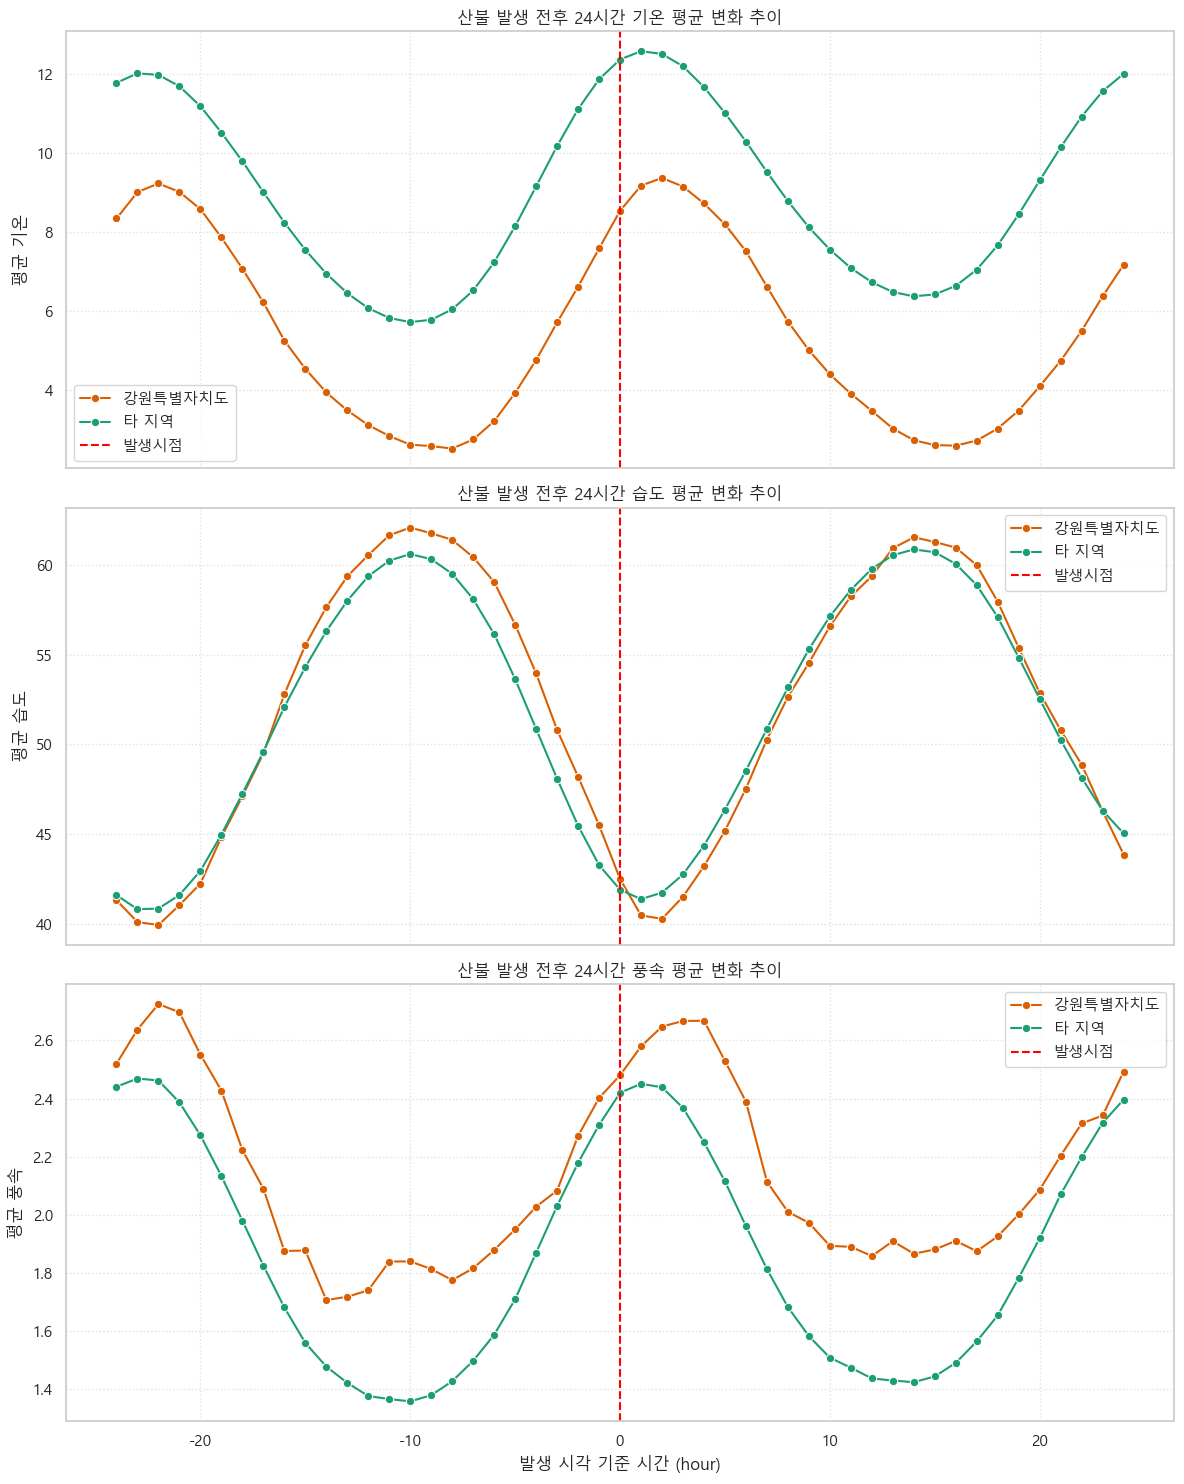

In [27]:
# 발생시각기준시간이 [-24, 24] 범위인 데이터 필터링
trend_df = hour_df[(hour_df["발생시각기준시간"] >= -24) & (hour_df["발생시각기준시간"] <= 24)].copy()

# 시간구분 및 region_group별 평균 계산
trend_summary = (
    trend_df
    .groupby(["region_group", "발생시각기준시간"])[["기온", "습도", "풍속"]]
    .mean()
    .reset_index()
)

# 시각화 (기온, 습도, 풍속의 발생 전후 24시간 패턴 비교)
fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
metrics = ["기온", "습도", "풍속"]
colors = ["#d95f02", "#1b9e77"]

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    sns.lineplot(
        data=trend_summary,
        x="발생시각기준시간",
        y=metric,
        hue="region_group",
        palette=colors,
        marker="o",
        ax=ax
    )
    ax.axvline(x=0, color="red", linestyle="--", linewidth=1.5, label="발생시점")
    ax.set_title(f"산불 발생 전후 24시간 {metric} 평균 변화 추이")
    ax.set_ylabel(f"평균 {metric}")
    ax.set_xlabel("발생 시각 기준 시간 (hour)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()

### 3.5. 시간별 날씨 변수 비교 분석 요약

1. **발생시각 기준 표본**: 발생시각(0h) 기준 시간별 데이터는 강원특별자치도 **4,139건**, 타 지역 **20,897건**입니다. 현지기압은 강원도 **3,998건**, 타 지역 **19,860건**의 유효 표본으로 비교했습니다.

2. **발생시각 기상 차이**: 강원도 발생시각 기온은 **8.54℃**로 타 지역 **12.37℃**보다 낮습니다. 풍속은 강원도 **2.48m/s**, 타 지역 **2.42m/s**로 차이는 작지만 강원도가 약간 높고, 습도는 강원도 **42.49%**, 타 지역 **41.89%**로 발생시각 단면에서는 큰 차이가 아닙니다.

3. **현지기압 해석**: 현지기압은 강원도 **988.57hPa**, 타 지역 **1007.38hPa**로 강원도가 낮습니다. 이는 대관령·태백산맥 등 고지대 관측 지점의 고도 영향이 섞인 결과이므로, 단순 저기압 영향으로만 해석하면 안 됩니다.

4. **발생 전후 24시간 시계열**: 플롯상 강원도는 발생 전후에 풍속 수준이 더 높게 유지되고, 타 지역보다 발생시각 부근의 바람 노출이 강합니다. 반면 습도 시계열은 전국 평균 단위에서는 강원도와 타 지역이 완전히 분리되기보다 비슷한 일변화 패턴을 공유합니다.

5. **결론**: 시간별 자료에서는 일자별 자료만큼 명확한 평균 차이보다, **발생시각 전후의 고풍속 지속성**과 **고도 영향을 포함한 기압 구조**가 강원도 특징으로 나타납니다.


## 4. 강원도 특화 가설 확인 (확장 분석 포함)
본 섹션에서는 강원도 산불 발생 기상의 특이점을 규명하기 위해 4가지 기존 가설과 3가지 추가 확장 가설을 데이터로 검증합니다.
- **가설 1 & 2**: 강원도 산불은 타 지역보다 풍속이 강하고 습도가 낮은 기상 조건에서 일어나는가? (통계적 T-Test 검정)
- **가설 3**: 겨울철과 봄철에 강원도와 타 지역의 기상 격차가 극대화되는가?
- **가설 4**: 풍향 8방위 분석 시 강원도 영동 지방의 국지풍(양간지풍 등 서풍 계열)의 특징이 발견되는가?
- **추가 가설 5**: 당일 및 전일 습도를 반영한 실효습도(effective_humidity) 기준 강원도 산림이 더 극심한 건조 조건에 처해 있는가?
- **추가 가설 6**: 풍속 구간별 분포 비교 시 강원도가 고풍속 산불 위험 노출 비중이 높은가?
- **추가 가설 7**: 기상 조건(바람, 습도)이 실제 산불의 진화 소요 시간에 미치는 영향력(상관 분석)이 강원도에서 더 뚜렷하게 작동하는가?

### 4.1. 가설 1 & 2: 풍속 및 습도 차이 유의성 검정 (T-Test)

=== 가설 1 & 2 독립표본 t-검정 결과 ===
[평균 풍속] t-value = 15.4444, p-value = 1.1696e-52 (유의수준 0.05 기준)
[최소 상대습도] t-value = -9.2298, p-value = 3.5979e-20 (유의수준 0.05 기준)


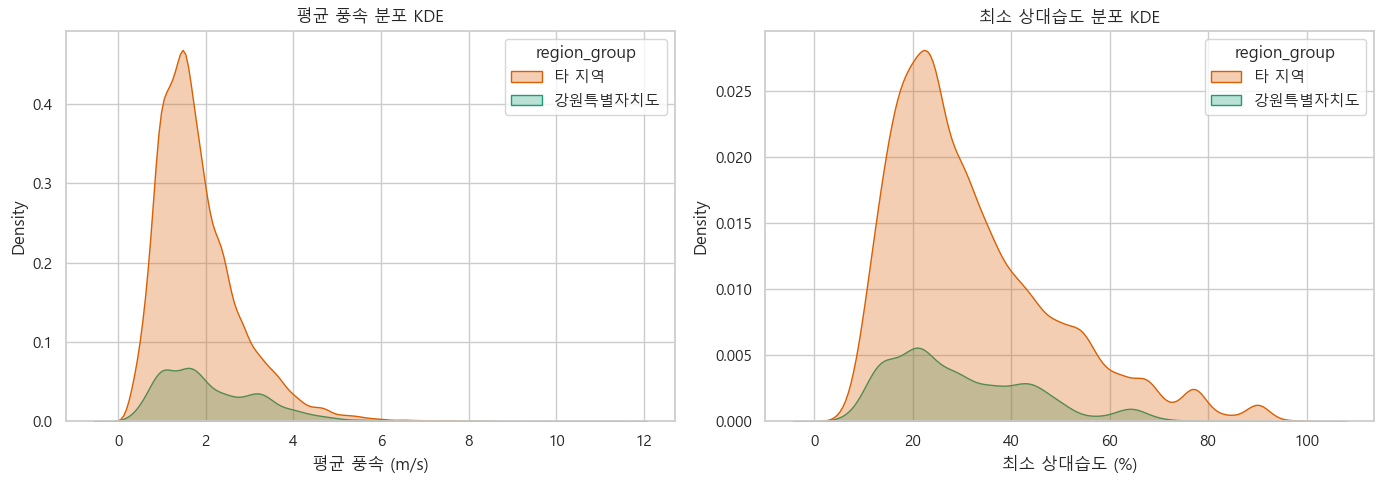

In [28]:
# 가설 1 & 2: 풍속/습도 차이 유의성 검정 (T-Test) 및 KDE 시각화
from scipy import stats

# 발생일 기준
gw_wind = day_active[day_active["is_gangwon"]]["평균 풍속"].dropna()
other_wind = day_active[~day_active["is_gangwon"]]["평균 풍속"].dropna()
t_wind, p_wind = stats.ttest_ind(gw_wind, other_wind, equal_var=False)

gw_humid = day_active[day_active["is_gangwon"]]["최소 상대습도"].dropna()
other_humid = day_active[~day_active["is_gangwon"]]["최소 상대습도"].dropna()
t_humid, p_humid = stats.ttest_ind(gw_humid, other_humid, equal_var=False)

print("=== 가설 1 & 2 독립표본 t-검정 결과 ===")
print(f"[평균 풍속] t-value = {t_wind:.4f}, p-value = {p_wind:.4e} (유의수준 0.05 기준)")
print(f"[최소 상대습도] t-value = {t_humid:.4f}, p-value = {p_humid:.4e} (유의수준 0.05 기준)")

# 시각화 (KDE Plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 풍속 KDE
sns.kdeplot(data=day_active, x="평균 풍속", hue="region_group", palette=["#d95f02", "#1b9e77"], fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title("평균 풍속 분포 KDE")
axes[0].set_xlabel("평균 풍속 (m/s)")

# 습도 KDE
sns.kdeplot(data=day_active, x="최소 상대습도", hue="region_group", palette=["#d95f02", "#1b9e77"], fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title("최소 상대습도 분포 KDE")
axes[1].set_xlabel("최소 상대습도 (%)")

plt.tight_layout()
plt.show()

### 4.2. 가설 3: 계절별 풍속/습도 격차 분석

=== 계절별 강원도 vs 타 지역 기상 요인 평균 ===
          계절 region_group     평균 풍속    최소 상대습도
0  가을(9-11월)      강원특별자치도  1.241518  42.154691
1  가을(9-11월)         타 지역  1.420829  37.727370
2  겨울(12-2월)      강원특별자치도  2.621259  26.730000
3  겨울(12-2월)         타 지역  1.848036  34.924861
4    봄(3-5월)      강원특별자치도  2.067433  24.387716
5    봄(3-5월)         타 지역  1.979885  26.706525
6   여름(6-8월)      강원특별자치도  1.765100  35.520731
7   여름(6-8월)         타 지역  1.570822  48.494844


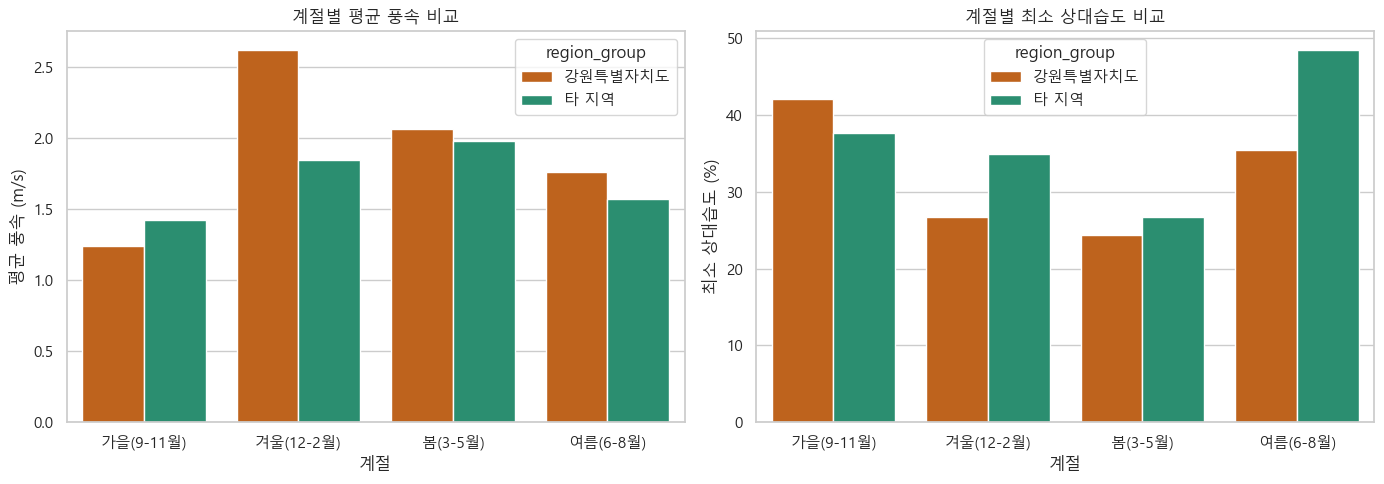

In [29]:
# 가설 3: 계절별 풍속/습도 격차 분석
def get_season(month):
    if month in [3, 4, 5]:
        return "봄(3-5월)"
    elif month in [6, 7, 8]:
        return "여름(6-8월)"
    elif month in [9, 10, 11]:
        return "가을(9-11월)"
    else:
        return "겨울(12-2월)"

day_active["계절"] = day_active["발생월"].apply(get_season)

# 계절별 평균 계산
season_stats = (
    day_active
    .groupby(["계절", "region_group"])[["평균 풍속", "최소 상대습도"]]
    .mean()
    .reset_index()
)

print("=== 계절별 강원도 vs 타 지역 기상 요인 평균 ===")
print(season_stats)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=season_stats, x="계절", y="평균 풍속", hue="region_group", palette=["#d95f02", "#1b9e77"], ax=axes[0])
axes[0].set_title("계절별 평균 풍속 비교")
axes[0].set_ylabel("평균 풍속 (m/s)")

sns.barplot(data=season_stats, x="계절", y="최소 상대습도", hue="region_group", palette=["#d95f02", "#1b9e77"], ax=axes[1])
axes[1].set_title("계절별 최소 상대습도 비교")
axes[1].set_ylabel("최소 상대습도 (%)")

plt.tight_layout()
plt.show()

### 4.3. 가설 4: 풍향 8방위 분석 (양간지풍 방증)

=== 발생시각 풍향 방위 비율 (%) ===
region_group    E     N   NE    NW     S   SE    SW     W
     강원특별자치도 7.22 14.06 6.72 10.85 11.43 7.15 20.56 22.01
        타 지역 7.04 17.95 8.27 17.09 10.04 7.47 14.06 18.07


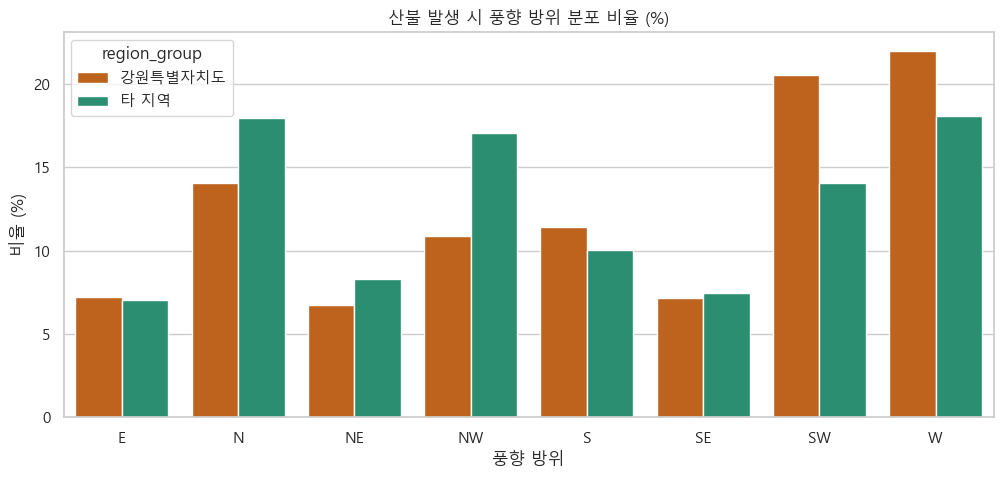

In [30]:
# 가설 4: 풍향 8방위 분석 (양간지풍 방증) - 영어 약어로 통일하여 매핑 에러 수정
def deg_to_8direction(deg):
    if pd.isna(deg):
        return np.nan
    deg = deg % 360
    if (deg >= 337.5) or (deg < 22.5):
        return "N"
    elif deg < 67.5:
        return "NE"
    elif deg < 112.5:
        return "E"
    elif deg < 157.5:
        return "SE"
    elif deg < 202.5:
        return "S"
    elif deg < 247.5:
        return "SW"
    elif deg < 292.5:
        return "W"
    else:
        return "NW"

# 발생시각(hour_active) 풍향 매핑
hour_active["풍향방위"] = hour_active["풍향"].apply(deg_to_8direction)

# 방위 비율 연산
wind_dir_ratio = (
    hour_active
    .groupby("region_group")["풍향방위"]
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
).round(2).reset_index()

print("=== 발생시각 풍향 방위 비율 (%) ===")
print(wind_dir_ratio.to_string(index=False))

# 풍향 비율 시각화
wind_dir_melt = wind_dir_ratio.melt(id_vars="region_group", var_name="풍향", value_name="비율(%)")

plt.figure(figsize=(12, 5))
sns.barplot(data=wind_dir_melt, x="풍향", y="비율(%)", hue="region_group", palette=["#d95f02", "#1b9e77"])
plt.title("산불 발생 시 풍향 방위 분포 비율 (%)")
plt.ylabel("비율 (%)")
plt.xlabel("풍향 방위")
plt.show()

### 4.4. 추가 가설 5 & 6: 실효습도 및 풍속 구간화 분석

=== 실효습도 기술통계량 비교 ===
                count       mean        std       min        25%        50%  \
region_group                                                                  
강원특별자치도        4139.0  29.085544  12.432587  6.277567  20.204426  26.157780   
타 지역          20897.0  31.807545  14.411962  3.777674  21.126819  28.122674   

                    75%        max  
region_group                        
강원특별자치도       37.097172  99.856968  
타 지역          39.930392  94.334766  


C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\1978836244.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_active, x="region_group", y="effective_humidity", palette=["#d95f02", "#1b9e77"], ax=axes[0])


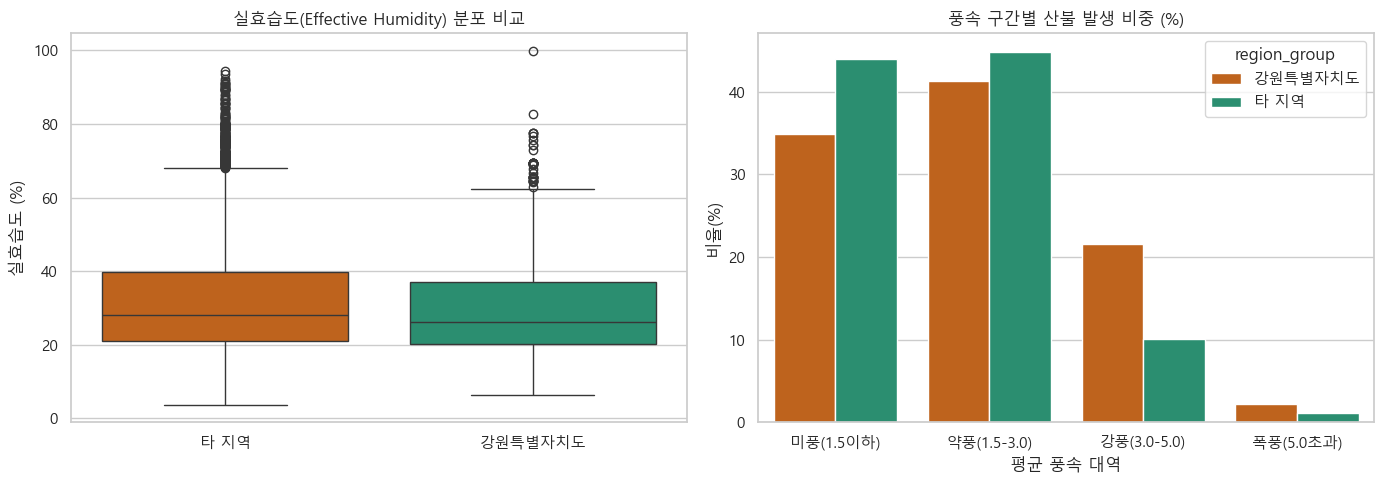

In [31]:
# 추가 가설 5 & 6: 실효습도 및 풍속 구간화 분석
import numpy as np

# 5. 실효습도 계산 (H_eff = 0.7 * H_0 + 0.3 * H_1)
h0 = day_df[day_df["날짜구분"] == "발생일"].set_index(ID_COL)["최소 상대습도"]
h1 = day_df[day_df["날짜구분"] == "과거1일"].set_index(ID_COL)["최소 상대습도"]
eff_humid_series = 0.7 * h0 + 0.3 * h1

# day_active 에 직접 effective_humidity 컬럼 추가
day_active["effective_humidity"] = day_active[ID_COL].map(eff_humid_series)

# 6. 풍속 구간화
bins = [0, 1.5, 3.0, 5.0, np.inf]
labels = ["미풍(1.5이하)", "약풍(1.5-3.0)", "강풍(3.0-5.0)", "폭풍(5.0초과)"]
day_active["풍속구간"] = pd.cut(day_active["평균 풍속"], bins=bins, labels=labels)

print("=== 실효습도 기술통계량 비교 ===")
print(day_active.groupby("region_group")["effective_humidity"].describe())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 실효습도 Boxplot
sns.boxplot(data=day_active, x="region_group", y="effective_humidity", palette=["#d95f02", "#1b9e77"], ax=axes[0])
axes[0].set_title("실효습도(Effective Humidity) 분포 비교")
axes[0].set_xlabel("")
axes[0].set_ylabel("실효습도 (%)")

# 풍속구간 비율 시각화
wind_cat_ratio = (
    day_active
    .groupby("region_group")["풍속구간"]
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
).round(2).reset_index()

wind_cat_melt = wind_cat_ratio.melt(id_vars="region_group", var_name="풍속구간", value_name="비율(%)")
sns.barplot(data=wind_cat_melt, x="풍속구간", y="비율(%)", hue="region_group", palette=["#d95f02", "#1b9e77"], ax=axes[1])
axes[1].set_title("풍속 구간별 산불 발생 비중 (%)")
axes[1].set_xlabel("평균 풍속 대역")

plt.tight_layout()
plt.show()

### 4.5. 추가 가설 7: 기상 조건과 진화소요시간 간의 상관 분석

=== 진화소요시간시와의 상관계수 비교 ===
                     강원특별자치도      타 지역
평균 풍속               0.241856  0.105630
최대 풍속               0.258314  0.124689
effective_humidity -0.030317 -0.054977


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


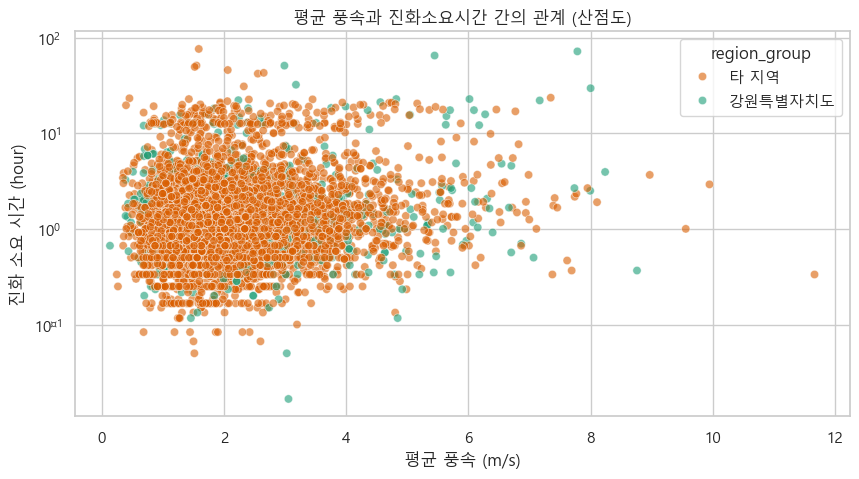

In [32]:
# 추가 가설 7: 기상 조건과 진화소요시간 간의 상관 분석
# 진화소요시간시가 있는 유효 데이터 필터링
valid_duration = day_active.dropna(subset=["진화소요시간시"])

corr_gw = valid_duration[valid_duration["region_group"] == "강원특별자치도"][["진화소요시간시", "평균 풍속", "최대 풍속", "effective_humidity"]].corr()["진화소요시간시"]
corr_other = valid_duration[valid_duration["region_group"] == "타 지역"][["진화소요시간시", "평균 풍속", "최대 풍속", "effective_humidity"]].corr()["진화소요시간시"]

corr_comparison = pd.DataFrame({
    "강원특별자치도": corr_gw,
    "타 지역": corr_other
}).drop("진화소요시간시")

print("=== 진화소요시간시와의 상관계수 비교 ===")
print(corr_comparison)

# 시각화 (풍속과 진화소요시간시 Scatter plot)
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=valid_duration,
    x="평균 풍속",
    y="진화소요시간시",
    hue="region_group",
    palette=["#d95f02", "#1b9e77"],
    alpha=0.6
)
plt.title("평균 풍속과 진화소요시간 간의 관계 (산점도)")
plt.xlabel("평균 풍속 (m/s)")
plt.ylabel("진화 소요 시간 (hour)")
plt.yscale("log") # 시간 편차가 크므로 log scale 적용
plt.show()

### 4.6. 강원도 특화 가설 검증 결과 요약

1. **풍속 및 습도 차이**: 발생일 기준 평균 풍속은 강원도가 유의하게 높고($t=15.44$, $p=1.17e-52$), 최소 상대습도는 강원도가 유의하게 낮습니다($t=-9.23$, $p=3.60e-20$). KDE 플롯에서도 강원도는 3~6m/s 풍속 꼬리와 10~30% 저습 구간의 밀도가 상대적으로 두껍습니다.

2. **계절별 편차**: 겨울철(12~2월) 강원도 평균 풍속은 **2.62m/s**로 타 지역 **1.85m/s**보다 높고, 최소 상대습도는 강원도 **26.73%**, 타 지역 **34.92%**입니다. 봄철에도 강원도 최소 상대습도 **24.39%**로 타 지역 **26.71%**보다 낮아, 겨울~봄 사이 저온 건조·강풍 신호가 이어집니다.

3. **풍향 분포**: 발생시각 풍향 8방위에서 강원도는 W **22.01%**, SW **20.56%**로 W+SW 계열이 **42.57%**입니다. 타 지역의 W+SW **32.13%**보다 높아 서풍·남서풍 계열 바람길 신호가 강합니다.

4. **실효습도와 진화시간**: 실효습도 평균은 강원도 **29.09%**, 타 지역 **31.81%**입니다. 진화소요시간과의 단순 상관은 강원도에서 평균 풍속 **0.242**, 최대 풍속 **0.258**로 타 지역보다 강하지만, 실효습도와의 선형 상관은 약합니다. 따라서 진화 지연은 단일 습도 변수보다 강풍, 지형, 접근성 등과의 결합으로 보는 것이 타당합니다.


## 5. 시각화 산출물 종합
본 섹션에서는 1~4단계에서 도출된 핵심 결과들을 시각적으로 집대성하고, 다각적이고 고도화된 3가지 시각화 분석(상관관계 Heatmap, 극좌표 풍향 분포, 풍속-진화 난이도 회귀 플롯)을 수행하여 지역별 특이점을 대조 분석합니다.

### 5.1. 기존 시각화 완료 내역
- **지역 구분별 발생 건수**: Cell 10 barplot
- **시도별 발생 건수**: Cell 13 barplot
- **연도별/월별/시간대별 분포**: Cell 17, 20, 23 lineplot
- **기상 요인 및 실효습도 분포**: [2. 일자별 날씨 변수 비교] Cell 36 boxplot 및 [4. 강원도 특화 가설 확인] Cell 54 boxplot
- **발생 전후 24시간 시계열 흐름**: [3. 시간별 날씨 변수 비교] Cell 48 lineplot

### 5.2. 주요 변수 간 상관관계 Heatmap 대조 분석
강원특별자치도와 타 지역의 주요 기상 인자 및 진화 소요 시간 간의 상관성이 어떻게 다르게 얽혀 있는지 파악합니다.

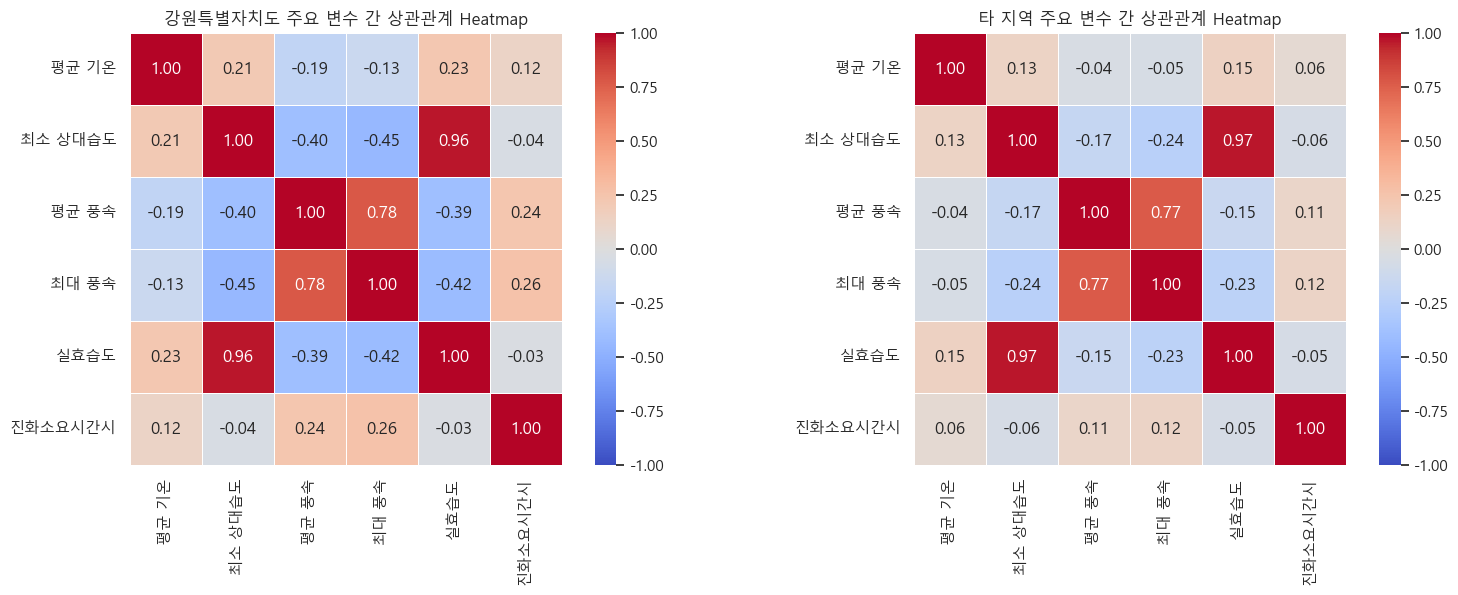

In [33]:
# 상관분석 대상 변수 필터링
corr_cols = ["평균 기온", "최소 상대습도", "평균 풍속", "최대 풍속", "effective_humidity", "진화소요시간시"]

# 강원도와 타 지역의 상관계수 행렬 계산
gw_corr = day_active[day_active["is_gangwon"]][corr_cols].corr()
other_corr = day_active[~day_active["is_gangwon"]][corr_cols].corr()

# 시각화용 레이블 rename
rename_dict = {"effective_humidity": "실효습도"}
gw_corr.rename(columns=rename_dict, index=rename_dict, inplace=True)
other_corr.rename(columns=rename_dict, index=rename_dict, inplace=True)

# Heatmap 시각화 (Subplots 1x2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 강원도 Heatmap
sns.heatmap(
    gw_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    square=True,
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("강원특별자치도 주요 변수 간 상관관계 Heatmap")

# 타 지역 Heatmap
sns.heatmap(
    other_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    square=True,
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title("타 지역 주요 변수 간 상관관계 Heatmap")

plt.tight_layout()
plt.show()

### 5.3. 극좌표(Polar)를 활용한 8방위 풍향 분포 비교
산불 발생 시 바람의 방위별 비중을 나침반 형태의 원형 극좌표 플롯에 투영하여, 영동 지방의 국지풍(서풍 계열)의 집중 양상을 입체적으로 관찰합니다.

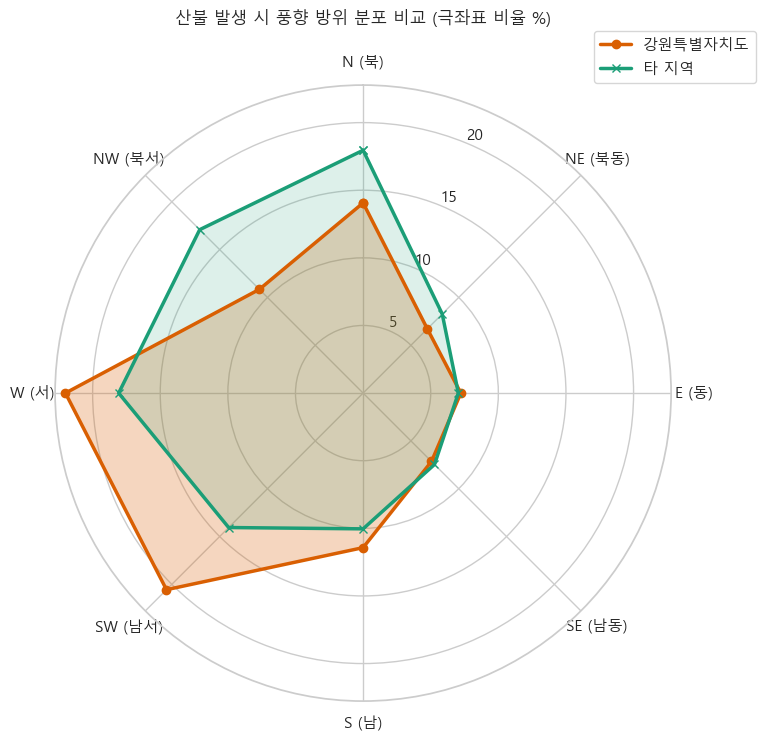

In [34]:
# 8방위 닫힌 루프(0-360도 접점 융합) 데이터 구성
directions = ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"]
theta = np.deg2rad([0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0, 360.0])

# 방위 비율 연산 결과 추출
wind_dir_ratio = (
    hour_active
    .groupby("region_group")["풍향방위"]
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
)

gw_vals = [wind_dir_ratio.loc["강원특별자치도", d] if d in wind_dir_ratio.columns else 0.0 for d in directions]
other_vals = [wind_dir_ratio.loc["타 지역", d] if d in wind_dir_ratio.columns else 0.0 for d in directions]

# polar plot 그리기
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location('N') # 북쪽이 0도
ax.set_theta_direction(-1) # 시계 방향 회전

# 강원도 라인 및 면적 채우기
ax.plot(theta, gw_vals, label="강원특별자치도", marker="o", color="#d95f02", linewidth=2.5)
ax.fill(theta, gw_vals, color="#d95f02", alpha=0.25)

# 타 지역 라인 및 면적 채우기
ax.plot(theta, other_vals, label="타 지역", marker="x", color="#1b9e77", linewidth=2.5)
ax.fill(theta, other_vals, color="#1b9e77", alpha=0.15)

# 레이블 설정
ax.set_xticks(theta[:-1])
ax.set_xticklabels(["N (북)", "NE (북동)", "E (동)", "SE (남동)", "S (남)", "SW (남서)", "W (서)", "NW (북서)"])
ax.set_title("산불 발생 시 풍향 방위 분포 비교 (극좌표 비율 %)", va='bottom', y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.1))

plt.show()

### 5.4. 풍속과 진화 소요 시간 간의 상관 회귀 분석 (Regression Lmplot)
강원도와 타 지역에서 풍속의 강도가 실제 진화 난이도에 미치는 민감도 격차를 회귀선 기울기로 직관화합니다.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


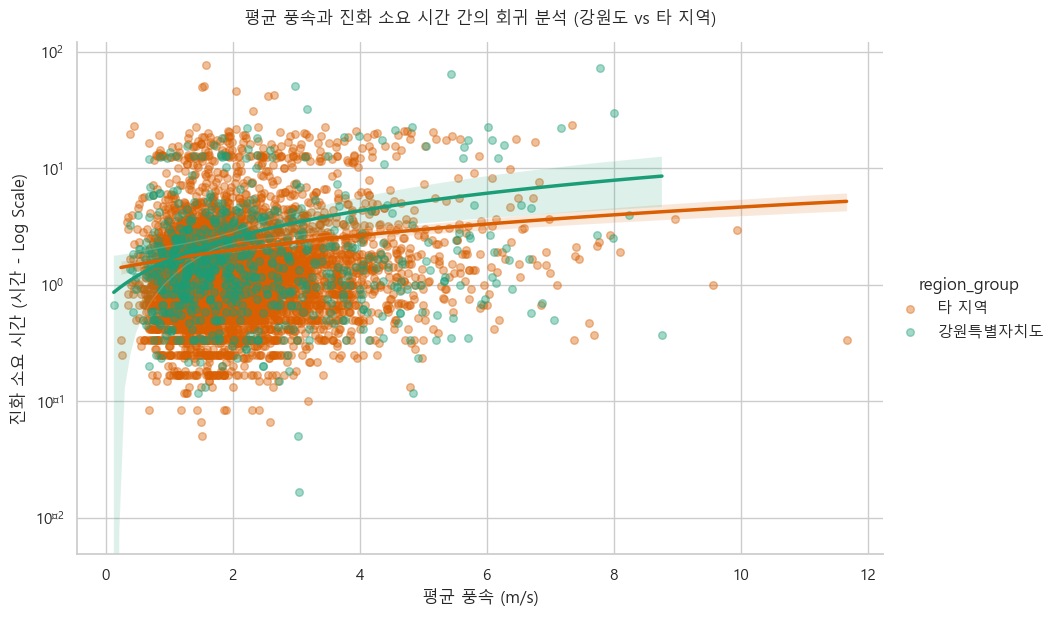

In [35]:
# 진화소요시간시가 기록된 데이터 필터링
valid_duration = day_active.dropna(subset=["진화소요시간시"])

# lmplot 을 활용해 회귀선과 데이터 산점도를 동시에 렌더링
g = sns.lmplot(
    data=valid_duration,
    x="평균 풍속",
    y="진화소요시간시",
    hue="region_group",
    palette=["#d95f02", "#1b9e77"],
    height=6,
    aspect=1.5,
    scatter_kws={"alpha": 0.4, "s": 30},
    line_kws={"linewidth": 2.5}
)

# y축 진화 시간 격차가 크므로 로그스케일 적용
g.set(yscale="log")
g.set_axis_labels("평균 풍속 (m/s)", "진화 소요 시간 (시간 - Log Scale)")
plt.title("평균 풍속과 진화 소요 시간 간의 회귀 분석 (강원도 vs 타 지역)", y=1.02)
plt.show()

### 5.5. 상관관계 및 고도화 시각화 해석 종합

1. **풍속과 상대습도의 동조성**: 강원도 상관 히트맵에서 평균 풍속과 최소 상대습도의 상관은 **-0.40**, 최대 풍속과 최소 상대습도의 상관은 **-0.45**입니다. 타 지역은 각각 **-0.17**, **-0.24**로 약합니다. 즉 강원도에서는 바람이 강해질수록 습도가 함께 낮아지는 결합 신호가 더 뚜렷합니다.

2. **풍향 집중성**: 극좌표 플롯에서 강원도는 W와 SW 방향이 크게 부풀어 있습니다. W+SW 비중은 강원도 **42.57%**, 타 지역 **32.13%**로, 강원도 산불 발생 시점의 서풍·남서풍 계열 집중성이 확인됩니다.

3. **진화소요시간과 풍속**: 산점도와 회귀선에서는 평균 풍속이 커질수록 진화소요시간의 상방 꼬리가 길어지는 패턴이 보입니다. 강원도는 고풍속 구간의 표본이 상대적으로 많고 진화시간의 변동 폭도 커, 평균 효과보다 **고위험 꼬리 위험**을 별도로 모델링할 필요가 있습니다.

4. **해석 제한**: 상관계수와 회귀선은 결측을 제외한 관측 표본의 단순 관계입니다. 진화시간은 기록 결측이 많으므로, 모든 산불에 대한 평균 위험으로 일반화하지 않고 유효 표본 내 탐색 결과로 해석합니다.


## 6. 추가 심층 분석
본 섹션에서는 수집 기준의 일관성을 검증하기 위해 최신 2020~2021년 한정 데이터셋으로 가설을 재검정하고, 대형 산불(진화 지연)이 초래되는 구체적인 기상 임계치(Threshold)와 풍향-풍속 복합 융합 분석을 수행합니다.

### 6.1. 2020~2021년 한정 가설 재검정
데이터 누락이 없는 최신 2개년 데이터를 기준으로 기상 격차의 통계적 유의성을 재검증합니다.

In [36]:
# 6.1. 2020~2021년 한정 가설 재검정
from scipy import stats

# 2020년, 2021년 데이터만 한정 필터링
day_active_recent = day_active[day_active["발생연도"].isin([2020, 2021])].copy()
hour_active_recent = hour_active[hour_active["발생연도"].isin([2020, 2021])].copy()

# t-test 재검증
recent_gw_wind = day_active_recent[day_active_recent["is_gangwon"]]["평균 풍속"].dropna()
recent_other_wind = day_active_recent[~day_active_recent["is_gangwon"]]["평균 풍속"].dropna()
t_wind_r, p_wind_r = stats.ttest_ind(recent_gw_wind, recent_other_wind, equal_var=False)

recent_gw_humid = day_active_recent[day_active_recent["is_gangwon"]]["최소 상대습도"].dropna()
recent_other_humid = day_active_recent[~day_active_recent["is_gangwon"]]["최소 상대습도"].dropna()
t_humid_r, p_humid_r = stats.ttest_ind(recent_gw_humid, recent_other_humid, equal_var=False)

recent_gw_eff = day_active_recent[day_active_recent["is_gangwon"]]["effective_humidity"].dropna()
recent_other_eff = day_active_recent[~day_active_recent["is_gangwon"]]["effective_humidity"].dropna()
t_eff_r, p_eff_r = stats.ttest_ind(recent_gw_eff, recent_other_eff, equal_var=False)

print("=== [2020-2021 한정] 독립표본 t-검정 결과 ===")
print(f"[평균 풍속] t-value = {t_wind_r:.4f}, p-value = {p_wind_r:.4e}")
print(f"[최소 상대습도] t-value = {t_humid_r:.4f}, p-value = {p_humid_r:.4e}")
print(f"[실효습도] t-value = {t_eff_r:.4f}, p-value = {p_eff_r:.4e}")

# 기술통계 대조 요약
comparison_recent = (
    day_active_recent
    .groupby("region_group")[["평균 풍속", "최소 상대습도", "effective_humidity"]]
    .mean()
)
print("\n=== [2020-2021 한정] 기상 변수 평균값 비교 ===")
print(comparison_recent)

=== [2020-2021 한정] 독립표본 t-검정 결과 ===
[평균 풍속] t-value = 18.0473, p-value = 2.5675e-70
[최소 상대습도] t-value = -13.9742, p-value = 1.1476e-43
[실효습도] t-value = -17.5853, p-value = 1.8239e-67

=== [2020-2021 한정] 기상 변수 평균값 비교 ===
                 평균 풍속    최소 상대습도  effective_humidity
region_group                                         
강원특별자치도       2.113702  31.464396           30.587398
타 지역          1.731251  35.511881           34.935089


### 6.2. 대형 산불(진화 지연) 기상 임계치(Threshold) 규명
진화 소요 시간이 12시간 및 24시간을 초과하는 대형 산불로 번질 확률이 풍속과 실효습도 조건에 따라 어떻게 수직 상승하는지 규명합니다.

=== [강원도] 풍속 임계치별 대형 산불(12h/24h) 발생 확률 (%) ===
평균 풍속 1.5 m/s 이상 (표본 469건): 12h 지연 비율 = 7.68%, 24h 지연 비율 = 1.07%
평균 풍속 3.0 m/s 이상 (표본 169건): 12h 지연 비율 = 11.83%, 24h 지연 비율 = 2.37%
평균 풍속 5.0 m/s 이상 (표본 49건): 12h 지연 비율 = 24.49%, 24h 지연 비율 = 6.12%

=== [강원도] 실효습도 임계치별 대형 산불(12h/24h) 발생 확률 (%) ===
실효습도 40% 이하 (표본 693건): 12h 지연 비율 = 5.77%, 24h 지연 비율 = 0.72%
실효습도 30% 이하 (표본 612건): 12h 지연 비율 = 6.05%, 24h 지연 비율 = 0.82%
실효습도 20% 이하 (표본 357건): 12h 지연 비율 = 7.00%, 24h 지연 비율 = 1.40%


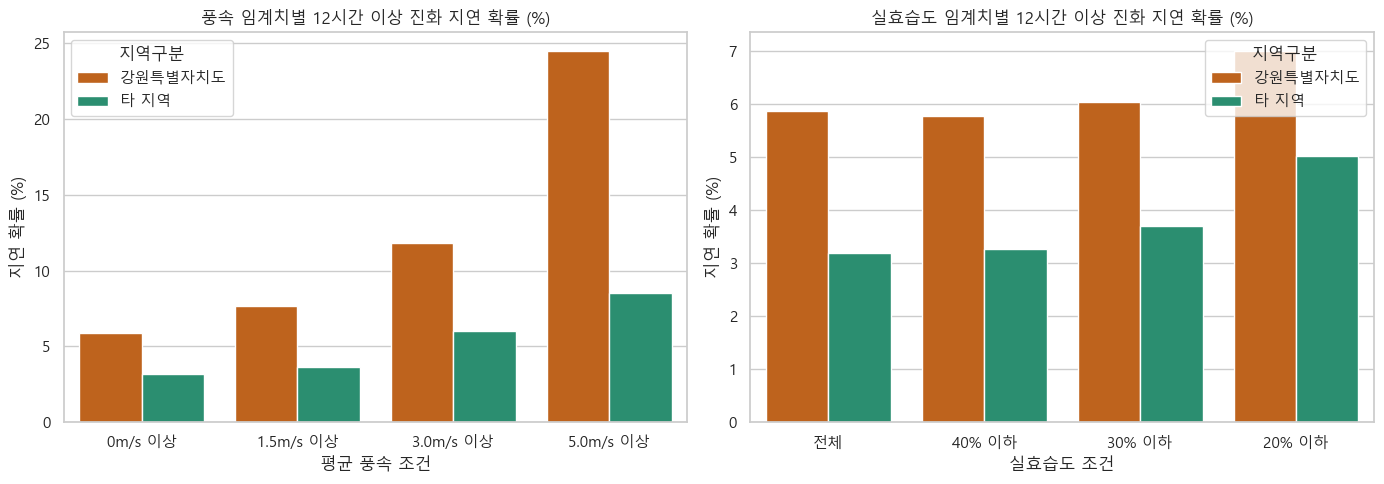

In [37]:
# 6.2. 대형 산불 기상 임계치(Threshold) 규명
# 진화소요시간이 기록된 전체 유효 데이터 사용 (2020~2021년은 진화시간 기록 누락)
valid_all = day_active.dropna(subset=["진화소요시간시"]).copy()
valid_all["is_delayed_12h"] = valid_all["진화소요시간시"] >= 12
valid_all["is_delayed_24h"] = valid_all["진화소요시간시"] >= 24

# 기상 임계 조건 정의
wind_thresholds = [1.5, 3.0, 5.0]
humid_thresholds = [40, 30, 20]

print("=== [강원도] 풍속 임계치별 대형 산불(12h/24h) 발생 확률 (%) ===")
gw_valid = valid_all[valid_all["is_gangwon"]]
for w in wind_thresholds:
    subset = gw_valid[gw_valid["평균 풍속"] >= w]
    ratio_12 = subset["is_delayed_12h"].mean() * 100 if len(subset) > 0 else 0
    ratio_24 = subset["is_delayed_24h"].mean() * 100 if len(subset) > 0 else 0
    print(f"평균 풍속 {w} m/s 이상 (표본 {len(subset)}건): 12h 지연 비율 = {ratio_12:.2f}%, 24h 지연 비율 = {ratio_24:.2f}%")

print("\n=== [강원도] 실효습도 임계치별 대형 산불(12h/24h) 발생 확률 (%) ===")
for h in humid_thresholds:
    subset = gw_valid[gw_valid["effective_humidity"] <= h]
    ratio_12 = subset["is_delayed_12h"].mean() * 100 if len(subset) > 0 else 0
    ratio_24 = subset["is_delayed_24h"].mean() * 100 if len(subset) > 0 else 0
    print(f"실효습도 {h}% 이하 (표본 {len(subset)}건): 12h 지연 비율 = {ratio_12:.2f}%, 24h 지연 비율 = {ratio_24:.2f}%")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 풍속 조건 시각화
wind_probs = []
for w in [0, 1.5, 3.0, 5.0]:
    for region in ["강원특별자치도", "타 지역"]:
        sub = valid_all[(valid_all["region_group"] == region) & (valid_all["평균 풍속"] >= w)]
        wind_probs.append({
            "풍속조건": f"{w}m/s 이상",
            "지역구분": region,
            "12h지연확률(%)": sub["is_delayed_12h"].mean() * 100 if len(sub) > 0 else 0
        })
wind_prob_df = pd.DataFrame(wind_probs)
sns.barplot(data=wind_prob_df, x="풍속조건", y="12h지연확률(%)", hue="지역구분", palette=["#d95f02", "#1b9e77"], ax=axes[0])
axes[0].set_title("풍속 임계치별 12시간 이상 진화 지연 확률 (%)")
axes[0].set_xlabel("평균 풍속 조건")
axes[0].set_ylabel("지연 확률 (%)")

# 습도 조건 시각화
humid_probs = []
for h in [100, 40, 30, 20]:
    cond_str = "전체" if h == 100 else f"{h}% 이하"
    for region in ["강원특별자치도", "타 지역"]:
        sub = valid_all[(valid_all["region_group"] == region) & (valid_all["effective_humidity"] <= h)]
        humid_probs.append({
            "실효습도조건": cond_str,
            "지역구분": region,
            "12h지연확률(%)": sub["is_delayed_12h"].mean() * 100 if len(sub) > 0 else 0
        })
humid_prob_df = pd.DataFrame(humid_probs)
sns.barplot(data=humid_prob_df, x="실효습도조건", y="12h지연확률(%)", hue="지역구분", palette=["#d95f02", "#1b9e77"], ax=axes[1])
axes[1].set_title("실효습도 임계치별 12시간 이상 진화 지연 확률 (%)")
axes[1].set_xlabel("실효습도 조건")
axes[1].set_ylabel("지연 확률 (%)")

plt.tight_layout()
plt.show()

### 6.3. 풍향-풍속 2-way 융합 분석 (양간지풍 검증)
서풍 계열(W/SW)이면서 풍속이 강풍(3.0m/s 이상) 조건인 산불 비중을 분석하여 강원도 영동 지방의 기후 특이성을 실증합니다.

=== [2020-2021 한정] 풍향-풍속 2-way 복합 조건 비율 (%) ===
region_group  서풍계열 강풍 (양간지풍 조건)  서풍계열 약풍  타풍향 강풍  타풍향 약풍
     강원특별자치도              20.00    20.12   10.81   49.07
        타 지역              10.52    19.33   13.87   56.28


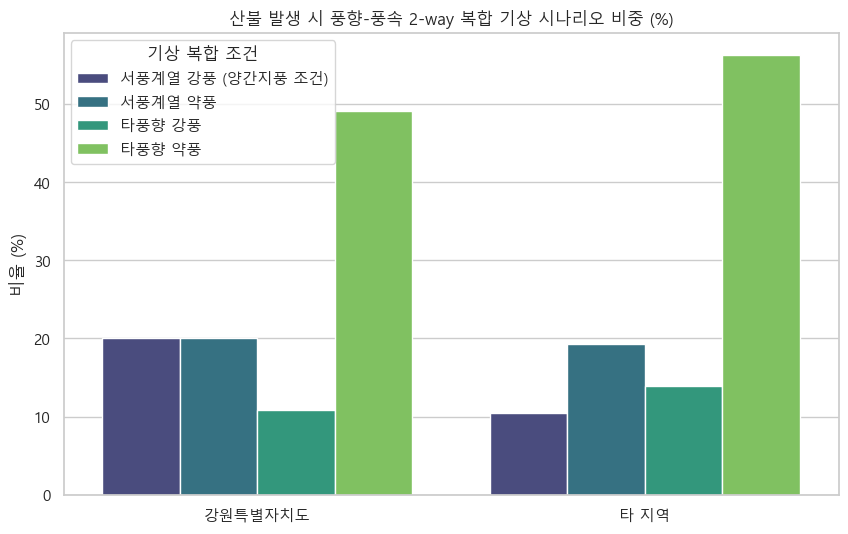

In [38]:
# 6.3. 풍향-풍속 2-way 융합 분석
# 풍향 구분 (서풍계열 W, SW vs 타 풍향)
hour_active_recent["is_west_wind"] = hour_active_recent["풍향방위"].isin(["W", "SW"])
# 풍속 구분 (3m/s 이상 강풍 vs 약풍)
hour_active_recent["is_strong_wind"] = hour_active_recent["풍속"] >= 3.0

# 2-way 복합 조건 매핑
def get_wind_type(row):
    if row["is_west_wind"] and row["is_strong_wind"]:
        return "서풍계열 강풍 (양간지풍 조건)"
    elif row["is_west_wind"]:
        return "서풍계열 약풍"
    elif row["is_strong_wind"]:
        return "타풍향 강풍"
    else:
        return "타풍향 약풍"

hour_active_recent["풍바람유형"] = hour_active_recent.apply(get_wind_type, axis=1)

# 비율 산출
wind_combo_ratio = (
    hour_active_recent
    .groupby("region_group")["풍바람유형"]
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
).round(2).reset_index()

print("=== [2020-2021 한정] 풍향-풍속 2-way 복합 조건 비율 (%) ===")
print(wind_combo_ratio.to_string(index=False))

# 시각화 (Stacked Bar Chart)
wind_combo_melt = wind_combo_ratio.melt(id_vars="region_group", var_name="기상복합조건", value_name="비율(%)")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=wind_combo_melt,
    x="region_group",
    y="비율(%)",
    hue="기상복합조건",
    palette="viridis"
)
plt.title("산불 발생 시 풍향-풍속 2-way 복합 기상 시나리오 비중 (%)")
plt.xlabel("")
plt.ylabel("비율 (%)")
plt.legend(title="기상 복합 조건")
plt.show()

### 6.4. 추가 심층 분석 결과 요약

1. **2020~2021년 한정 검정**: 최신 표본이 집중된 2020~2021년만 보아도 평균 풍속($t=18.05$), 최소 상대습도($t=-13.97$), 실효습도($t=-17.59$) 차이는 유지됩니다. 이 기간 강원도 평균 풍속은 **2.11m/s**, 타 지역은 **1.73m/s**이고, 강원도 최소 상대습도는 **31.46%**, 타 지역은 **35.51%**입니다.

2. **진화 지연 풍속 임계치**: 강원도 진화시간 유효 표본에서 평균 풍속 **5.0m/s 이상** 구간은 49건이며, 12시간 이상 진화 지연 비율이 **24.49%**입니다. 3.0m/s 이상 구간의 **11.83%**, 1.5m/s 이상 구간의 **7.68%**보다 크게 높아 강풍 임계성이 뚜렷합니다.

3. **실효습도 임계치**: 실효습도 40%, 30%, 20% 이하로 낮출수록 12시간 이상 지연 비율은 **5.77% → 6.05% → 7.00%**로 완만히 증가합니다. 단독 습도 임계치보다 풍속 임계치가 진화 지연을 더 선명하게 구분합니다.

4. **풍향-풍속 2-way 조건**: 2020~2021년 발생시각 기준 서풍계열 강풍 조건 비율은 강원도 **20.00%**, 타 지역 **10.52%**입니다. 강원도는 서풍·남서풍 바람길과 3m/s 이상 강풍이 동시에 나타나는 비중이 약 2배 높습니다.


## 7. EDA 결과 정리
본 EDA 프로젝트를 통해 전력설비 인근 화재 위험도 분석 및 모델링을 위한 핵심 기상 요인을 탐색하고, 강원도 영동 지방과 타 지역 간의 기후적 환경 차이를 정량적으로 검증하였습니다.

### 7.1. 핵심 기상 피처 및 전처리 가이드

1. **강원도형 산불 예측 모델 핵심 피처 후보군**:
   - **평균 풍속 및 최대 풍속 (우선 후보)**: 강원도 지역에서 타 지역 대비 높은 분포를 보이며, 진화소요시간 유효 표본에서도 진화 지연과 양의 상관이 나타납니다.
   - **실효습도 (H_eff) (우선 후보)**: 당일 및 전일 최소 상대습도를 함께 반영해 단순 당일 습도보다 누적 건조도를 표현할 수 있습니다. 현재 노트북의 `H_eff = 0.7 * H_0 + 0.3 * H_1`은 탐색용 가중식이므로, 모델링 단계에서는 검증 또는 대안 가중식 비교가 필요합니다.
   - **풍향 방위 (서풍/남서풍 계열 여부) (후보)**: W/SW 계열 여부는 강원도 국지풍 가설을 모델에 반영할 수 있는 범주형 피처 후보입니다.
   - **이슬점 격차 및 VPD (후보)**: 이슬점 격차는 강원도에서 더 크게 나타났고, VPD는 강원도가 오히려 낮아 기온 효과가 크게 작용했습니다. 두 변수는 서로 다른 건조 메커니즘을 설명하므로 함께 비교할 가치가 있습니다.

2. **모델링 시 배제할 피처 및 전처리 이슈**:
   - **진화소요시간시 (사전 위험도 예측 피처에서는 배제)**: 진화소요시간은 산불 발생 이후 관측되는 결과 변수이므로, 사전 화재 위험도를 예측하는 독립 변수로 사용하면 Target Leakage가 발생합니다.
   - **2020~2021년 진화 시간 데이터 전원 누락**: 2020년과 2021년 산불 데이터는 현재 날씨 매칭 데이터의 약 74.2%를 차지하지만, 진화 시간 기록이 전부 결측입니다. 진화 지연 또는 대형 산불 여부를 타겟으로 삼는다면 결측치가 없는 서브셋으로 별도 학습해야 합니다.
   - **2014~2019년 강원도 데이터 누락**: 해당 기간의 강원도 표본이 0건이므로, 연도별 분포를 그대로 학습하면 기간 편향이 모델에 반영될 수 있습니다.
   - **원본 산불 CSV와 날씨 매칭 CSV의 기준 차이**: 현재 날씨 매칭 데이터에는 원본 산불 CSV에 없는 143건이 추가로 존재합니다. 최종 산출물에서는 어느 파일을 기준 데이터로 사용할지 먼저 확정해야 합니다.
   - **발생 사건만 있는 데이터 구조**: 본 EDA는 산불 발생 사건 내부의 조건 비교입니다. 실제 “발생 위험도” 모델을 만들려면 비발생 지점/날짜 샘플링 전략이 추가로 필요합니다.


## 8. 심화 기상 분석
본 섹션에서는 날씨 데이터셋의 사건 매칭(사건 발생 전후 국소 범위 매칭) 구조적 특성을 활용하여, 3가지 기상 변화 패턴(하루 전 대비 기상 급변폭, 발생 전 24시간 위험 노출 누적 시간, 발생 후 기상 완화 속도)을 다각도로 분석합니다.

### 8.1. 발생일 vs 과거 1일 기상 변화폭 (Delta) 분석
산불이 발생한 당일의 날씨와 그 하루 전날 날씨 간의 격차(Delta)를 산출하여 강원도 산불의 기상 급변(Shock) 유발 특성을 분석합니다.

=== 지역별 평균 기상 변화량 (발생일 - 과거1일) ===
              delta_wind  delta_humid
region_group                         
강원특별자치도         0.088258     2.019789
타 지역           -0.037808     0.737711
[풍속 변화폭 T-Test] t-value = 7.7668, p-value = 9.5403e-15
[습도 변화폭 T-Test] t-value = 5.3687, p-value = 8.2141e-08


C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\1219001560.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=delta_df, x='region_group', y='delta_wind', palette=['#d95f02', '#1b9e77'], ax=axes[0])
C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\1219001560.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=delta_df, x='region_group', y='delta_humid', palette=['#d95f02', '#1b9e77'], ax=axes[1])


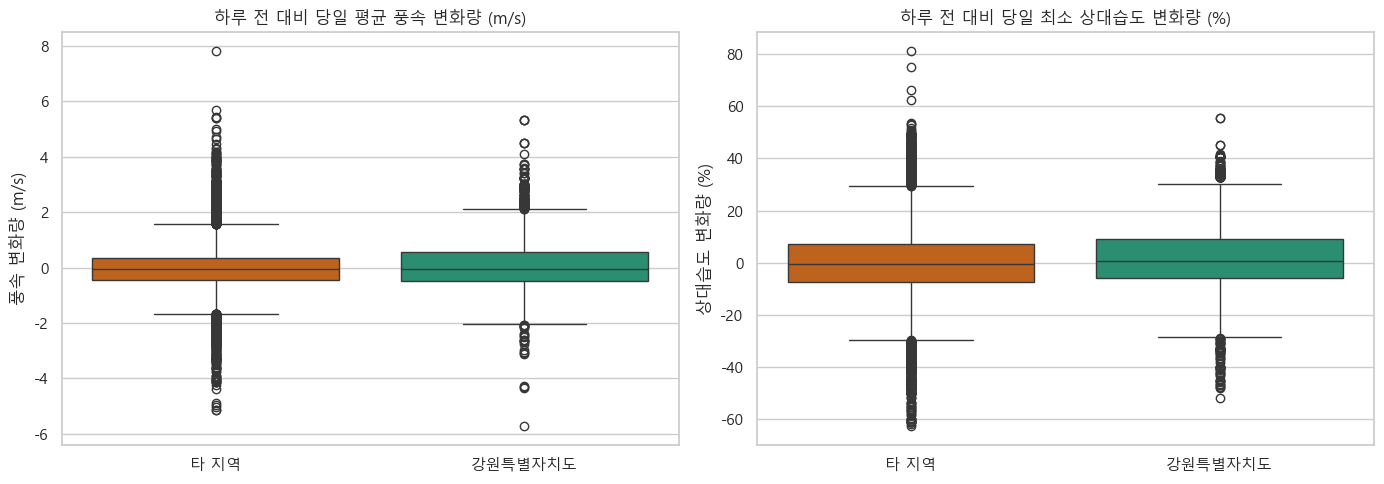

In [39]:
# 8.1. 발생일 vs 과거 1일 기상 변화폭 (Delta) 분석
active_subset = day_active[['산불아이디', '평균 풍속', '최소 상대습도', 'is_gangwon', 'region_group']].rename(
    columns={'평균 풍속': 'wind_active', '최소 상대습도': 'humid_active'}
)
past_subset = day_df[day_df['날짜구분'] == '과거1일'][['산불아이디', '평균 풍속', '최소 상대습도']].rename(
    columns={'평균 풍속': 'wind_past', '최소 상대습도': 'humid_past'}
)

delta_df = pd.merge(active_subset, past_subset, on='산불아이디', how='inner')
delta_df['delta_wind'] = delta_df['wind_active'] - delta_df['wind_past']
delta_df['delta_humid'] = delta_df['humid_active'] - delta_df['humid_past']

print('=== 지역별 평균 기상 변화량 (발생일 - 과거1일) ===')
print(delta_df.groupby('region_group')[['delta_wind', 'delta_humid']].mean())

# 독립표본 t-검정
gw_d_wind = delta_df[delta_df['is_gangwon']]['delta_wind'].dropna()
other_d_wind = delta_df[~delta_df['is_gangwon']]['delta_wind'].dropna()
t_d_wind, p_d_wind = stats.ttest_ind(gw_d_wind, other_d_wind, equal_var=False)

gw_d_humid = delta_df[delta_df['is_gangwon']]['delta_humid'].dropna()
other_d_humid = delta_df[~delta_df['is_gangwon']]['delta_humid'].dropna()
t_d_humid, p_d_humid = stats.ttest_ind(gw_d_humid, other_d_humid, equal_var=False)

print(f'[풍속 변화폭 T-Test] t-value = {t_d_wind:.4f}, p-value = {p_d_wind:.4e}')
print(f'[습도 변화폭 T-Test] t-value = {t_d_humid:.4f}, p-value = {p_d_humid:.4e}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=delta_df, x='region_group', y='delta_wind', palette=['#d95f02', '#1b9e77'], ax=axes[0])
axes[0].set_title('하루 전 대비 당일 평균 풍속 변화량 (m/s)')
axes[0].set_ylabel('풍속 변화량 (m/s)')
axes[0].set_xlabel('')

sns.boxplot(data=delta_df, x='region_group', y='delta_humid', palette=['#d95f02', '#1b9e77'], ax=axes[1])
axes[1].set_title('하루 전 대비 당일 최소 상대습도 변화량 (%)')
axes[1].set_ylabel('상대습도 변화량 (%)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 8.2. 발생 전 24시간 동안의 누적 위험 기상 노출 시간 분석
산불 발생 직전 24시간 동안 위험 수준의 바람(>= 3.0m/s)과 건조도(<= 30%)에 노출된 지속 시간(시수)을 계산해 비교합니다.

=== 발생 전 24시간 동안 평균 위험 기상 노출 시수(Hours) ===
              strong_wind_hours  dry_humid_hours
region_group                                    
강원특별자치도                6.590964         6.150036
타 지역                   4.803369         7.018711
[강풍 노출시간 T-Test] t-value = 15.5633, p-value = 1.9637e-53
[건조 노출시간 T-Test] t-value = -6.0800, p-value = 1.2713e-09


C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\4076839644.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hazard_stats, x='region_group', y='strong_wind_hours', palette=['#d95f02', '#1b9e77'], ax=axes[0], errorbar=None)
C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\4076839644.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hazard_stats, x='region_group', y='dry_humid_hours', palette=['#d95f02', '#1b9e77'], ax=axes[1], errorbar=None)


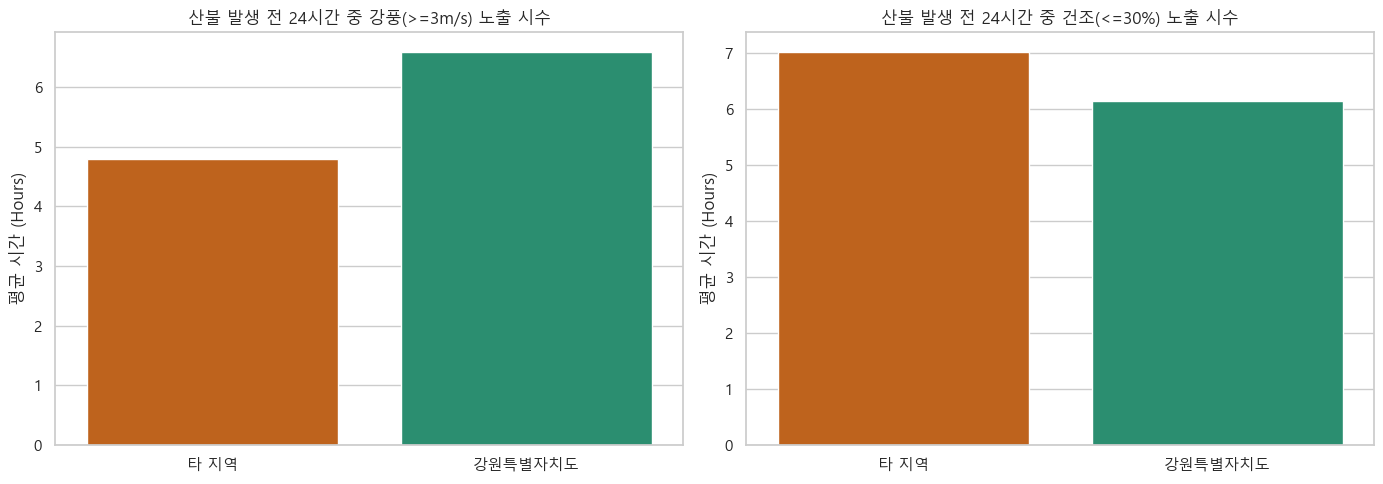

In [40]:
# 8.2. 발생 전 24시간 누적 위험 기상 노출 시간 분석
hour_pre24 = hour_df[(hour_df['발생시각기준시간'] >= -24) & (hour_df['발생시각기준시간'] <= 0)].copy()

hazard_stats = hour_pre24.groupby(['산불아이디', 'region_group', 'is_gangwon']).agg(
    strong_wind_hours=('풍속', lambda x: (x >= 3.0).sum()),
    dry_humid_hours=('습도', lambda x: (x <= 30.0).sum())
).reset_index()

print('=== 발생 전 24시간 동안 평균 위험 기상 노출 시수(Hours) ===')
print(hazard_stats.groupby('region_group')[['strong_wind_hours', 'dry_humid_hours']].mean())

# 독립표본 t-검정
gw_h_wind = hazard_stats[hazard_stats['is_gangwon']]['strong_wind_hours']
other_h_wind = hazard_stats[~hazard_stats['is_gangwon']]['strong_wind_hours']
t_h_wind, p_h_wind = stats.ttest_ind(gw_h_wind, other_h_wind, equal_var=False)

gw_h_humid = hazard_stats[hazard_stats['is_gangwon']]['dry_humid_hours']
other_h_humid = hazard_stats[~hazard_stats['is_gangwon']]['dry_humid_hours']
t_h_humid, p_h_humid = stats.ttest_ind(gw_h_humid, other_h_humid, equal_var=False)

print(f'[강풍 노출시간 T-Test] t-value = {t_h_wind:.4f}, p-value = {p_h_wind:.4e}')
print(f'[건조 노출시간 T-Test] t-value = {t_h_humid:.4f}, p-value = {p_h_humid:.4e}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=hazard_stats, x='region_group', y='strong_wind_hours', palette=['#d95f02', '#1b9e77'], ax=axes[0], errorbar=None)
axes[0].set_title('산불 발생 전 24시간 중 강풍(>=3m/s) 노출 시수')
axes[0].set_ylabel('평균 시간 (Hours)')
axes[0].set_xlabel('')

sns.barplot(data=hazard_stats, x='region_group', y='dry_humid_hours', palette=['#d95f02', '#1b9e77'], ax=axes[1], errorbar=None)
axes[1].set_title('산불 발생 전 24시간 중 건조(<=30%) 노출 시수')
axes[1].set_ylabel('평균 시간 (Hours)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 8.3. 산불 발생 이후 기상 완화 (Recovery) 속도 분석
산불 발생 시각(0시) 이후 기온, 풍속, 습도 등이 완화되거나 안정화되는 속도를 OLS 선형 회귀 기울기(Slope)로 정량화하여 대조합니다.

Calculating recovery slopes (linear regression)...

=== 평균 기상 회복 기울기 (단위/Hour) ===
              wind_slope  humid_slope
region_group                         
강원특별자치도        -0.017687     0.443004
타 지역           -0.012520     0.379133

[풍속 회복기울기 T-Test] t-value = -4.2880, p-value = 1.8296e-05

[습도 회복기울기 T-Test] t-value = 2.8696, p-value = 4.1251e-03


C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\3747838247.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=recovery_stats, x='region_group', y='wind_slope', palette=['#d95f02', '#1b9e77'], ax=axes[0], errorbar=None)
C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\3747838247.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=recovery_stats, x='region_group', y='humid_slope', palette=['#d95f02', '#1b9e77'], ax=axes[1], errorbar=None)


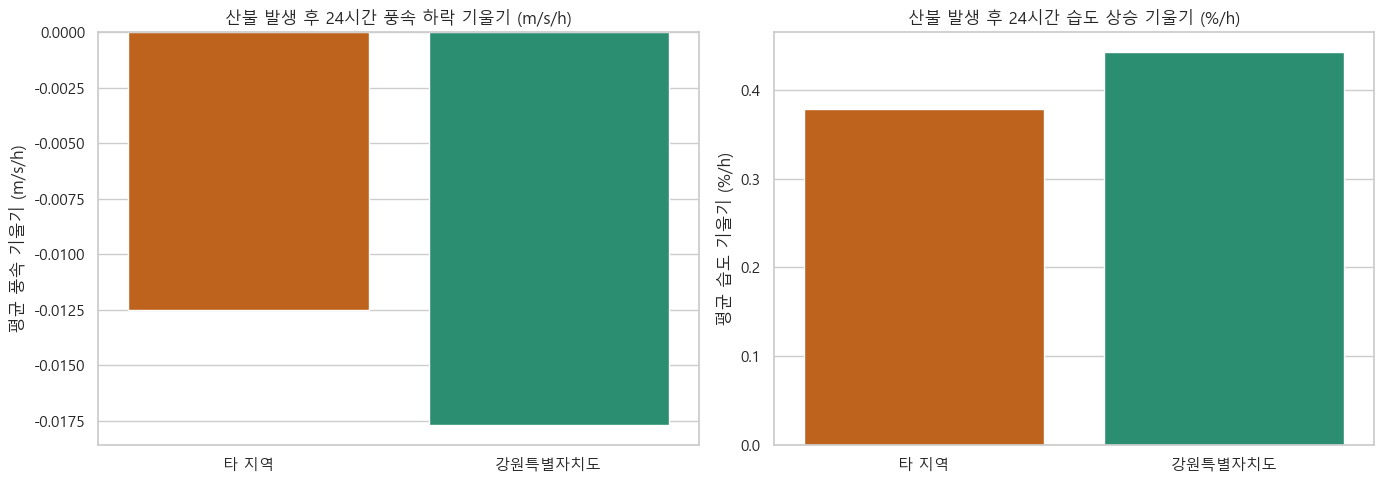

In [41]:
# 8.3. 산불 발생 이후 기상 완화 속도 분석
hour_post24 = hour_df[(hour_df['발생시각기준시간'] >= 0) & (hour_df['발생시각기준시간'] <= 24)].copy()

def calculate_recovery_slopes(group):
    if len(group) < 5:
        return pd.Series({'wind_slope': np.nan, 'humid_slope': np.nan})
    
    group_sorted = group.sort_values('발생시각기준시간')
    x = group_sorted['발생시각기준시간'].values
    
    # 풍속 slope
    y_wind = group_sorted['풍속'].values
    mask_w = ~np.isnan(y_wind)
    wind_slope = stats.linregress(x[mask_w], y_wind[mask_w])[0] if mask_w.sum() >= 5 else np.nan
        
    # 습도 slope
    y_humid = group_sorted['습도'].values
    mask_h = ~np.isnan(y_humid)
    humid_slope = stats.linregress(x[mask_h], y_humid[mask_h])[0] if mask_h.sum() >= 5 else np.nan
        
    return pd.Series({'wind_slope': wind_slope, 'humid_slope': humid_slope})

print('Calculating recovery slopes (linear regression)...')
recovery_stats = hour_post24.groupby(['산불아이디', 'region_group', 'is_gangwon']).apply(calculate_recovery_slopes, include_groups=False).reset_index()

print('\n=== 평균 기상 회복 기울기 (단위/Hour) ===')
print(recovery_stats.groupby('region_group')[['wind_slope', 'humid_slope']].mean())

# 독립표본 t-검정
gw_r_wind = recovery_stats[recovery_stats['is_gangwon']]['wind_slope'].dropna()
other_r_wind = recovery_stats[~recovery_stats['is_gangwon']]['wind_slope'].dropna()
t_r_wind, p_r_wind = stats.ttest_ind(gw_r_wind, other_r_wind, equal_var=False)

gw_r_humid = recovery_stats[recovery_stats['is_gangwon']]['humid_slope'].dropna()
other_r_humid = recovery_stats[~recovery_stats['is_gangwon']]['humid_slope'].dropna()
t_r_humid, p_r_humid = stats.ttest_ind(gw_r_humid, other_r_humid, equal_var=False)

print(f'\n[풍속 회복기울기 T-Test] t-value = {t_r_wind:.4f}, p-value = {p_r_wind:.4e}')
print(f'\n[습도 회복기울기 T-Test] t-value = {t_r_humid:.4f}, p-value = {p_r_humid:.4e}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=recovery_stats, x='region_group', y='wind_slope', palette=['#d95f02', '#1b9e77'], ax=axes[0], errorbar=None)
axes[0].set_title('산불 발생 후 24시간 풍속 하락 기울기 (m/s/h)')
axes[0].set_ylabel('평균 풍속 기울기 (m/s/h)')
axes[0].set_xlabel('')

sns.barplot(data=recovery_stats, x='region_group', y='humid_slope', palette=['#d95f02', '#1b9e77'], ax=axes[1], errorbar=None)
axes[1].set_title('산불 발생 후 24시간 습도 상승 기울기 (%/h)')
axes[1].set_ylabel('평균 습도 기울기 (%/h)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 8.4. 심화 기상 분석 결과 요약

1. **하루 전 대비 변화폭**: 발생일과 과거 1일을 비교하면 강원도 평균 풍속은 **+0.088m/s** 상승했고, 타 지역은 **-0.038m/s** 하락했습니다($t=7.77$). 최소 상대습도 변화량은 강원도 **+2.02%p**, 타 지역 **+0.74%p**로 평균상 습도 하락은 아니지만, 플롯상 강원도는 단기 저습 이상치가 더 넓게 존재합니다.

2. **발생 전 위험 노출 시간**: 발생 전 24시간 중 풍속 3m/s 이상 노출 시간은 강원도 **6.59시간**, 타 지역 **4.80시간**입니다. 반면 습도 30% 이하 노출 시간은 강원도 **6.15시간**, 타 지역 **7.02시간**으로 타 지역이 더 깁니다. 강원도 특징은 단순 저습 지속보다 **강풍 지속**에 더 가깝습니다.

3. **복합 위험 지속성**: 최장 연속 복합 위험(강풍+저습) 지속 시간은 강원도 **2.04시간**, 타 지역 **1.65시간**으로 강원도가 더 깁니다. 특히 6시간 이상 복합 위험 지속 비율은 강원도 **14.67%**, 타 지역 **9.59%**입니다.

4. **발생 후 회복 속도**: 발생 후 24시간 풍속 회복 기울기는 강원도 **-0.0177m/s/h**, 타 지역 **-0.0125m/s/h**입니다. 강원도는 더 높은 바람 피크 이후 빠르게 완화되는 사이클을 보이며, 습도 회복 기울기도 강원도 **+0.443%p/h**, 타 지역 **+0.379%p/h**로 약간 큽니다.


## 9. 대기 수분 및 에너지량 물리 지수 분석
본 섹션에서는 대기가 수분을 흡수하는 건조 압력인 **증기압 결핍량(VPD)**, 태양 노출 에너지인 **일조율/누적 일사량**, 그리고 포화도 격차인 **이슬점 격차**를 분석하여 강원도와 타 지역 간의 물리적 대기 환경 차이를 정량화합니다.

### 9.1. 증기압 결핍량 (Vapor Pressure Deficit, VPD) 분석
VPD는 대기의 수분 흡수 능력(건조 유발 압력)을 나타내며, 포화 증기압($e_s$)과 실제 증기압($e_a$)의 격차로 산출합니다.

=== 일자별 평균 VPD 기술통계량 ===
                count      mean       std       min       25%       50%  \
region_group                                                              
강원특별자치도        4139.0  4.313836  2.713858  0.008318  2.456971  3.689411   
타 지역          20897.0  5.033636  2.891877  0.003726  2.945694  4.469042   

                   75%        max  
region_group                       
강원특별자치도       5.370936  28.393127  
타 지역          6.568638  22.441160  

[일자별 VPD T-Test] t-value = -15.4178, p-value = 1.1907e-52

=== 발생시각(시간별) VPD 기술통계량 ===
                count      mean       std       min       25%       50%  \
region_group                                                              
강원특별자치도        4139.0  7.794717  6.643652  0.000112  3.053771  5.381583   
타 지역          20897.0  9.847473  7.464241  0.000390  4.153256  8.379358   

                    75%        max  
region_group                        
강원특별자치도       10.550899  53.977494  
타 지역          14.080540  53.31

C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\3414079155.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_active, x='region_group', y='VPD', palette=['#d95f02', '#1b9e77'], ax=axes[0])
C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\3414079155.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hour_active, x='region_group', y='VPD', palette=['#d95f02', '#1b9e77'], ax=axes[1])


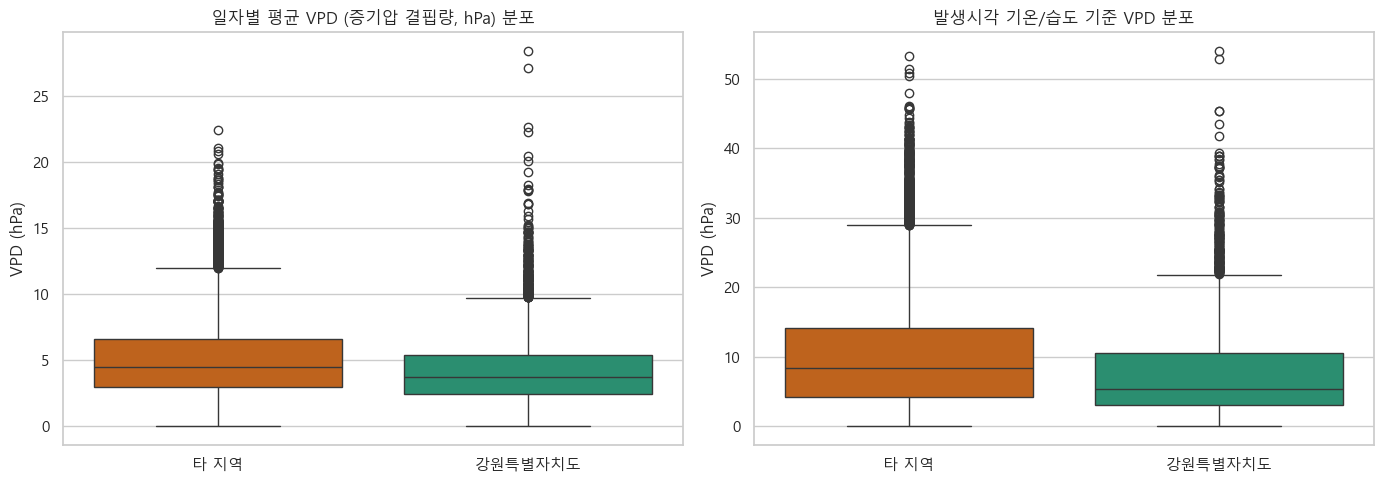

In [42]:
# 9.1. 증기압 결핍량 (Vapor Pressure Deficit, VPD) 분석
# e_s = 6.1078 * exp((17.27 * T) / (T + 237.3)) (hPa 단위)
# VPD = e_s * (1 - RH / 100)

# 일자별 평균 VPD (평균기온, 평균상대습도 기준)
temp_day = day_active['평균 기온']
rh_day = day_active['평균 상대습도']
es_day = 6.1078 * np.exp((17.27 * temp_day) / (temp_day + 237.3))
day_active['VPD'] = es_day * (1 - rh_day / 100)

# 시간별 발생 시각 VPD (기온, 습도 기준)
temp_hour = hour_active['기온']
rh_hour = hour_active['습도']
es_hour = 6.1078 * np.exp((17.27 * temp_hour) / (temp_hour + 237.3))
hour_active['VPD'] = es_hour * (1 - rh_hour / 100)

print('=== 일자별 평균 VPD 기술통계량 ===')
print(day_active.groupby('region_group')['VPD'].describe())

# T-Test
gw_vpd_d = day_active[day_active['is_gangwon']]['VPD'].dropna()
other_vpd_d = day_active[~day_active['is_gangwon']]['VPD'].dropna()
t_vpd_d, p_vpd_d = stats.ttest_ind(gw_vpd_d, other_vpd_d, equal_var=False)
print(f'\n[일자별 VPD T-Test] t-value = {t_vpd_d:.4f}, p-value = {p_vpd_d:.4e}')

print('\n=== 발생시각(시간별) VPD 기술통계량 ===')
print(hour_active.groupby('region_group')['VPD'].describe())

gw_vpd_h = hour_active[hour_active['is_gangwon']]['VPD'].dropna()
other_vpd_h = hour_active[~hour_active['is_gangwon']]['VPD'].dropna()
t_vpd_h, p_vpd_h = stats.ttest_ind(gw_vpd_h, other_vpd_h, equal_var=False)
print(f'[시간별 VPD T-Test] t-value = {t_vpd_h:.4f}, p-value = {p_vpd_h:.4e}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=day_active, x='region_group', y='VPD', palette=['#d95f02', '#1b9e77'], ax=axes[0])
axes[0].set_title('일자별 평균 VPD (증기압 결핍량, hPa) 분포')
axes[0].set_ylabel('VPD (hPa)')
axes[0].set_xlabel('')

sns.boxplot(data=hour_active, x='region_group', y='VPD', palette=['#d95f02', '#1b9e77'], ax=axes[1])
axes[1].set_title('발생시각 기온/습도 기준 VPD 분포')
axes[1].set_ylabel('VPD (hPa)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 9.2. 일조율(Sunshine Ratio) 및 누적 일사량(Solar Radiation) 분석
일조율(실제 일조시간 / 가조시간)과 누적 일사량을 통해 산불 당일 지표면에 도달하는 태양 복사 에너지량을 비교합니다.

=== 일조율 기술통계량 ===
                count      mean       std  min       25%       50%      75%  \
region_group                                                                  
강원특별자치도        4139.0  0.652759  0.262792  0.0  0.524823  0.757142  0.84990   
타 지역          20897.0  0.641387  0.283943  0.0  0.509241  0.762148  0.85811   

                   max  
region_group            
강원특별자치도       0.940368  
타 지역          0.973974  
[일조율 T-Test] t-value = 2.5090, p-value = 1.2131e-02

=== 누적 일사량 기술통계량 ===
                count       mean       std       min        25%        50%  \
region_group                                                                 
강원특별자치도        4139.0  14.226000  5.507164  0.994863  10.740195  13.785570   
타 지역          20897.0  15.942942  6.522813  0.545539  11.394626  16.026399   

                    75%        max  
region_group                        
강원특별자치도       16.547024  31.083368  
타 지역          21.259757  33.104112  
[누적 일사량 T-Test] t-value = -17.

C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\3279851275.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_active, x='region_group', y='일조율', palette=['#d95f02', '#1b9e77'], ax=axes[0], errorbar=None)
C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\3279851275.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_active, x='region_group', y='합계 일사', palette=['#d95f02', '#1b9e77'], ax=axes[1], errorbar=None)


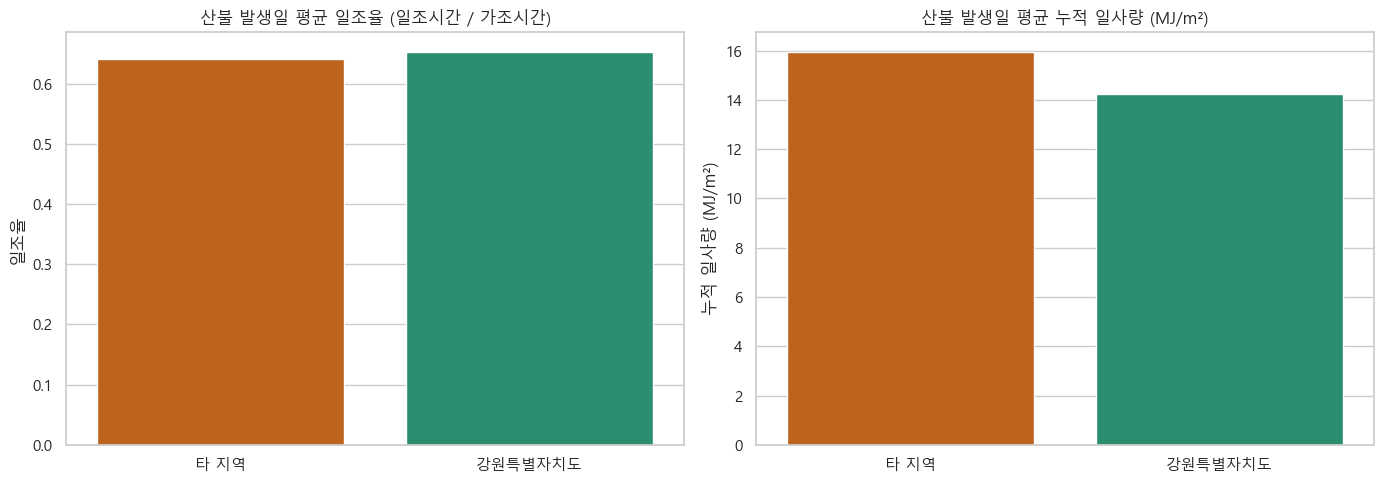

In [43]:
# 9.2. 일조율 및 누적 일사량 분석
day_active['일조율'] = day_active['합계 일조 시간'] / day_active['가조시간']

print('=== 일조율 기술통계량 ===')
print(day_active.groupby('region_group')['일조율'].describe())

# T-Test
gw_sun_ratio = day_active[day_active['is_gangwon']]['일조율'].dropna()
other_sun_ratio = day_active[~day_active['is_gangwon']]['일조율'].dropna()
t_sr, p_sr = stats.ttest_ind(gw_sun_ratio, other_sun_ratio, equal_var=False)
print(f'[일조율 T-Test] t-value = {t_sr:.4f}, p-value = {p_sr:.4e}')

print('\n=== 누적 일사량 기술통계량 ===')
print(day_active.groupby('region_group')['합계 일사'].describe())

gw_sol_rad = day_active[day_active['is_gangwon']]['합계 일사'].dropna()
other_sol_rad = day_active[~day_active['is_gangwon']]['합계 일사'].dropna()
t_sol, p_sol = stats.ttest_ind(gw_sol_rad, other_sol_rad, equal_var=False)
print(f'[누적 일사량 T-Test] t-value = {t_sol:.4f}, p-value = {p_sol:.4e}')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=day_active, x='region_group', y='일조율', palette=['#d95f02', '#1b9e77'], ax=axes[0], errorbar=None)
axes[0].set_title('산불 발생일 평균 일조율 (일조시간 / 가조시간)')
axes[0].set_ylabel('일조율')
axes[0].set_xlabel('')

sns.barplot(data=day_active, x='region_group', y='합계 일사', palette=['#d95f02', '#1b9e77'], ax=axes[1], errorbar=None)
axes[1].set_title('산불 발생일 평균 누적 일사량 (MJ/m²)')
axes[1].set_ylabel('누적 일사량 (MJ/m²)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

### 9.3. 이슬점 격차 (Dew Point Depression) 분석
이슬점 격차(기온 - 이슬점온도)가 클수록 대기가 건조하며 포화 상태(안개/결로)에서 멀어져 있음을 뜻합니다.

=== 일자별 이슬점 격차 기술통계량 ===
                count      mean       std       min       25%       50%  \
region_group                                                              
강원특별자치도        4139.0  9.035824  4.723242 -0.319813  5.199716  8.977471   
타 지역          20897.0  8.487745  4.075569 -3.111954  5.556819  8.410000   

                    75%        max  
region_group                        
강원특별자치도       12.448901  26.617509  
타 지역          11.361763  24.992590  
[일자별 이슬점격차 T-Test] t-value = 6.9691, p-value = 3.5685e-12


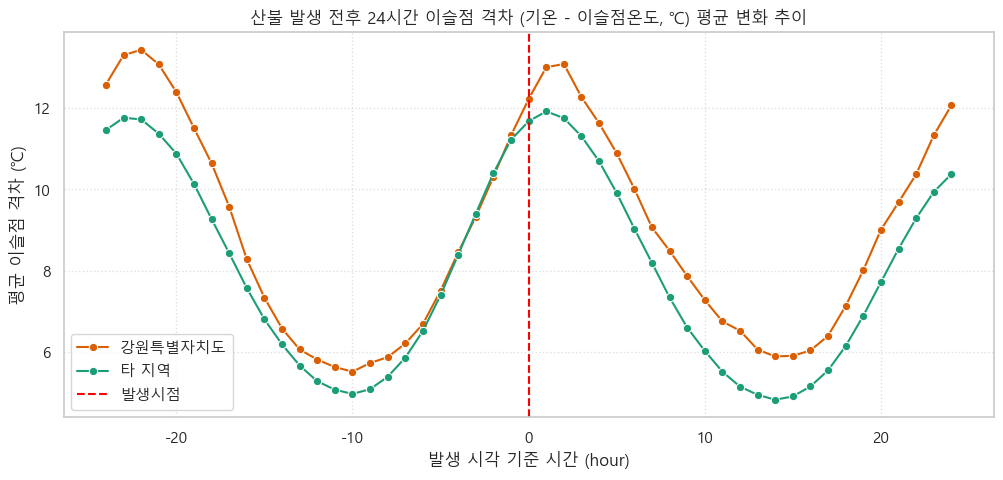

In [44]:
# 9.3. 이슬점 격차 분석
day_active['이슬점격차'] = day_active['평균 기온'] - day_active['평균 이슬점온도']

print('=== 일자별 이슬점 격차 기술통계량 ===')
print(day_active.groupby('region_group')['이슬점격차'].describe())

# T-Test
gw_dp_d = day_active[day_active['is_gangwon']]['이슬점격차'].dropna()
other_dp_d = day_active[~day_active['is_gangwon']]['이슬점격차'].dropna()
t_dp_d, p_dp_d = stats.ttest_ind(gw_dp_d, other_dp_d, equal_var=False)
print(f'[일자별 이슬점격차 T-Test] t-value = {t_dp_d:.4f}, p-value = {p_dp_d:.4e}')

# 시간별 이슬점 격차 발생 전후 24시간 시계열 추출
hour_df['이슬점격차'] = hour_df['기온'] - hour_df['이슬점온도']
trend_pre24 = hour_df[(hour_df['발생시각기준시간'] >= -24) & (hour_df['발생시각기준시간'] <= 24)].copy()
trend_dp = trend_pre24.groupby(['region_group', '발생시각기준시간'])['이슬점격차'].mean().reset_index()

# 시각화 (Line Plot)
plt.figure(figsize=(12, 5))
sns.lineplot(data=trend_dp, x='발생시각기준시간', y='이슬점격차', hue='region_group', palette=['#d95f02', '#1b9e77'], marker='o')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='발생시점')
plt.title('산불 발생 전후 24시간 이슬점 격차 (기온 - 이슬점온도, ℃) 평균 변화 추이')
plt.xlabel('발생 시각 기준 시간 (hour)')
plt.ylabel('평균 이슬점 격차 (℃)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

### 9.4. 대기 수분 및 에너지량 물리 지수 요약

1. **VPD(증기압 결핍량)**: 일자별 평균 VPD는 강원도 **4.31hPa**, 타 지역 **5.03hPa**로 강원도가 낮습니다($t=-15.42$). 발생시각 기준 VPD도 강원도 **7.79hPa**, 타 지역 **9.85hPa**입니다. 강원도는 습도가 낮아도 기온이 낮아 포화수증기압 규모가 작기 때문에, 고온 고VPD형보다 **저온 건조·강풍형** 위험으로 해석하는 것이 타당합니다.

2. **일조율과 누적 일사량**: 발생일 일조율 평균은 강원도 **65.28%**, 타 지역 **64.14%**로 강원도가 약간 높지만($p=0.012$), 누적 일사량은 강원도 **14.23MJ/m²**, 타 지역 **15.94MJ/m²**로 강원도가 낮습니다. 위도·계절·기온 조건이 반영된 결과로 보입니다.

3. **이슬점 격차**: 일자별 이슬점 격차는 강원도 **9.04℃**, 타 지역 **8.49℃**입니다($t=6.97$, $p=3.57e-12$). VPD는 낮아도 기온과 이슬점 사이의 격차는 강원도가 더 커, 저온 상태에서 공기가 불포화되어 있는 **Cold-Dry** 특성이 확인됩니다.

4. **종합 해석**: 강원도 산불은 “고온으로 인한 절대 VPD 상승”보다, 낮은 기온·낮은 이슬점·강풍이 결합해 연료 수분을 회복시키지 못하는 구조에 가깝습니다.


## 10. 미세 시간 변동성 및 기울기 분석
본 섹션에서는 발생 시점(0h) 직전의 짧은 시간 창에서 기상 변화가 얼마나 빠르게 진행되는지 확인합니다. 분석 대상은 1) 직전 6/12/24시간 기상 기울기, 2) 풍향-풍속 벡터 변화, 3) 위험 조건의 최장 연속 지속 시간입니다.

해석 시 주의할 점은, 이 데이터가 산불 발생 사건만 정렬한 표본이라는 점입니다. 따라서 아래 결과는 발생 사건 내부에서 강원특별자치도와 타 지역의 기상 패턴이 어떻게 다른지 보여주는 탐색 결과이며, 산불 발생 자체의 인과 효과를 직접 추정한 것은 아닙니다.


### 10.1. 발생 직전 시간 윈도우별 (6h, 12h, 24h) 기상 변화율 비교
발생 시점 기준 직전 6시간, 12시간, 24시간 구간에 대해 풍속, 습도, 기온의 선형 기울기를 산불 사건별로 계산합니다. 기울기의 단위는 각각 `m/s/h`, `%p/h`, `℃/h`입니다.


=== 발생 직전 윈도우별 평균 기상 기울기 ===


wind_slope                                \
                               count      mean    median       std   
window_hours region_group                                            
6            강원특별자치도            4139  0.105371  0.076346  0.241151   
             타 지역              20897  0.143048  0.125742  0.255988   
12           강원특별자치도            4139  0.057288  0.043502  0.131326   
             타 지역              20897  0.095072  0.089018  0.148862   
24           강원특별자치도            4139 -0.018676 -0.018990  0.071501   
             타 지역              20897 -0.015453 -0.019038  0.077214   

                          humidity_slope                                \
                                   count      mean    median       std   
window_hours region_group                                                
6            강원특별자치도                4139 -2.779425 -2.003326  3.734514   
             타 지역                  20897 -2.460962 -1.506414  4.014254   
12           강원특별자치도                4139 -1.628543 -1.444785  2.280142   
             타 지역                  20897 -1.697168 -1.258551  2.587588   
24           강원특별자치도                4139  0.470559  0.576021  1.391243   
             타 지역                  20897  0.318372  0.164007  1.224409   

                          temp_slope                                
                               count      mean    median       std  
window_hours region_group                                           
6            강원특별자치도            4139  0.898011  0.779832  0.974455  
             타 지역              20897  0.885580  0.875945  1.083080  
12           강원특별자치도            4139  0.479909  0.444089  0.706189  
             타 지역              20897  0.607723  0.614869  0.702942  
24           강원특별자치도            4139 -0.144532 -0.165118  0.301686  
             타 지역              20897 -0.072788 -0.088356  0.297460


=== 발생 직전 윈도우별 기울기 Welch T-Test ===


,window_hours,metric,gangwon_mean,other_mean,diff,t_value,p_value
0,6,풍속 기울기 (m/s/h),0.105371,0.143048,-0.037677,-9.088507,0.000000
1,6,습도 기울기 (%p/h),-2.779425,-2.460962,-0.318463,-4.949060,0.000001
2,6,기온 기울기 (℃/h),0.898011,0.885580,0.012431,0.735646,0.461974
3,12,풍속 기울기 (m/s/h),0.057288,0.095072,-0.037785,-16.526312,0.000000
4,12,습도 기울기 (%p/h),-1.628543,-1.697168,0.068625,1.728357,0.083972
5,12,기온 기울기 (℃/h),0.479909,0.607723,-0.127813,-10.646133,0.000000
6,24,풍속 기울기 (m/s/h),-0.018676,-0.015453,-0.003223,-2.614011,0.008970
7,24,습도 기울기 (%p/h),0.470559,0.318372,0.152187,6.552863,0.000000
8,24,기온 기울기 (℃/h),-0.144532,-0.072788,-0.071744,-14.009970,0.000000


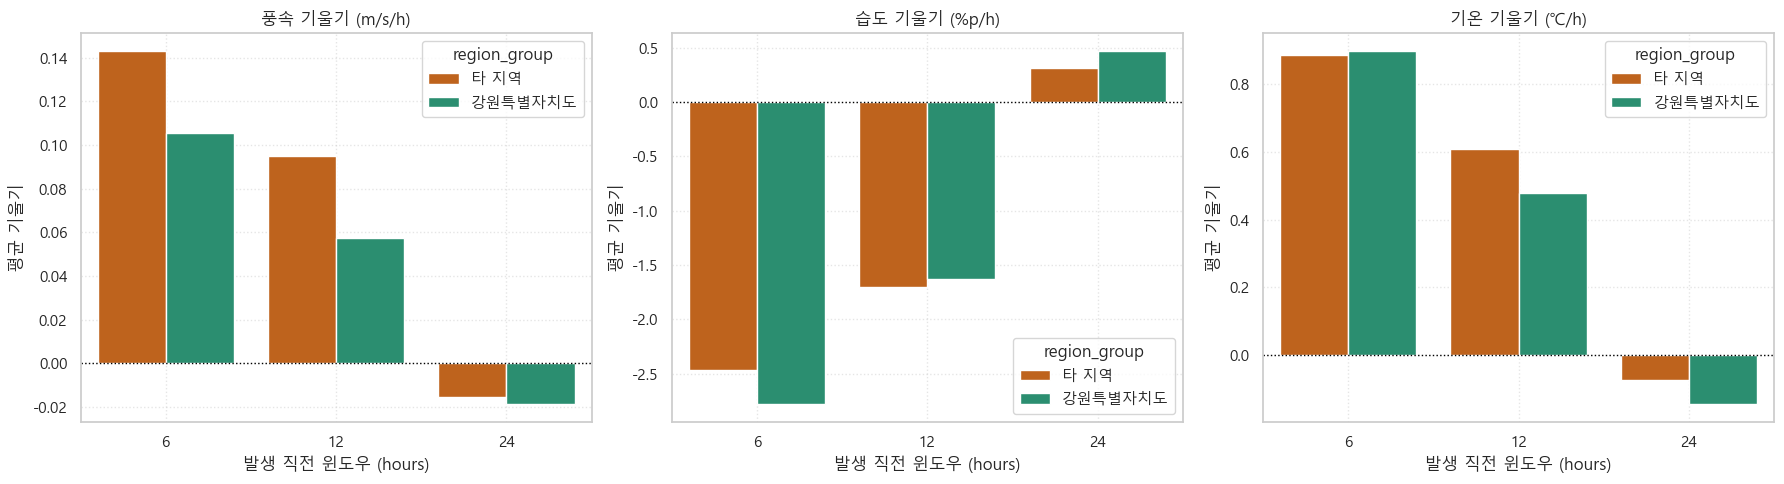

In [45]:
# 10.1. 발생 직전 시간 윈도우별 기상 변화율 비교
import numpy as np
from scipy import stats

def _linear_slope(x, y, min_points=3):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < min_points:
        return np.nan
    return stats.linregress(x[mask], y[mask]).slope

def _welch_ttest(left, right):
    left = pd.Series(left).dropna()
    right = pd.Series(right).dropna()
    if len(left) < 2 or len(right) < 2:
        return np.nan, np.nan
    t_value, p_value = stats.ttest_ind(left, right, equal_var=False)
    return t_value, p_value

window_hours = [6, 12, 24]
metric_map = {
    'wind_slope': ('풍속', '풍속 기울기 (m/s/h)'),
    'humidity_slope': ('습도', '습도 기울기 (%p/h)'),
    'temp_slope': ('기온', '기온 기울기 (℃/h)'),
}

pre_window_slope_frames = []

for window in window_hours:
    window_df = hour_df[
        (hour_df['발생시각기준시간'] >= -window) &
        (hour_df['발생시각기준시간'] <= 0)
    ].copy()
    
    def calculate_window_slopes(group):
        group_sorted = group.sort_values('발생시각기준시간')
        x = group_sorted['발생시각기준시간'].to_numpy(dtype=float)
        return pd.Series({
            'wind_slope': _linear_slope(x, group_sorted['풍속'].to_numpy(dtype=float)),
            'humidity_slope': _linear_slope(x, group_sorted['습도'].to_numpy(dtype=float)),
            'temp_slope': _linear_slope(x, group_sorted['기온'].to_numpy(dtype=float)),
        })
    
    slope_df = (
        window_df
        .groupby(['산불아이디', 'region_group', 'is_gangwon'])
        .apply(calculate_window_slopes, include_groups=False)
        .reset_index()
    )
    slope_df['window_hours'] = window
    pre_window_slope_frames.append(slope_df)

pre_window_slope_df = pd.concat(pre_window_slope_frames, ignore_index=True)

print('=== 발생 직전 윈도우별 평균 기상 기울기 ===')
window_slope_summary = (
    pre_window_slope_df
    .groupby(['window_hours', 'region_group'])[['wind_slope', 'humidity_slope', 'temp_slope']]
    .agg(['count', 'mean', 'median', 'std'])
    .round(6)
)
display(window_slope_summary)

window_ttest_records = []
for window in window_hours:
    sub = pre_window_slope_df[pre_window_slope_df['window_hours'] == window]
    for metric, (_, label) in metric_map.items():
        gw_values = sub[sub['is_gangwon']][metric]
        other_values = sub[~sub['is_gangwon']][metric]
        t_value, p_value = _welch_ttest(gw_values, other_values)
        window_ttest_records.append({
            'window_hours': window,
            'metric': label,
            'gangwon_mean': gw_values.mean(),
            'other_mean': other_values.mean(),
            'diff': gw_values.mean() - other_values.mean(),
            't_value': t_value,
            'p_value': p_value,
        })

window_slope_ttest_df = pd.DataFrame(window_ttest_records)
print('\n=== 발생 직전 윈도우별 기울기 Welch T-Test ===')
display(window_slope_ttest_df.round(6))

plot_df = pre_window_slope_df.melt(
    id_vars=['산불아이디', 'region_group', 'is_gangwon', 'window_hours'],
    value_vars=list(metric_map.keys()),
    var_name='metric',
    value_name='slope',
)
plot_df['metric_label'] = plot_df['metric'].map({k: v[1] for k, v in metric_map.items()})

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
for ax, (metric, (_, label)) in zip(axes, metric_map.items()):
    metric_plot = plot_df[plot_df['metric'] == metric]
    sns.barplot(
        data=metric_plot,
        x='window_hours',
        y='slope',
        hue='region_group',
        palette=['#d95f02', '#1b9e77'],
        errorbar=None,
        ax=ax
    )
    ax.axhline(0, color='black', linewidth=1, linestyle=':')
    ax.set_title(label)
    ax.set_xlabel('발생 직전 윈도우 (hours)')
    ax.set_ylabel('평균 기울기')
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


### 10.2. 풍향-풍속 융합 바람 벡터 변화량 (Wind Vector Delta) 분석
풍향은 0도/360도 경계가 있는 원형 변수이므로 단순 차이보다 벡터 성분으로 변환해 비교합니다. 여기서는 기상학적 풍향(`바람이 불어오는 방향`)을 이동 벡터로 바꾸기 위해 `u = -풍속 * sin(풍향)`, `v = -풍속 * cos(풍향)`을 사용합니다.


=== -24h → 0h 풍향-풍속 벡터 변화량 기술통계 ===


delta_speed                               delta_vector_mag  \
                   count      mean    median       std            count   
region_group                                                              
강원특별자치도             4139 -0.039564 -0.063263  1.483928             4139   
타 지역               20897 -0.020936 -0.059529  1.465750            20897   

                                           delta_u                      \
                  mean    median       std   count      mean    median   
region_group                                                             
강원특별자치도       2.537819  2.140683  1.831274    4139  0.092574 -0.032221   
타 지역          2.457433  1.975900  1.864958   20897 -0.060434 -0.040211   

                       delta_v                                
                   std   count      mean    median       std  
region_group                                                  
강원특별자치도       2.482777    4139  0.168019  0.190850  1.895957  
타 지역          2.129828   20897  0.139707  0.094206  2.226656


=== 벡터 변화량 Welch T-Test ===


,metric,gangwon_mean,other_mean,diff,t_value,p_value
0,풍속 변화량 (0h - -24h),-0.039564,-0.020936,-0.018627,-0.739294,0.459758
1,벡터 변화 크기,2.537819,2.457433,0.080386,2.572213,0.010129
2,동서 성분 변화량,0.092574,-0.060434,0.153009,3.704077,0.000214
3,남북 성분 변화량,0.168019,0.139707,0.028312,0.851428,0.394563



=== 지역별 평균 벡터 변화 방향 ===


,region_group,delta_u,delta_v,mean_delta_mag,mean_delta_from_direction,mean_delta_from_direction_8dir
0,강원특별자치도,0.092574,0.168019,0.191834,208.853675,SW
1,타 지역,-0.060434,0.139707,0.152218,156.607698,SE



=== 발생시각(0h) 8방위 풍향 비율 (%) ===


wind_dir_0h_8dir,E,N,NE,NW,S,SE,SW,W,W+SW
region_group,,,,,,,,,
강원특별자치도,7.22,14.06,6.72,10.85,11.43,7.15,20.56,22.01,42.57
타 지역,7.04,17.95,8.27,17.09,10.04,7.47,14.06,18.07,32.13


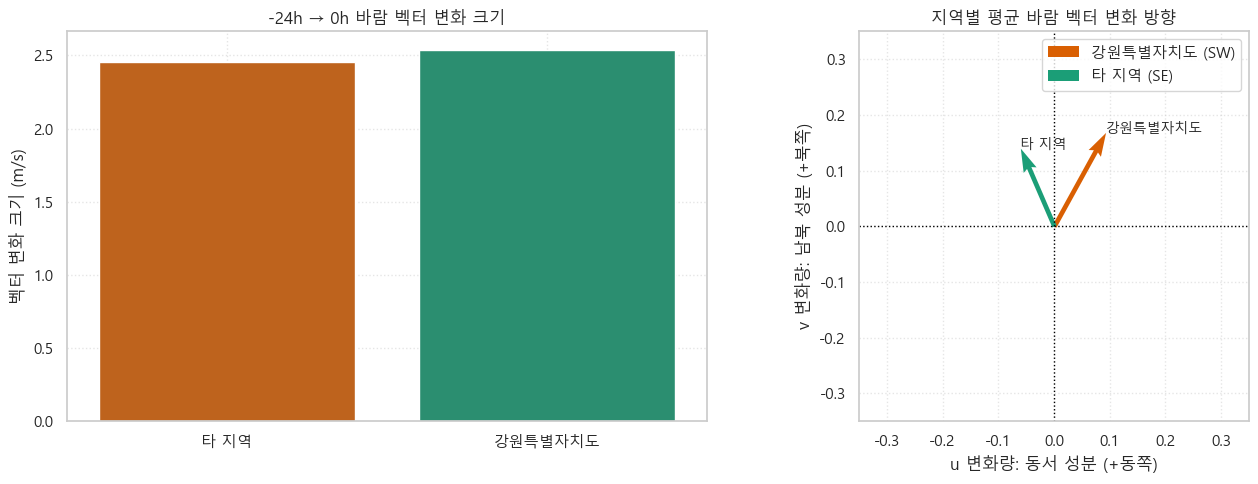

In [46]:
# 10.2. 풍향-풍속 융합 바람 벡터 변화량 분석
vector_base = hour_df[
    (hour_df['발생시각기준시간'] >= -24) &
    (hour_df['발생시각기준시간'] <= 0)
].copy()

theta = np.deg2rad(vector_base['풍향'])
vector_base['u_wind'] = -vector_base['풍속'] * np.sin(theta)
vector_base['v_wind'] = -vector_base['풍속'] * np.cos(theta)

vector_start = (
    vector_base[vector_base['발생시각기준시간'] == -24]
    [['산불아이디', 'u_wind', 'v_wind', '풍속']]
    .rename(columns={'u_wind': 'u_start', 'v_wind': 'v_start', '풍속': 'wind_start'})
)
vector_end = (
    vector_base[vector_base['발생시각기준시간'] == 0]
    [['산불아이디', 'region_group', 'is_gangwon', 'u_wind', 'v_wind', '풍속', '풍향']]
    .rename(columns={'u_wind': 'u_end', 'v_wind': 'v_end', '풍속': 'wind_end', '풍향': 'wind_dir_0h'})
)

wind_vector_delta_df = pd.merge(vector_end, vector_start, on='산불아이디', how='inner')
wind_vector_delta_df['delta_u'] = wind_vector_delta_df['u_end'] - wind_vector_delta_df['u_start']
wind_vector_delta_df['delta_v'] = wind_vector_delta_df['v_end'] - wind_vector_delta_df['v_start']
wind_vector_delta_df['delta_speed'] = wind_vector_delta_df['wind_end'] - wind_vector_delta_df['wind_start']
wind_vector_delta_df['delta_vector_mag'] = np.sqrt(
    wind_vector_delta_df['delta_u'] ** 2 + wind_vector_delta_df['delta_v'] ** 2
)

def degree_to_8dir(angle):
    if pd.isna(angle):
        return np.nan
    directions = np.array(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
    return directions[int(((angle + 22.5) % 360) // 45)]

def vector_to_from_direction(u, v):
    if pd.isna(u) or pd.isna(v):
        return np.nan
    if np.isclose(u, 0) and np.isclose(v, 0):
        return np.nan
    return (np.degrees(np.arctan2(-u, -v)) + 360) % 360

wind_vector_delta_df['wind_dir_0h_8dir'] = wind_vector_delta_df['wind_dir_0h'].apply(degree_to_8dir)
wind_vector_delta_df['delta_from_direction'] = [
    vector_to_from_direction(u, v)
    for u, v in zip(wind_vector_delta_df['delta_u'], wind_vector_delta_df['delta_v'])
]
wind_vector_delta_df['delta_from_direction_8dir'] = wind_vector_delta_df['delta_from_direction'].apply(degree_to_8dir)

print('=== -24h → 0h 풍향-풍속 벡터 변화량 기술통계 ===')
vector_summary = (
    wind_vector_delta_df
    .groupby('region_group')[['delta_speed', 'delta_vector_mag', 'delta_u', 'delta_v']]
    .agg(['count', 'mean', 'median', 'std'])
    .round(6)
)
display(vector_summary)

vector_ttest_records = []
for metric, label in {
    'delta_speed': '풍속 변화량 (0h - -24h)',
    'delta_vector_mag': '벡터 변화 크기',
    'delta_u': '동서 성분 변화량',
    'delta_v': '남북 성분 변화량',
}.items():
    gw_values = wind_vector_delta_df[wind_vector_delta_df['is_gangwon']][metric]
    other_values = wind_vector_delta_df[~wind_vector_delta_df['is_gangwon']][metric]
    t_value, p_value = _welch_ttest(gw_values, other_values)
    vector_ttest_records.append({
        'metric': label,
        'gangwon_mean': gw_values.mean(),
        'other_mean': other_values.mean(),
        'diff': gw_values.mean() - other_values.mean(),
        't_value': t_value,
        'p_value': p_value,
    })

vector_ttest_df = pd.DataFrame(vector_ttest_records)
print('\n=== 벡터 변화량 Welch T-Test ===')
display(vector_ttest_df.round(6))

mean_delta_vector = (
    wind_vector_delta_df
    .groupby('region_group')[['delta_u', 'delta_v']]
    .mean()
    .reset_index()
)
mean_delta_vector['mean_delta_mag'] = np.sqrt(mean_delta_vector['delta_u'] ** 2 + mean_delta_vector['delta_v'] ** 2)
mean_delta_vector['mean_delta_from_direction'] = [
    vector_to_from_direction(u, v)
    for u, v in zip(mean_delta_vector['delta_u'], mean_delta_vector['delta_v'])
]
mean_delta_vector['mean_delta_from_direction_8dir'] = mean_delta_vector['mean_delta_from_direction'].apply(degree_to_8dir)

print('\n=== 지역별 평균 벡터 변화 방향 ===')
display(mean_delta_vector.round(6))

dir0_ratio = (
    wind_vector_delta_df
    .groupby('region_group')['wind_dir_0h_8dir']
    .value_counts(normalize=True)
    .unstack(fill_value=0) * 100
).round(2)
dir0_ratio['W+SW'] = dir0_ratio.get('W', 0) + dir0_ratio.get('SW', 0)
print('\n=== 발생시각(0h) 8방위 풍향 비율 (%) ===')
display(dir0_ratio)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=wind_vector_delta_df,
    x='region_group',
    y='delta_vector_mag',
    hue='region_group',
    palette=['#d95f02', '#1b9e77'],
    errorbar=None,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('-24h → 0h 바람 벡터 변화 크기')
axes[0].set_xlabel('')
axes[0].set_ylabel('벡터 변화 크기 (m/s)')
axes[0].grid(True, linestyle=':', alpha=0.5)

colors = {'강원특별자치도': '#d95f02', '타 지역': '#1b9e77'}
for _, row in mean_delta_vector.iterrows():
    axes[1].quiver(
        0, 0,
        row['delta_u'], row['delta_v'],
        angles='xy',
        scale_units='xy',
        scale=1,
        color=colors[row['region_group']],
        width=0.012,
        label=f"{row['region_group']} ({row['mean_delta_from_direction_8dir']})"
    )
    axes[1].text(row['delta_u'], row['delta_v'], row['region_group'], fontsize=10)

limit = max(
    mean_delta_vector['delta_u'].abs().max(),
    mean_delta_vector['delta_v'].abs().max(),
    0.25
) * 1.4
axes[1].set_xlim(-limit, limit)
axes[1].set_ylim(-limit, limit)
axes[1].axhline(0, color='black', linewidth=1, linestyle=':')
axes[1].axvline(0, color='black', linewidth=1, linestyle=':')
axes[1].set_aspect('equal', adjustable='box')
axes[1].set_title('지역별 평균 바람 벡터 변화 방향')
axes[1].set_xlabel('u 변화량: 동서 성분 (+동쪽)')
axes[1].set_ylabel('v 변화량: 남북 성분 (+북쪽)')
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


### 10.3. 최장 연속 위험 기상 지속 시간 (Hazard Stretch) 분석
발생 전 24시간부터 발생 시점까지의 25개 시간 행을 사용해 `풍속 >= 3.0m/s`, `습도 <= 30%`, 그리고 두 조건을 동시에 만족하는 상태가 끊기지 않고 이어진 최장 시간을 산불 사건별로 계산합니다.


=== 발생 전 24시간 최장 연속 위험 기상 지속 시간 ===


strong_wind_stretch                                 \
                           count      mean median       std max   
region_group                                                      
강원특별자치도                     4139  4.466538    3.0  5.173923  25   
타 지역                       20897  3.620903    2.0  4.482177  25   

             dry_humidity_stretch                                 \
                            count      mean median       std max   
region_group                                                       
강원특별자치도                      4139  5.304905    2.0  7.599083  25   
타 지역                        20897  6.551275    2.0  9.091596  25   

             combined_stretch                                 
                        count      mean median       std max  
region_group                                                  
강원특별자치도                  4139  2.043489    0.0  3.639380  25  
타 지역                    20897  1.649950    0.0  3.004562  25


=== 최장 연속 지속 시간 Welch T-Test ===


,metric,gangwon_mean,other_mean,diff,t_value,p_value
0,최장 연속 강풍 지속 시간,4.466538,3.620903,0.845635,9.811106,0.0
1,최장 연속 저습 지속 시간,5.304905,6.551275,-1.246371,-9.313953,0.0
2,최장 연속 복합 위험 지속 시간,2.043489,1.649950,0.393539,6.529968,0.0



=== 복합 위험 조건 최장 지속 시간 임계 비율 (%) ===


,threshold_hours,region_group,combined_stretch_ratio
0,1,강원특별자치도,41.24
1,1,타 지역,40.43
2,3,강원특별자치도,27.16
3,3,타 지역,24.56
4,6,강원특별자치도,14.67
5,6,타 지역,9.59
6,12,강원특별자치도,2.39
7,12,타 지역,1.38


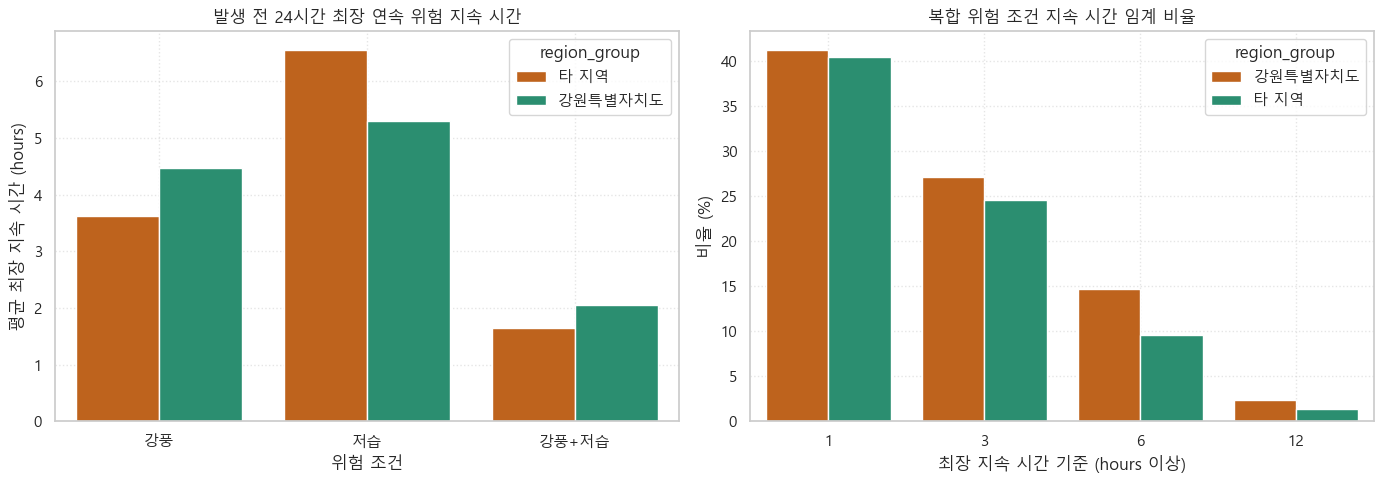

In [47]:
# 10.3. 최장 연속 위험 기상 지속 시간 분석
hour_pre24_for_stretch = hour_df[
    (hour_df['발생시각기준시간'] >= -24) &
    (hour_df['발생시각기준시간'] <= 0)
].copy()

def _longest_true_run(values):
    best = 0
    current = 0
    for value in values:
        if bool(value):
            current += 1
            best = max(best, current)
        else:
            current = 0
    return best

def calculate_hazard_stretch(group):
    group_sorted = group.sort_values('발생시각기준시간')
    strong_wind = group_sorted['풍속'] >= 3.0
    dry_humidity = group_sorted['습도'] <= 30.0
    combined = strong_wind & dry_humidity
    
    return pd.Series({
        'strong_wind_stretch': _longest_true_run(strong_wind),
        'dry_humidity_stretch': _longest_true_run(dry_humidity),
        'combined_stretch': _longest_true_run(combined),
        'has_combined_hazard': combined.any(),
    })

hazard_stretch_df = (
    hour_pre24_for_stretch
    .groupby(['산불아이디', 'region_group', 'is_gangwon'])
    .apply(calculate_hazard_stretch, include_groups=False)
    .reset_index()
)

print('=== 발생 전 24시간 최장 연속 위험 기상 지속 시간 ===')
stretch_summary = (
    hazard_stretch_df
    .groupby('region_group')[['strong_wind_stretch', 'dry_humidity_stretch', 'combined_stretch']]
    .agg(['count', 'mean', 'median', 'std', 'max'])
    .round(6)
)
display(stretch_summary)

stretch_ttest_records = []
for metric, label in {
    'strong_wind_stretch': '최장 연속 강풍 지속 시간',
    'dry_humidity_stretch': '최장 연속 저습 지속 시간',
    'combined_stretch': '최장 연속 복합 위험 지속 시간',
}.items():
    gw_values = hazard_stretch_df[hazard_stretch_df['is_gangwon']][metric]
    other_values = hazard_stretch_df[~hazard_stretch_df['is_gangwon']][metric]
    t_value, p_value = _welch_ttest(gw_values, other_values)
    stretch_ttest_records.append({
        'metric': label,
        'gangwon_mean': gw_values.mean(),
        'other_mean': other_values.mean(),
        'diff': gw_values.mean() - other_values.mean(),
        't_value': t_value,
        'p_value': p_value,
    })

stretch_ttest_df = pd.DataFrame(stretch_ttest_records)
print('\n=== 최장 연속 지속 시간 Welch T-Test ===')
display(stretch_ttest_df.round(6))

threshold_records = []
for threshold in [1, 3, 6, 12]:
    for region in ['강원특별자치도', '타 지역']:
        sub = hazard_stretch_df[hazard_stretch_df['region_group'] == region]
        threshold_records.append({
            'threshold_hours': threshold,
            'region_group': region,
            'combined_stretch_ratio': (sub['combined_stretch'] >= threshold).mean() * 100,
        })

combined_threshold_df = pd.DataFrame(threshold_records)
print('\n=== 복합 위험 조건 최장 지속 시간 임계 비율 (%) ===')
display(combined_threshold_df.round(2))

stretch_plot_df = hazard_stretch_df.melt(
    id_vars=['산불아이디', 'region_group', 'is_gangwon'],
    value_vars=['strong_wind_stretch', 'dry_humidity_stretch', 'combined_stretch'],
    var_name='stretch_type',
    value_name='hours',
)
stretch_label_map = {
    'strong_wind_stretch': '강풍',
    'dry_humidity_stretch': '저습',
    'combined_stretch': '강풍+저습',
}
stretch_plot_df['stretch_label'] = stretch_plot_df['stretch_type'].map(stretch_label_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=stretch_plot_df,
    x='stretch_label',
    y='hours',
    hue='region_group',
    palette=['#d95f02', '#1b9e77'],
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title('발생 전 24시간 최장 연속 위험 지속 시간')
axes[0].set_xlabel('위험 조건')
axes[0].set_ylabel('평균 최장 지속 시간 (hours)')
axes[0].grid(True, linestyle=':', alpha=0.5)

sns.barplot(
    data=combined_threshold_df,
    x='threshold_hours',
    y='combined_stretch_ratio',
    hue='region_group',
    palette=['#d95f02', '#1b9e77'],
    ax=axes[1]
)
axes[1].set_title('복합 위험 조건 지속 시간 임계 비율')
axes[1].set_xlabel('최장 지속 시간 기준 (hours 이상)')
axes[1].set_ylabel('비율 (%)')
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()


### 10.4. 미세 시간 변동성 및 기울기 분석 요약

1. **직전 6시간 기울기**: 발생 직전 6시간 동안 습도 하강률은 강원도 **-2.779%p/h**, 타 지역 **-2.461%p/h**로 강원도가 더 가파릅니다. 반면 풍속 기울기는 강원도 **0.105m/s/h**, 타 지역 **0.143m/s/h**로 타 지역이 더 커, 모든 기상 변화가 강원도에서 더 급변한다고 볼 수는 없습니다.

2. **12시간/24시간 창**: 12시간 창에서는 타 지역의 풍속·기온 기울기가 더 크고, 24시간 창에서는 강원도 습도 기울기가 더 높게 나타납니다. 강원도 특징은 일관된 전 변수 급변이 아니라 **직전 6시간의 습도 급하강**과 **장시간 강풍 노출**로 요약됩니다.

3. **풍향-풍속 벡터 변화**: -24h에서 0h까지의 벡터 변화 크기는 강원도 **2.54**, 타 지역 **2.46**으로 강원도가 약간 크고, 평균 변화 방향은 강원도 **SW**, 타 지역 **SE**입니다. 강원도는 발생시각 풍향에서도 W+SW가 **42.57%**로 높아 서풍계열 전환 신호가 유지됩니다.

4. **최장 연속 위험 지속 시간**: 최장 연속 강풍 지속 시간은 강원도 **4.47시간**, 타 지역 **3.62시간**입니다. 최장 연속 복합 위험 지속 시간도 강원도 **2.04시간**, 타 지역 **1.65시간**으로 강원도가 더 깁니다. 다만 최장 연속 저습 지속 시간은 타 지역이 더 길어, 강원도 위험은 저습 단독보다 강풍과 결합된 지속성에 집중됩니다.


## 11. 지면 및 지중 열적 조건 분석 (Surface & Soil Conditions)
본 섹션에서는 산불의 최초 발화와 초기 확산이 일어나는 물리적 환경인 지표면 및 지중의 열적 상태를 분석합니다. 지표 가열 정도를 대변하는 `지면온도편차 (지면온도 - 기온)`와 `최저 초상온도` 분포를 분석하고, 토양 건조 상태를 지시하는 대리 지표로 `지중 온도 수직 구배 (5cm 지중온도 - 30cm 지중온도)`를 대조합니다.

### 11.1. 접지 기온(최저 초상온도) 및 지면온도 편차 분석
지표 가열 정도는 지표면 낙엽 등 미세 연료의 온도 상승을 유발하여 화재 발생 및 초기 확산 속도를 가속시킵니다. 일자별 및 시간별 데이터에서 기온과 지면온도의 격차를 비교하고, 대기 최하층의 기온인 초상온도의 최저치를 강원도와 타 지역 간에 대조 분석합니다.

=== 일자별 지면온도편차 (평균 지면온도 - 평균 기온) ===
                count      mean       std       min       25%       50%  \
region_group                                                              
강원특별자치도        4139.0  2.241091  2.754361 -5.287896  0.632179  2.261846   
타 지역          20897.0  2.300144  2.467332 -7.747687  0.587149  2.206059   

                   75%        max  
region_group                       
강원특별자치도       4.237603  11.210188  
타 지역          4.018977  12.932161  

지면온도편차 강원 vs 타 지역 t-test: t=-1.2813, p=2.0016e-01

=== 일자별 최저 초상온도 ===
                count      mean       std        min       25%       50%  \
region_group                                                               
강원특별자치도        4139.0 -2.540407  6.685864 -23.964703 -8.106475 -2.282461   
타 지역          20897.0 -0.268310  7.331369 -24.144515 -5.333985 -1.236188   

                   75%        max  
region_group                       
강원특별자치도       1.441467  22.420075  
타 지역          3.548429  25.698229

C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\4125276123.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_active, x='region_group', y='지면온도편차', palette=['#d95f02', '#1b9e77'], ax=axes[0])
C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\4125276123.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_active, x='region_group', y='최저 초상온도', palette=['#d95f02', '#1b9e77'], ax=axes[1])


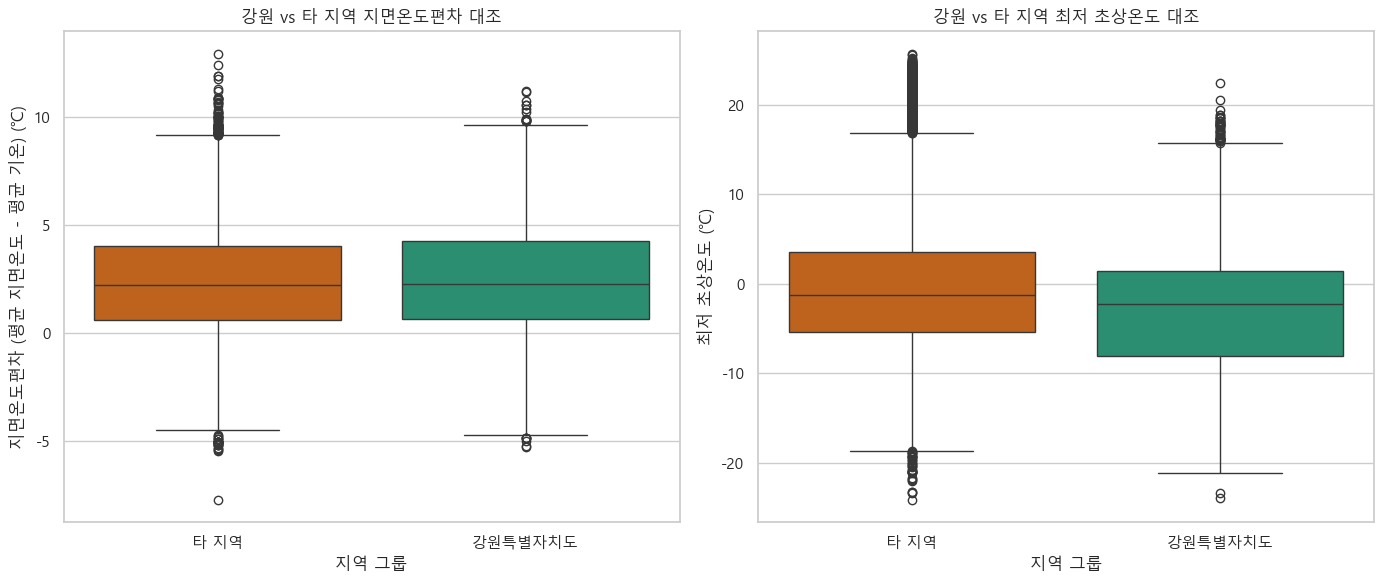

In [48]:
# 11.1. 접지 기온(최저 초상온도) 및 지면온도 편차 분석
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 지면온도 편차 변수 산출
day_active['지면온도편차'] = day_active['평균 지면온도'] - day_active['평균 기온']
hour_active['지면온도편차'] = hour_active['지면온도'] - hour_active['기온']

print("=== 일자별 지면온도편차 (평균 지면온도 - 평균 기온) ===")
print(day_active.groupby('region_group')['지면온도편차'].describe())

gw_diff = day_active[day_active['is_gangwon']]['지면온도편차'].dropna()
other_diff = day_active[~day_active['is_gangwon']]['지면온도편차'].dropna()
t_val, p_val = stats.ttest_ind(gw_diff, other_diff, equal_var=False)
print(f"\n지면온도편차 강원 vs 타 지역 t-test: t={t_val:.4f}, p={p_val:.4e}\n")

print("=== 일자별 최저 초상온도 ===")
print(day_active.groupby('region_group')['최저 초상온도'].describe())

gw_ch = day_active[day_active['is_gangwon']]['최저 초상온도'].dropna()
other_ch = day_active[~day_active['is_gangwon']]['최저 초상온도'].dropna()
t_val2, p_val2 = stats.ttest_ind(gw_ch, other_ch, equal_var=False)
print(f"\n최저 초상온도 강원 vs 타 지역 t-test: t={t_val2:.4f}, p={p_val2:.4e}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=day_active, x='region_group', y='지면온도편차', palette=['#d95f02', '#1b9e77'], ax=axes[0])
axes[0].set_title("강원 vs 타 지역 지면온도편차 대조")
axes[0].set_xlabel("지역 그룹")
axes[0].set_ylabel("지면온도편차 (평균 지면온도 - 평균 기온) (℃)")

sns.boxplot(data=day_active, x='region_group', y='최저 초상온도', palette=['#d95f02', '#1b9e77'], ax=axes[1])
axes[1].set_title("강원 vs 타 지역 최저 초상온도 대조")
axes[1].set_xlabel("지역 그룹")
axes[1].set_ylabel("최저 초상온도 (℃)")

plt.tight_layout()
plt.show()

### 11.2. 지중 온도 수직 구배 (Soil Temperature Gradient) 분석
표층(5cm)과 심층(30cm)의 지중 온도의 수직 온도 구배는 토양의 건조화 정도와 표층 열전도 효율을 지시하는 대리 지표로 사용할 수 있습니다. 토양이 극도로 건조한 시기에는 수직 열전도 형태가 왜곡되며 수직 온도 구배가 벌어지는 현상이 나타납니다. 이를 지역별 및 산불 규모별(진화소요시간 기준 대형 산불 여부)로 비교 분석합니다.

=== 시간별 지중온도구배 (5cm 지중온도 - 30cm 지중온도) ===
                count      mean       std        min       25%       50%  \
region_group                                                               
강원특별자치도        3742.0  1.181210  3.360105  -7.557546 -1.154577  0.346143   
타 지역          17763.0  2.098575  3.884563 -10.645218 -0.805724  1.649916   

                   75%        max  
region_group                       
강원특별자치도       2.881198  14.488238  
타 지역          4.630533  19.188459  

지중온도구배 강원 vs 타 지역 t-test: t=-14.7527, p=2.0390e-48

=== 대형 산불(>=12h) vs 일반 산불(<12h) 지중온도구배 ===
           count      mean       std       min       25%       50%       75%  \
is_large                                                                       
False     6219.0  0.468632  1.917483 -6.673698 -0.738672  0.698610  1.846224   
True       225.0  0.612757  1.981382 -4.619947 -0.701985  0.770028  2.154260   

               max  
is_large            
False     7.695171  
True      5.459106  

대형 vs 일

C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\3690730731.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hour_active, x='region_group', y='지중온도구배_5_30', palette=['#d95f02', '#1b9e77'], ax=axes[0])
C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\3690730731.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_duration_day, x='is_large', y='지중온도구배_5_30', palette=['#377eb8', '#e41a1c'], ax=axes[1])
C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\3690730731.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["일반 산불 (<12h)", "대형 산불 (>=12h)"])


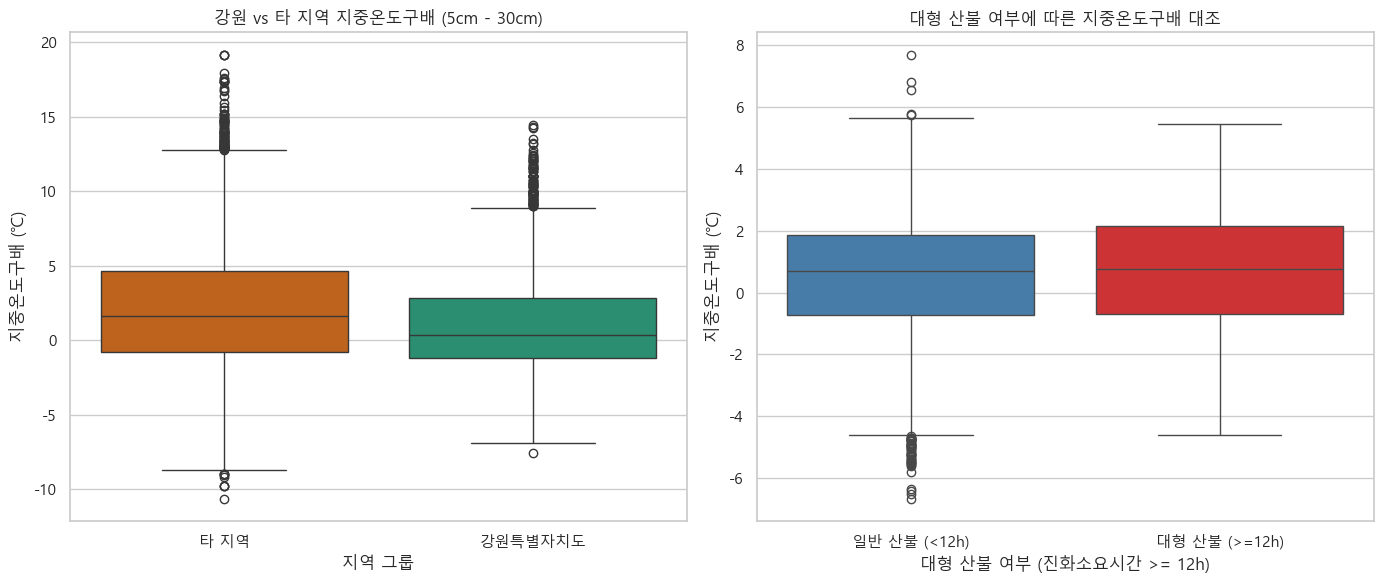

In [49]:
# 11.2. 지중 온도 수직 구배 분석
day_active['지중온도구배_5_30'] = day_active['평균 5cm 지중온도'] - day_active['평균 30cm 지중온도']
hour_active['지중온도구배_5_30'] = hour_active['5cm 지중온도'] - hour_active['30cm 지중온도']

print("=== 시간별 지중온도구배 (5cm 지중온도 - 30cm 지중온도) ===")
print(hour_active.groupby('region_group')['지중온도구배_5_30'].describe())

gw_grad = hour_active[hour_active['is_gangwon']]['지중온도구배_5_30'].dropna()
other_grad = hour_active[~hour_active['is_gangwon']]['지중온도구배_5_30'].dropna()
t_val3, p_val3 = stats.ttest_ind(gw_grad, other_grad, equal_var=False)
print(f"\n지중온도구배 강원 vs 타 지역 t-test: t={t_val3:.4f}, p={p_val3:.4e}\n")

# 대형 산불 여부에 따른 지중온도구배 대조 (진화소요시간시 >= 12h)
valid_duration_day = day_active.dropna(subset=['진화소요시간시']).copy()
valid_duration_day['is_large'] = valid_duration_day['진화소요시간시'] >= 12

print("=== 대형 산불(>=12h) vs 일반 산불(<12h) 지중온도구배 ===")
print(valid_duration_day.groupby('is_large')['지중온도구배_5_30'].describe())

large_grad = valid_duration_day[valid_duration_day['is_large']]['지중온도구배_5_30'].dropna()
normal_grad = valid_duration_day[~valid_duration_day['is_large']]['지중온도구배_5_30'].dropna()
t_val4, p_val4 = stats.ttest_ind(large_grad, normal_grad, equal_var=False)
print(f"\n대형 vs 일반 지중온도구배 t-test: t={t_val4:.4f}, p={p_val4:.4e}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=hour_active, x='region_group', y='지중온도구배_5_30', palette=['#d95f02', '#1b9e77'], ax=axes[0])
axes[0].set_title("강원 vs 타 지역 지중온도구배 (5cm - 30cm)")
axes[0].set_xlabel("지역 그룹")
axes[0].set_ylabel("지중온도구배 (℃)")

sns.boxplot(data=valid_duration_day, x='is_large', y='지중온도구배_5_30', palette=['#377eb8', '#e41a1c'], ax=axes[1])
axes[1].set_title("대형 산불 여부에 따른 지중온도구배 대조")
axes[1].set_xlabel("대형 산불 여부 (진화소요시간 >= 12h)")
axes[1].set_xticklabels(["일반 산불 (<12h)", "대형 산불 (>=12h)"])
axes[1].set_ylabel("지중온도구배 (℃)")

plt.tight_layout()
plt.show()

### 11.3. 지면 및 지중 열적 조건 분석 요약

1. **지면온도편차**: 일자별 지면온도편차(평균 지면온도 - 평균 기온)는 강원도 **2.24℃**, 타 지역 **2.30℃**로 거의 같고, 차이는 통계적으로 유의하지 않습니다($p=0.200$). 따라서 전국 비교에서 지면 가열 편차 자체가 강원도만의 핵심 차별 요인이라고 보기는 어렵습니다.

2. **최저 초상온도**: 최저 초상온도는 강원도 **-2.54℃**, 타 지역 **-0.27℃**로 강원도가 뚜렷하게 낮습니다($t=-19.65$, $p=1.85e-83$). 이는 지면 근접층의 야간 냉각과 저온 건조 조건이 강원도 산불 표본에 강하게 반영되었음을 뜻합니다.

3. **지중 온도 구배**: 시간별 5cm-30cm 지중온도구배는 강원도 **1.18℃**, 타 지역 **2.10℃**로 타 지역이 더 큽니다($p=2.04e-48$). 대형 산불과 일반 산불 간 지중온도구배 차이는 평균 **0.61℃ vs 0.47℃**이나 유의하지 않습니다($p=0.284$).

4. **해석**: 강원도 전국 비교에서 강한 신호는 지표 가열보다 **낮은 초상온도와 저온 건조 기상장**입니다. 지중온도구배는 유효 표본과 결측 구조를 고려해 보조 변수로 다루는 것이 안전합니다.


## 12. 대기압 변동 및 종관 기상 패턴 분석 (Synoptic Pressure Patterns)
본 섹션에서는 한랭전선이나 이동성 저기압이 통과할 때 동반되는 기압 급변 쇼크와 관측소 해발 고도로 인한 기압 격차 효과가 강원도 산불의 강풍 환경 형성에 미치는 종관 기상적 영향을 실증합니다.

### 12.1. 현지기압 급하강 (Pressure Drop Shock) 분석
산불 발생 전 24시간 동안의 현지기압 최대-최소 변동폭을 계산하여 기압계의 급변 속도를 대조합니다. 기압 변동량이 크고 가파를수록 강한 기압경도력에 의한 국지성 강풍 유발 쇼크가 크게 작용했음을 방증합니다.

=== 발생 전 24시간 동안 현지기압 변동폭 (max - min) ===
                count       mean        std       min       25%       50%  \
region_group                                                                
강원특별자치도        4139.0  10.156768  14.592896  1.318400  4.505177  6.141694   
타 지역          20897.0   7.058328   8.747827  0.726445  3.841267  5.322329   

                    75%         max  
region_group                         
강원특별자치도       10.332575  426.238161  
타 지역           7.524685  312.336464  

기압변동폭 강원 vs 타 지역 t-test: t=13.1983, p=4.3516e-39


C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\1840221789.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=press_stats, x='region_group', y='기압변동폭', palette=['#d95f02', '#1b9e77'])


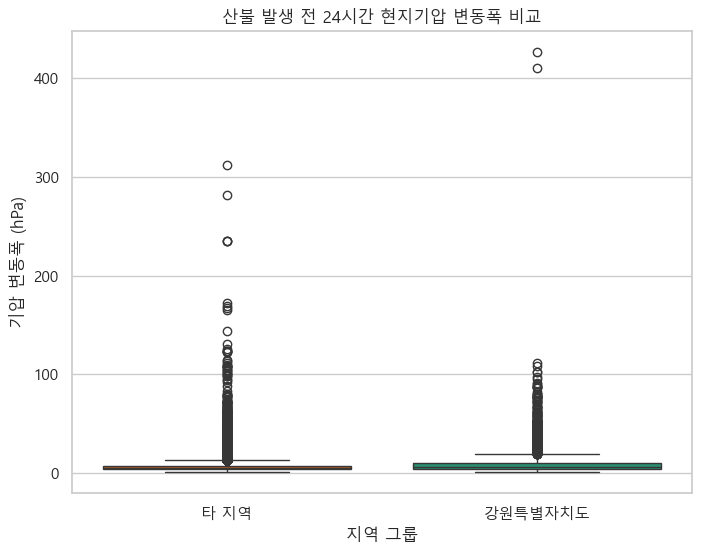

In [50]:
# 12.1. 현지기압 급하강 (Pressure Drop Shock) 분석
# 발생 전 24시간 동안 현지기압의 최대 - 최소 변동폭 산출
press_pre24 = hour_df[(hour_df['발생시각기준시간'] >= -24) & (hour_df['발생시각기준시간'] <= 0)].copy()
press_stats = press_pre24.groupby('산불아이디').agg(
    press_max=('현지기압', 'max'),
    press_min=('현지기압', 'min'),
    is_gangwon=('is_gangwon', 'first'),
    region_group=('region_group', 'first')
).reset_index()
press_stats['기압변동폭'] = press_stats['press_max'] - press_stats['press_min']

print("=== 발생 전 24시간 동안 현지기압 변동폭 (max - min) ===")
print(press_stats.groupby('region_group')['기압변동폭'].describe())

gw_p_range = press_stats[press_stats['is_gangwon']]['기압변동폭'].dropna()
other_p_range = press_stats[~press_stats['is_gangwon']]['기압변동폭'].dropna()
t_val5, p_val5 = stats.ttest_ind(gw_p_range, other_p_range, equal_var=False)
print(f"\n기압변동폭 강원 vs 타 지역 t-test: t={t_val5:.4f}, p={p_val5:.4e}")

# 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(data=press_stats, x='region_group', y='기압변동폭', palette=['#d95f02', '#1b9e77'])
plt.title("산불 발생 전 24시간 현지기압 변동폭 비교")
plt.xlabel("지역 그룹")
plt.ylabel("기압 변동폭 (hPa)")
plt.show()

### 12.2. 기압 격차 기반 관측소 고도 가중 효과 분석
해면기압(해수면 기준 보정 기압)과 현지기압(실제 지상 관측 기압)의 격차인 `해면기압 - 현지기압`은 정역학 방정식에 의해 해당 관측 지점의 해발 고도와 정비례합니다. 이 기압격차를 통해 산불 인근의 고도 분포 특성을 역산하고, 해발 고도에 따른 풍속의 가속 작용이 강원 산불 발생 시 어떻게 맞물려 작용했는지 대조 분석합니다.

=== 일자별 기압격차 (평균 해면기압 - 평균 현지기압) ===
                count       mean        std       min        25%        50%  \
region_group                                                                  
강원특별자치도        4139.0  22.812395  15.777267  2.206118  13.490819  18.353252   
타 지역          20897.0  11.029912   7.752080  0.168416   5.349000   8.623181   

                    75%        max  
region_group                        
강원특별자치도       28.819570  93.546707  
타 지역          14.852769  65.808505  

기압격차 강원 vs 타 지역 t-test: t=46.9364, p=0.0000e+00


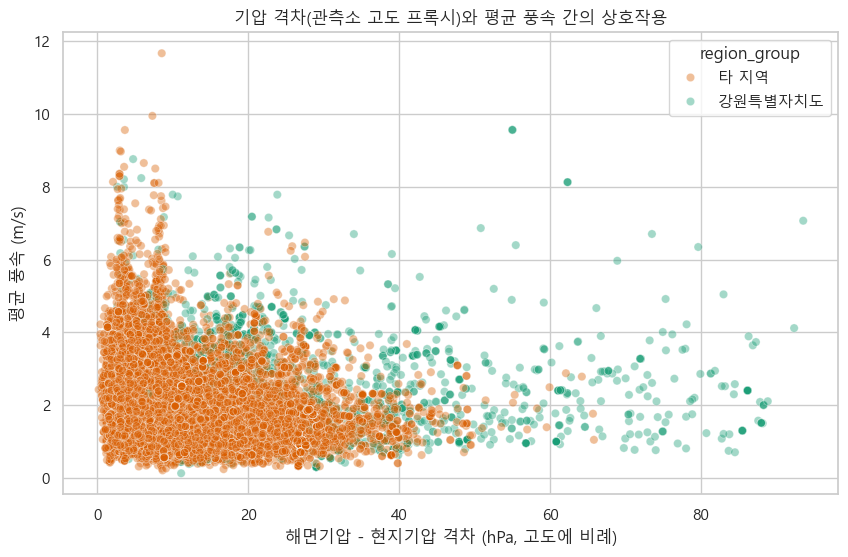

In [51]:
# 12.2. 기압 격차 기반 관측소 고도 가중 효과 분석
day_active['기압격차'] = day_active['평균 해면기압'] - day_active['평균 현지기압']

print("=== 일자별 기압격차 (평균 해면기압 - 평균 현지기압) ===")
print(day_active.groupby('region_group')['기압격차'].describe())

gw_p_gap = day_active[day_active['is_gangwon']]['기압격차'].dropna()
other_p_gap = day_active[~day_active['is_gangwon']]['기압격차'].dropna()
t_val6, p_val6 = stats.ttest_ind(gw_p_gap, other_p_gap, equal_var=False)
print(f"\n기압격차 강원 vs 타 지역 t-test: t={t_val6:.4f}, p={p_val6:.4e}")

# 시각화: 기압 격차(고도 프록시)와 풍속의 상관관계
plt.figure(figsize=(10, 6))
sns.scatterplot(data=day_active, x='기압격차', y='평균 풍속', hue='region_group', alpha=0.4, palette=['#d95f02', '#1b9e77'])
plt.title("기압 격차(관측소 고도 프록시)와 평균 풍속 간의 상호작용")
plt.xlabel("해면기압 - 현지기압 격차 (hPa, 고도에 비례)")
plt.ylabel("평균 풍속 (m/s)")
plt.show()

### 12.3. 대기압 변동 및 종관 기상 패턴 분석 요약

1. **현지기압 변동폭**: 발생 전 24시간 현지기압 변동폭은 강원도 **10.16hPa**, 타 지역 **7.06hPa**로 강원도가 큽니다($t=13.20$, $p=4.35e-39$). 이는 산불 발생 전 종관장 변화나 전선 통과에 따른 기압경도력 증가가 강원도 표본에서 더 강했을 가능성을 보여줍니다.

2. **이상치 주의**: 기압 변동폭에는 강원도 최대 **426hPa**, 타 지역 최대 **312hPa** 수준의 극단값이 보입니다. EDA 규칙상 값을 임의 제거하지 않았으며, 모델링 전에는 관측소 매칭 오류, 고도 보정 문제, 태풍·특이 기상 사례 여부를 별도로 점검해야 합니다.

3. **기압 격차와 고도 프록시**: 해면기압-현지기압 격차는 강원도 **22.81hPa**, 타 지역 **11.03hPa**로 강원도가 훨씬 큽니다. 이는 강원도 산불 지점이 상대적으로 고도 영향이 큰 관측 환경에 놓여 있음을 뜻합니다.

4. **종합 해석**: 강원도 기상 위험은 단순 저기압보다, 고도 효과와 종관 기압 변동이 결합해 바람을 증폭시키는 구조로 보는 것이 타당합니다.


## 13. 계절적 잔존물 및 지리 격차 분석 (Seasonal & Spatial Disparities)
본 섹션에서는 겨울철의 잔존물인 '적설'이 지표 수분막을 형성해 산불 발생 시 진화를 억제(용이하게 함)하는 완화 효과가 실재하는지 검증하고, 태백산맥을 경계로 나뉘는 강원 영동(해안)지방과 영서(내륙)지방 간의 기상 격차를 내부적으로 세밀하게 비교 분석합니다.

### 13.1. 발생 당일/전일 잔존 적설 완화 효과 분석 (대안 분석)
산불 발생 당일 또는 과거 1일 내에 실제 눈이 쌓여 있던 상태(`일 최심적설 > 0`)를 분류하여, 잔존 적설이 존재할 경우 산불의 확산이 지연되고 진화가 용이하여 평균 진화소요시간이 유의미하게 감소하는지 검증합니다.

=== 강원도 vs 타 지역 적설 존재 산불 비율 ===
region_group
강원특별자치도    0.326166
타 지역       0.271235
Name: 적설존재, dtype: float64

=== 적설 존재 여부에 따른 진화소요시간 비교 (전체 지역) ===
        count      mean       std  min       25%       50%       75%  \
적설존재                                                                   
False  4098.0  2.257203  3.950808  0.0  0.716667  1.250000  2.166667   
True   2346.0  1.835472  2.914270  0.0  0.616667  1.041667  1.750000   

             max  
적설존재              
False  76.000000  
True   50.833333  

적설 유무에 따른 진화소요시간 t-test: t=-4.8929, p=1.0193e-06


C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\1427840396.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_duration_day, x='적설존재', y='진화소요시간시', palette=['#377eb8', '#4daf4a'])


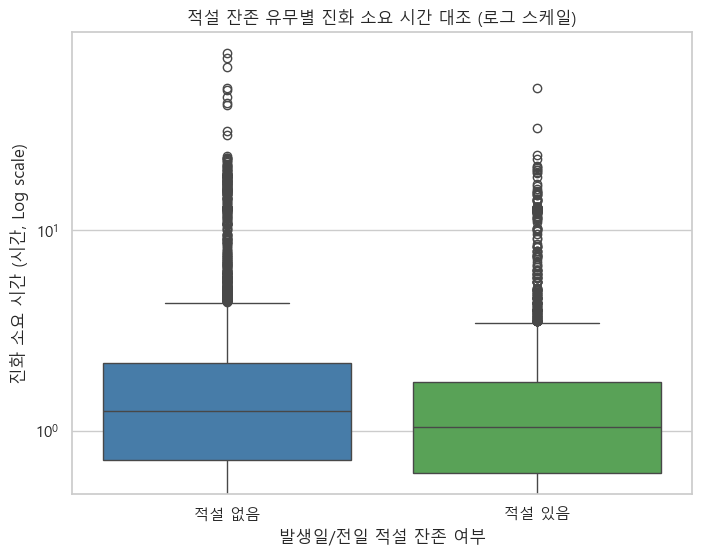

In [52]:
# 13.1. 발생 당일/전일 잔존 적설 완화 효과 분석
day_active['일 최심적설_fill'] = day_active['일 최심적설'].fillna(0)
day_active['적설존재'] = day_active['일 최심적설_fill'] > 0

print("=== 강원도 vs 타 지역 적설 존재 산불 비율 ===")
print(day_active.groupby('region_group')['적설존재'].mean())

# 진화소요시간이 기록된 데이터셋에서 적설 유무별 진화소요시간 대조
valid_duration_day = day_active.dropna(subset=['진화소요시간시']).copy()
print("\n=== 적설 존재 여부에 따른 진화소요시간 비교 (전체 지역) ===")
print(valid_duration_day.groupby('적설존재')['진화소요시간시'].describe())

snow_true = valid_duration_day[valid_duration_day['적설존재']]['진화소요시간시'].dropna()
snow_false = valid_duration_day[~valid_duration_day['적설존재']]['진화소요시간시'].dropna()
t_val7, p_val7 = stats.ttest_ind(snow_true, snow_false, equal_var=False)
print(f"\n적설 유무에 따른 진화소요시간 t-test: t={t_val7:.4f}, p={p_val7:.4e}")

# 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(data=valid_duration_day, x='적설존재', y='진화소요시간시', palette=['#377eb8', '#4daf4a'])
plt.yscale('log')
plt.title("적설 잔존 유무별 진화 소요 시간 대조 (로그 스케일)")
plt.xlabel("발생일/전일 적설 잔존 여부")
plt.ylabel("진화 소요 시간 (시간, Log scale)")
plt.xticks([0, 1], ["적설 없음", "적설 있음"])
plt.show()

### 13.2. 강원 영동 vs 영서 내부 기상 대조 분석
강원도 내에서도 태백산맥 동쪽인 영동 해안권(강릉, 속초, 동해, 삼척, 태백, 고성, 양양)과 서쪽인 영서 내륙권(춘천, 원주 등 11개 시군)은 국지풍과 지형적 요인(양간지풍 바람길)으로 인해 완전히 다른 기상 특성을 나타냅니다. 두 세부 지역 간의 풍속과 습도 환경을 분리하여 비교 분석합니다.

C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\102850363.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gw_only, x='sub_region', y='평균 풍속', palette=['#e41a1c', '#377eb8'], ax=axes[0])


=== 강원 영동 해안 vs 영서 내륙 주요 기상 변수 비교 ===
             평균 풍속                                                    \
             count      mean       std       min       25%       50%   
sub_region                                                             
영동 해안       1609.0  2.937196  1.165346  0.518612  1.954810  2.928581   
영서 내륙       2530.0  1.637691  0.949525  0.129620  0.991685  1.426083   

                               최소 상대습도                                  \
                 75%       max   count       mean        std       min   
sub_region                                                               
영동 해안       3.500653  8.760843  1609.0  26.669635  14.151670  6.445661   
영서 내륙       1.966382  9.564775  2530.0  31.613279  14.384315  5.081162   

                                                       최대 순간풍속             \
                  25%        50%        75%        max   count       mean   
sub_region                                                                  

C:\Users\swoo6\AppData\Local\Temp\ipykernel_26556\102850363.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gw_only, x='sub_region', y='최소 상대습도', palette=['#e41a1c', '#377eb8'], ax=axes[1])


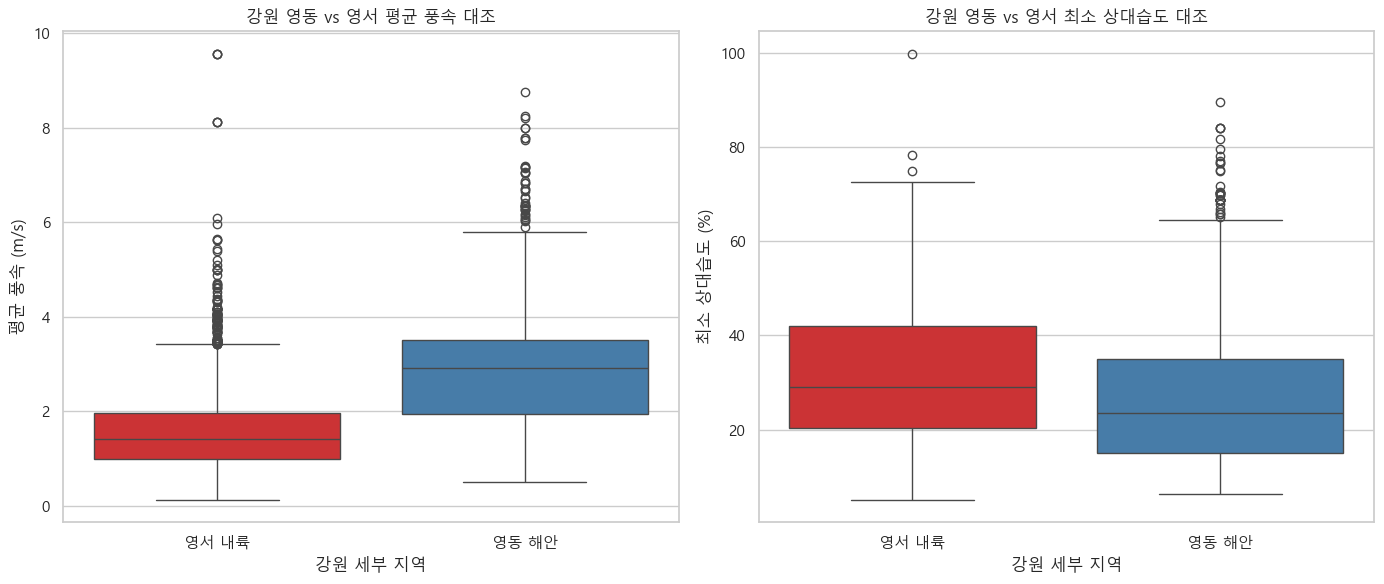

In [53]:
# 13.2. 강원 영동 vs 영서 내부 기상 대조 분석
gw_only = day_active[day_active['is_gangwon']].copy()

# 영동 지방 시군구 매핑
yeongdong_districts = ["강릉시", "속초시", "동해시", "삼척시", "태백시", "고성군", "양양군", 
                        "강릉", "속초", "동해", "삼척", "태백", "고성", "양양"]
gw_only['sub_region'] = gw_only['발생지역시군구명'].apply(
    lambda x: '영동 해안' if x in yeongdong_districts else '영서 내륙'
)

print("=== 강원 영동 해안 vs 영서 내륙 주요 기상 변수 비교 ===")
print(gw_only.groupby('sub_region')[['평균 풍속', '최소 상대습도', '최대 순간풍속']].describe())

gw_yd_w = gw_only[gw_only['sub_region']=='영동 해안']['평균 풍속'].dropna()
gw_ys_w = gw_only[gw_only['sub_region']=='영서 내륙']['평균 풍속'].dropna()
t_val8, p_val8 = stats.ttest_ind(gw_yd_w, gw_ys_w, equal_var=False)

gw_yd_h = gw_only[gw_only['sub_region']=='영동 해안']['최소 상대습도'].dropna()
gw_ys_h = gw_only[gw_only['sub_region']=='영서 내륙']['최소 상대습도'].dropna()
t_val9, p_val9 = stats.ttest_ind(gw_yd_h, gw_ys_h, equal_var=False)

print(f"\n평균 풍속 영동 vs 영서 t-test: t={t_val8:.4f}, p={p_val8:.4e}")
print(f"최소 상대습도 영동 vs 영서 t-test: t={t_val9:.4f}, p={p_val9:.4e}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=gw_only, x='sub_region', y='평균 풍속', palette=['#e41a1c', '#377eb8'], ax=axes[0])
axes[0].set_title("강원 영동 vs 영서 평균 풍속 대조")
axes[0].set_xlabel("강원 세부 지역")
axes[0].set_ylabel("평균 풍속 (m/s)")

sns.boxplot(data=gw_only, x='sub_region', y='최소 상대습도', palette=['#e41a1c', '#377eb8'], ax=axes[1])
axes[1].set_title("강원 영동 vs 영서 최소 상대습도 대조")
axes[1].set_xlabel("강원 세부 지역")
axes[1].set_ylabel("최소 상대습도 (%)")

plt.tight_layout()
plt.show()

### 13.3. 계절적 잔존물 및 지리 격차 분석 요약

1. **적설 잔존 비율**: 발생일/전일 적설 존재 비율은 강원도 **32.62%**, 타 지역 **27.12%**입니다. 강원도는 겨울~초봄 잔존 적설이 산불 표본에 더 자주 포함됩니다.

2. **적설의 진화 완화 효과**: 전체 유효 진화시간 표본에서 적설이 있는 산불의 평균 진화소요시간은 **1.84시간**, 적설이 없는 산불은 **2.26시간**입니다($t=-4.89$, $p=1.02e-06$). 로그 스케일 박스플롯에서도 적설 존재 그룹의 상방 꼬리가 상대적으로 낮아, 잔존 적설이 확산과 장기 진화를 완화하는 신호가 있습니다.

3. **강원도 내부 영동/영서 차이**: 강원도 안에서는 영동 해안의 평균 풍속이 **2.94m/s**로 영서 내륙 **1.64m/s**보다 높고, 최소 상대습도는 영동 **26.67%**, 영서 **31.61%**입니다. 최대 순간풍속도 영동 **10.93m/s**, 영서 **8.02m/s**로 영동권 강풍·저습 결합이 뚜렷합니다.

4. **해석**: 전국 단위의 강원도 특징은 내부적으로 영동 해안권의 바람길과 건조 조건이 크게 끌어올린 결과입니다. 강원도 전체 평균만으로 영서 내륙까지 같은 위험 메커니즘이라고 일반화하지 않아야 합니다.


## 14. 진화 장애 및 비선형 임계성 분석 (Non-linear Risk Envelope)
본 섹션에서는 기상 인자의 변화와 실제 산불의 진화 소요 시간(확산 심각도) 간의 비선형적인 관계를 분석합니다. 이를 통해 소방 헬기 통제 및 진화 불능 임계점을 규명하고, 3D 위험 영역을 확인하며, 예측 모델링에 최적화된 실효습도 감쇄 상수를 도출합니다.

### 14.1. 풍속 대역별 진화 시간의 비선형 가속 효과 규명
풍속이 커지면 산불 비화가 급증하고 소방 헬기 기동이 통제되어 진화 시간이 급증합니다. 풍속 대역을 구간화하여 평균 진화 소요 시간과 대형 산불(진화 시간 >= 12h) 발생 비율의 꺾임 지점(임계점)을 시각화 분석합니다.

=== 풍속 대역별 진화 특성 및 대형 산불 비율 ===
    풍속구간  count  mean_duration  median_duration  large_ratio
0    0-2   3706       1.855851         1.166667     0.025904
1    2-4   2323       2.208280         1.166667     0.037452
2    4-6    344       3.368459         1.500000     0.093023
3    6-8     63       5.492328         1.916667     0.142857
4   8-10      7       6.188095         2.916667     0.142857
5  10-15      1       0.333333         0.333333     0.000000


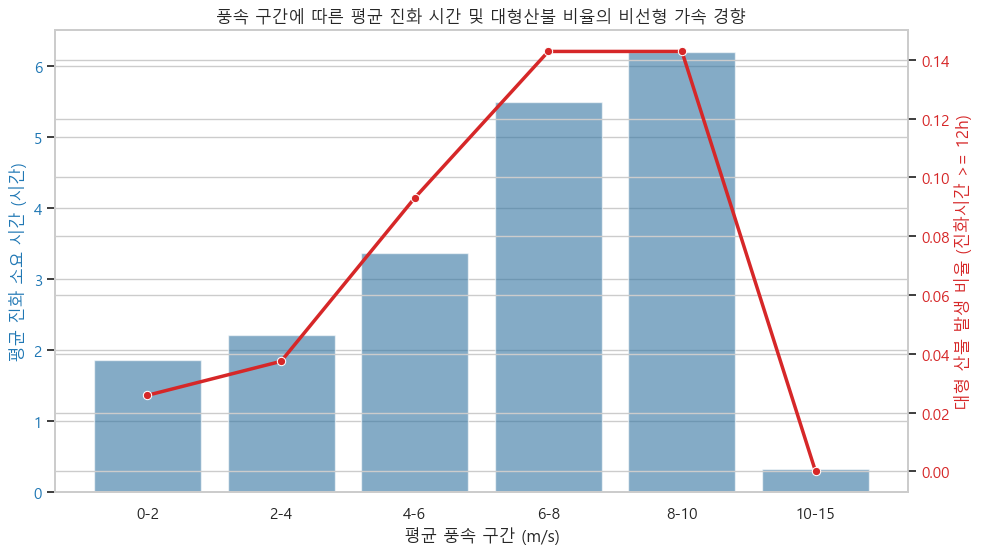

In [54]:
# 14.1. 풍속 대역별 진화 시간의 비선형 가속 효과 규명
valid_duration_day = day_active.dropna(subset=['진화소요시간시']).copy()
valid_duration_day['is_large'] = valid_duration_day['진화소요시간시'] >= 12

# 풍속 구간 정의 및 바인딩
bins = [0, 2, 4, 6, 8, 10, 15, 50]
labels = ["0-2", "2-4", "4-6", "6-8", "8-10", "10-15", "15+"]
valid_duration_day['풍속구간'] = pd.cut(valid_duration_day['평균 풍속'], bins=bins, labels=labels)

wind_grouped = valid_duration_day.groupby('풍속구간').agg(
    count=('진화소요시간시', 'count'),
    mean_duration=('진화소요시간시', 'mean'),
    median_duration=('진화소요시간시', 'median'),
    large_ratio=('is_large', 'mean')
).reset_index()

print("=== 풍속 대역별 진화 특성 및 대형 산불 비율 ===")
print(wind_grouped)

# 이중 축 바차트 + 라인차트 시각화
fig, ax1 = plt.subplots(figsize=(11, 6))
color = 'tab:blue'
sns.barplot(data=wind_grouped, x='풍속구간', y='mean_duration', color=color, alpha=0.6, ax=ax1)
ax1.set_ylabel('평균 진화 소요 시간 (시간)', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlabel('평균 풍속 구간 (m/s)')

ax2 = ax1.twinx()
color = 'tab:red'
sns.lineplot(data=wind_grouped, x='풍속구간', y='large_ratio', color=color, marker='o', linewidth=2.5, ax=ax2)
ax2.set_ylabel('대형 산불 발생 비율 (진화시간 >= 12h)', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("풍속 구간에 따른 평균 진화 시간 및 대형산불 비율의 비선형 가속 경향")
plt.show()

### 14.2. 기온-풍속-실효습도 3D 위험 영역 (3D Envelope) 비교 분석
산불 확산 및 진화 난이도를 결정하는 3대 핵심 기상 피처(평균 기온, 평균 풍속, 실효습도)를 축으로 하는 3차원 공간 상의 위험 영역 분포를 구축하여, 강원도와 타 지역의 실제 산불 발생 기상 위험대(Envelope)를 공간적으로 대조합니다.

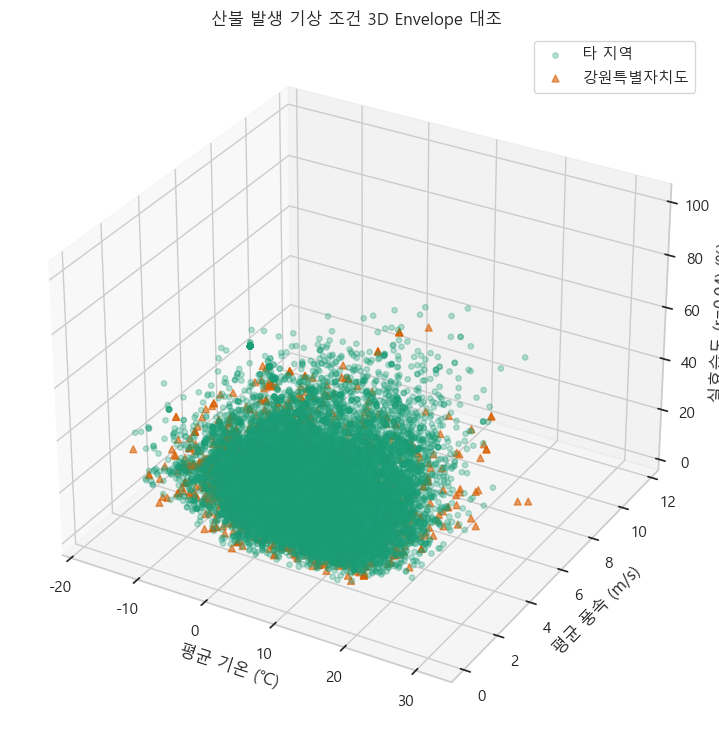

In [55]:
# 14.2. 기온-풍속-실효습도 3D 위험 영역 비교 분석
from mpl_toolkits.mplot3d import Axes3D

# 최적 실효습도(r=0.04) 계산
day_pivot_temp = day_df.pivot(index='산불아이디', columns='발생일기준일수', values='최소 상대습도')
day_pivot_temp = day_pivot_temp.rename(columns={0: 'H_0', -1: 'H_1'}).dropna(subset=['H_0', 'H_1'])
h_eff_opt = 0.96 * (day_pivot_temp['H_0'] + 0.04 * day_pivot_temp['H_1'])
day_active['effective_humidity_opt'] = day_active['산불아이디'].map(h_eff_opt)

plot_df = day_active.dropna(subset=['평균 기온', '평균 풍속', 'effective_humidity_opt']).copy()

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

gw_pts = plot_df[plot_df['is_gangwon']]
other_pts = plot_df[~plot_df['is_gangwon']]

# 3D 산점도 플롯
ax.scatter(other_pts['평균 기온'], other_pts['평균 풍속'], other_pts['effective_humidity_opt'], 
           c='#1b9e77', label='타 지역', alpha=0.3, s=15)
ax.scatter(gw_pts['평균 기온'], gw_pts['평균 풍속'], gw_pts['effective_humidity_opt'], 
           c='#d95f02', label='강원특별자치도', alpha=0.6, s=25, marker='^')

ax.set_xlabel('평균 기온 (℃)')
ax.set_ylabel('평균 풍속 (m/s)')
ax.set_zlabel('실효습도 (r=0.04) (%)')
ax.set_title('산불 발생 기상 조건 3D Envelope 대조')
plt.legend()
plt.show()

### 14.3. 실효습도 가중 감쇄 상수 (r) 최적화 분석
실효습도는 과거 날짜 최소습도의 기여도를 감쇄 상수 $r$로 가중 반영한 지수식 $H_{eff}(r) = (1-r)(H_0 + r H_1 + r^2 H_2 + ...)$을 따릅니다. 본 데이터셋의 구조(당일 $H_0$ 및 전일 $H_1$ 보유)에 맞춰 감쇄 상수 $r$을 0.01~0.99 범위에서 변경해 가며, 실제 진화소요시간(Spearman) 및 대형 산불 분류 성능(ROC AUC score)을 극대화시키는 최적의 $r$ 상수를 그리드 서치를 통해 탐색합니다.

=== 실효습도 감쇄상수 r 최적화 결과 ===
최고 스피어만 상관관계 (절대값): r=0.05, correlation=-0.0167
최고 대형산불 이진분류 AUC score: r=0.04, AUC=0.6310


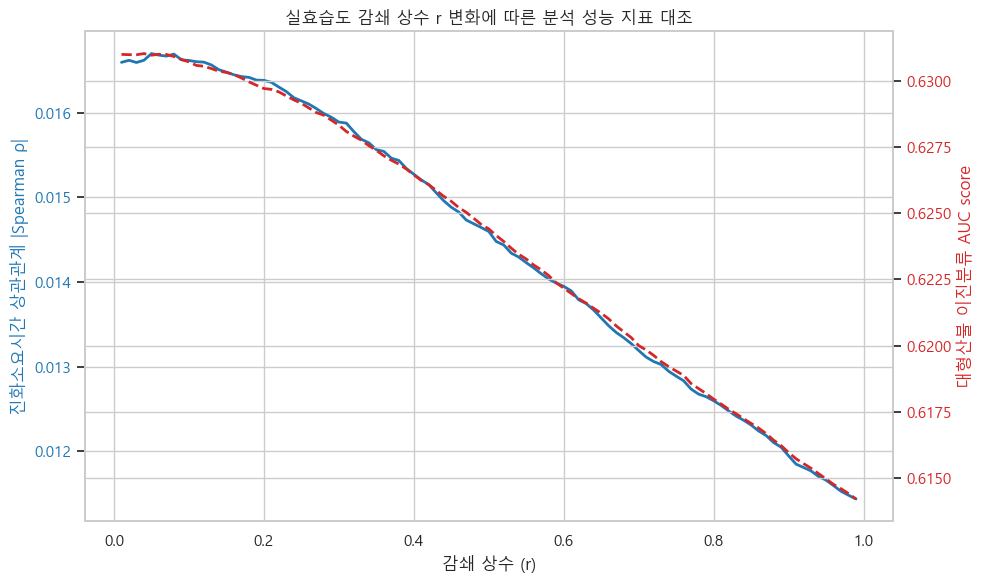

In [56]:
# 14.3. 실효습도 가중 감쇄 상수 (r) 최적화 분석
from sklearn.metrics import roc_auc_score

day_pivot = day_df.pivot(index='산불아이디', columns='발생일기준일수', values='최소 상대습도')
day_pivot = day_pivot.rename(columns={0: 'H_0', -1: 'H_1'}).dropna(subset=['H_0', 'H_1'])
duration_mapping = day_active.set_index('산불아이디')['진화소요시간시']
day_pivot['duration'] = day_pivot.index.map(duration_mapping)
day_pivot = day_pivot.dropna(subset=['duration'])
day_pivot['is_large'] = day_pivot['duration'] >= 12

results = []
for r in np.linspace(0.01, 0.99, 99):
    h_eff = (1 - r) * (day_pivot['H_0'] + r * day_pivot['H_1'])
    spearman_corr = h_eff.corr(day_pivot['duration'], method='spearman')
    
    try:
        auc = roc_auc_score(day_pivot['is_large'], -h_eff)
    except:
        auc = np.nan
    results.append({'r': r, 'spearman': spearman_corr, 'auc': auc})

r_df = pd.DataFrame(results)
best_spearman = r_df.loc[r_df['spearman'].abs().idxmax()]
best_auc = r_df.loc[r_df['auc'].idxmax()]

print("=== 실효습도 감쇄상수 r 최적화 결과 ===")
print(f"최고 스피어만 상관관계 (절대값): r={best_spearman['r']:.2f}, correlation={best_spearman['spearman']:.4f}")
print(f"최고 대형산불 이진분류 AUC score: r={best_auc['r']:.2f}, AUC={best_auc['auc']:.4f}")

# 최적화 추이 시각화
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.plot(r_df['r'], r_df['spearman'].abs(), color=color, linewidth=2, label='스피어만 상관계수 (절대값)')
ax1.set_xlabel('감쇄 상수 (r)')
ax1.set_ylabel('진화소요시간 상관관계 |Spearman ρ|', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(r_df['r'], r_df['auc'], color=color, linewidth=2, linestyle='--', label='대형산불 이진분류 AUC')
ax2.set_ylabel('대형산불 이진분류 AUC score', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("실효습도 감쇄 상수 r 변화에 따른 분석 성능 지표 대조")
fig.tight_layout()
plt.show()

### 14.4. 진화 장애 및 비선형 임계성 분석 요약

1. **풍속 대역별 비선형성**: 평균 풍속 0~2m/s 구간의 12시간 이상 대형 산불 비율은 **2.59%**, 2~4m/s는 **3.75%**입니다. 4~6m/s에서는 **9.30%**, 6~8m/s에서는 **14.29%**로 상승해, 4m/s 이후부터 진화 장애 위험이 뚜렷하게 커집니다.

2. **샘플 희소성 주의**: 8~10m/s 구간은 7건, 10~15m/s 구간은 1건뿐입니다. 10~15m/s 구간의 대형 산불 비율 0%는 위험이 낮다는 뜻이 아니라 표본 희소성에 따른 착시입니다. 모델링에서는 6m/s 이상을 고위험 강풍 구간으로 묶거나 표본 수 기준을 함께 적용하는 것이 안전합니다.

3. **3D 위험 영역**: 3D 플롯에서 대형 산불 표본은 고풍속과 낮은 실효습도 영역에 상대적으로 많이 보입니다. 다만 일반 산불과의 중첩도 크므로, 기온-풍속-실효습도 3개 변수만으로 완전 분리되는 구조는 아닙니다.

4. **실효습도 감쇄 상수**: 전국 기준 그리드서치에서 대형 산불 AUC는 **r=0.04**에서 **0.6310**으로 가장 높고, 스피어만 상관은 **r=0.05**, 상관계수 **-0.0167**로 매우 낮습니다. 진화시간의 선형 설명력보다 대형 산불 이진 판별용 피처로 활용하는 쪽이 더 적합합니다.
